# Mineração de Dados Eleitorais 2026 — Notebook único

Junção, na ordem, dos notebooks do projeto. As células de cada notebook foram copiadas sem alterações.

## Índice

1. [Parte 00 — Preparação dos dados](#parte-0)
2. [Parte 01 — Análise descritiva](#parte-1)
3. [Parte 02 — Clusterização com gasto de campanha](#parte-2)
4. [Parte 03 — Regras de associação](#parte-3)
5. [Parte 04 — Detecção de anomalias](#parte-4)

<a id="parte-0"></a>

---

# Parte 00 — Preparação dos dados

*Origem: `00_preparacao_dados.ipynb`*

<a href="https://colab.research.google.com/github/itagibanetos/mineracao-dados-eleitorais-2026/blob/main/00_preparacao_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 0 — Preparação de Dados: Candidatos 2026 (TSE)

Este notebook baixa e prepara os dados de candidatos das Eleições 2026, e salva um **dataset limpo** que todas as fases seguintes (1 a 4) vão reutilizar — assim ninguém precisa baixar e limpar os dados de novo em cada notebook.

## Configuração

Ajuste as três variáveis abaixo antes de rodar. É a **única coisa que muda** entre a análise do professor (Brasil, Governador) e o trabalho de vocês (um cargo, uma UF).

In [4]:
CARGO = "DEPUTADO FEDERAL"
UF = ["PR" , "RS", "SC"]
ANO_ELEICAO = 2026

> **Para os alunos:** troquem `CARGO` para `"SENADOR"` ou `"DEPUTADO FEDERAL"` e `UF` para a sigla do estado do seu trabalho (ex.: `UF = "PE"`). O resto do notebook não muda.

> **Sobre "congelar" a versão dos dados:** o arquivo do TSE pode ser atualizado por eles a qualquer momento (novas candidaturas, correções, impugnações). Para não ficar refém disso, os zips baixados manualmente ficam parados em `dados/` e só mudam quando você baixar uma versão nova de propósito. O que fica **versionado no git** é o resultado desta fase (`dados/*.csv`) — depois de rodar e conferir, faça `git commit` desse CSV: esse commit *é* a versão congelada que a turma toda vai usar.

## 1) Preparação do ambiente

In [5]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

os.makedirs('dados', exist_ok=True)

## 2) Obter os dados

O download automático pelo CDN do TSE é bloqueado por um firewall (Akamai) que rejeita requisições que não vêm de um navegador de verdade — isso acontece tanto no Colab quanto localmente, então não vale a pena automatizar. **O fluxo é manual:**

1. Baixe os dois arquivos pelo navegador:
   - Candidatos: `https://cdn.tse.jus.br/estatistica/sead/odsele/consulta_cand/consulta_cand_2026.zip`
   - Bens: `https://cdn.tse.jus.br/estatistica/sead/odsele/bem_candidato/bem_candidato_2026.zip`
2. Salve os dois **dentro da pasta `dados/`**, com esses nomes exatos:
   - `dados/consulta_cand_2026.zip`
   - `dados/bem_candidato_2026.zip`
3. Rode as células abaixo — elas conferem se os arquivos estão no lugar certo e descompactam.

In [6]:
!git clone https://github.com/itagibanetos/mineracao-dados-eleitorais-2026.git
%cd /content/mineracao-dados-eleitorais-2026

!ls dados

fatal: destination path 'mineracao-dados-eleitorais-2026' already exists and is not an empty directory.
[Errno 2] No such file or directory: '/content/mineracao-dados-eleitorais-2026'
/Users/leonardo/PosGraduacao/AprendizagemNaoSupervisionada/mineracao_dados
Graficos de analise
bem_candidato_2026.zip
candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv
candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv
consulta_cand_2026.zip
prestacao_de_contas_eleitorais_candidatos_2026.zip


In [7]:
ZIP_CAND = f"dados/consulta_cand_{ANO_ELEICAO}.zip"
ZIP_BEM = f"dados/bem_candidato_{ANO_ELEICAO}.zip"

def conferir_zip(caminho):
    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f"Não encontrei {caminho}. Baixe o arquivo pelo navegador e salve exatamente nesse caminho "
            "(veja os links na célula de markdown acima)."
        )
    if not zipfile.is_zipfile(caminho):
        raise ValueError(f"{caminho} existe, mas não é um .zip válido — baixe de novo pelo navegador.")
    tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
    print(f"OK: {caminho} ({tamanho_mb:.1f} MB)")

def descompactar(nome_arquivo_zip, destino):
    with zipfile.ZipFile(nome_arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall(destino)
    print(f"Descompactado em {destino}")

conferir_zip(ZIP_CAND)
conferir_zip(ZIP_BEM)

OK: dados/consulta_cand_2026.zip (3.0 MB)
OK: dados/bem_candidato_2026.zip (3.6 MB)


In [ ]:
descompactar(ZIP_CAND, './files_cand')
descompactar(ZIP_BEM, './files_bem')

## 3) Filtrar candidatos (CARGO + UF)

In [9]:
df = pd.read_csv(f'./files_cand/consulta_cand_{ANO_ELEICAO}_BRASIL.csv', sep=';', encoding='latin-1')

# Rastreabilidade: o próprio TSE grava quando gerou este extrato — assim dá pra saber
# exatamente qual snapshot da base está sendo usado, mesmo que o arquivo mude no futuro.
print(f"Extrato gerado pelo TSE em: {df['DT_GERACAO'].iloc[0]} {df['HH_GERACAO'].iloc[0]}")

print("\nCargos disponíveis:")
print(df.DS_CARGO.value_counts())

dfCargo = df[df["DS_CARGO"] == CARGO].copy()
if UF is not None:
    dfCargo = dfCargo[dfCargo["SG_UF"].isin(UF)].copy()

# uma linha por candidato: fica com o turno mais avançado (2º turno quando existir)
dfCargoFinal = dfCargo.loc[dfCargo.groupby('SQ_CANDIDATO')['NR_TURNO'].idxmax()]

print()
print(f"CARGO={CARGO!r}  UF={UF!r}  ->  {dfCargoFinal.shape[0]} candidatos")
dfCargoFinal[['SQ_CANDIDATO', 'NM_CANDIDATO', 'SG_UF', 'SG_PARTIDO', 'DT_NASCIMENTO']].head()

Extrato gerado pelo TSE em: 19/09/2026 16:30:44

Cargos disponíveis:
DS_CARGO
DEPUTADO ESTADUAL     11292
DEPUTADO FEDERAL       7801
DEPUTADO DISTRITAL      433
2º SUPLENTE             350
1º SUPLENTE             349
SENADOR                 319
VICE-GOVERNADOR         211
GOVERNADOR              201
PRESIDENTE               14
VICE-PRESIDENTE          14
Name: count, dtype: int64

CARGO='DEPUTADO FEDERAL'  UF=['PR', 'RS', 'SC']  ->  1117 candidatos


,SQ_CANDIDATO,NM_CANDIDATO,SG_UF,SG_PARTIDO,DT_NASCIMENTO
15282,160002532588,MARIO SETO TAKEGUMA JUNIOR,PR,PSB,07/01/1987
12630,160002532589,ANTÔNIO FERNANDO TEIGAO,PR,PSB,21/10/1957
10005,160002532590,CAMILLA DE MORAES GONDA,PR,PSB,14/10/2000
7320,160002532591,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,PR,PSB,05/07/2004
4686,160002532592,OMAR RAIMUNDO PICHETH NETO,PR,PSB,28/07/1971


## 4) Patrimônio declarado (bens)

In [10]:
dfBem = pd.read_csv('./files_bem/bem_candidato_%d_BRASIL.csv' % ANO_ELEICAO, sep=';', encoding='latin-1')
dfBem['VR_BEM_CANDIDATO'] = dfBem['VR_BEM_CANDIDATO'].str.replace(',', '.').astype(float)

def categorize_assets(asset):
    a = asset.lower()
    if 'veículo' in a or 'moto' in a or 'aeronave' in a or 'embarcação' in a:
        return 'BENS MÓVEIS'
    elif 'casa' in a or 'terreno' in a or 'apartamento' in a or 'prédio' in a or 'loja' in a or 'terra nua' in a:
        return 'BENS IMÓVEIS'
    elif 'poupança' in a or 'renda fixa' in a or 'cdb' in a or 'rdb' in a:
        return 'INVESTIMENTOS RENDA FIXA'
    elif 'ações' in a or 'fundo' in a or 'investimento' in a or 'mercado' in a:
        return 'INVESTIMENTOS RENDA VARIÁVEL'
    elif 'dinheiro' in a or 'depósito bancário' in a or 'numerário' in a:
        return 'DINHEIRO'
    else:
        return 'OUTROS BENS'

dfBem['Categoria_BEM'] = dfBem['DS_TIPO_BEM_CANDIDATO'].apply(categorize_assets)

dfBem_pivot = dfBem.pivot_table(
    index='SQ_CANDIDATO', columns='Categoria_BEM', values='VR_BEM_CANDIDATO', aggfunc='sum'
)
dfBem_pivot.fillna(0, inplace=True)
dfBem_pivot['Total_Bens'] = dfBem_pivot.sum(axis=1)
dfBem_pivot['Total_Bens_Log'] = np.log1p(dfBem_pivot['Total_Bens'])

dfBem_pivot[['Total_Bens', 'Total_Bens_Log']].describe()

Categoria_BEM,Total_Bens,Total_Bens_Log
count,1.390200e+04,13902.000000
mean,2.320062e+06,12.690496
std,2.089336e+07,2.038298
min,0.000000e+00,0.000000
25%,1.165000e+05,11.665655
50%,4.007446e+05,12.901082
75%,1.120000e+06,13.928840
max,1.226983e+09,20.927824


## 5) Juntar tudo, calcular idade e limpar

A idade mínima elegível **depende do cargo** (regra constitucional) — por isso o filtro de idade é montado a partir de `CARGO`, não fixo.

In [11]:
IDADE_MINIMA_POR_CARGO = {
    'PRESIDENTE': 35, 'VICE-PRESIDENTE': 35,
    'GOVERNADOR': 30, 'VICE-GOVERNADOR': 30,
    'SENADOR': 35,
    'DEPUTADO FEDERAL': 21, 'DEPUTADO ESTADUAL': 21, 'DEPUTADO DISTRITAL': 21,
    'PREFEITO': 21, 'VICE-PREFEITO': 21,
    'VEREADOR': 18,
}
idade_minima = IDADE_MINIMA_POR_CARGO.get(CARGO, 18)
print(f"Idade mínima elegível para {CARGO}: {idade_minima} anos")

dfCandBem = dfCargoFinal.merge(dfBem_pivot, on='SQ_CANDIDATO', how='left')
dfCandBem['Total_Bens'] = dfCandBem['Total_Bens'].fillna(0)
dfCandBem['Total_Bens_Log'] = dfCandBem['Total_Bens_Log'].fillna(0)

dfCandBem['DT_ELEICAO'] = pd.to_datetime(dfCandBem['DT_ELEICAO'], format='%d/%m/%Y')
dfCandBem['DT_NASCIMENTO'] = pd.to_datetime(dfCandBem['DT_NASCIMENTO'], format='%d/%m/%Y')
dfCandBem['IDADE'] = (dfCandBem['DT_ELEICAO'] - dfCandBem['DT_NASCIMENTO']).dt.days // 365

# remover idades inválidas (erro de cadastro) usando a idade mínima constitucional do cargo
antes = dfCandBem.shape[0]
dfCandBem = dfCandBem[dfCandBem['IDADE'].between(idade_minima, 100)].copy()
print(f"Candidatos removidos por idade inválida: {antes - dfCandBem.shape[0]}")

print(dfCandBem.shape)
dfCandBem[['NM_CANDIDATO', 'SG_UF', 'IDADE', 'Total_Bens', 'Total_Bens_Log']].sample(min(5, len(dfCandBem)))

Idade mínima elegível para DEPUTADO FEDERAL: 21 anos
Candidatos removidos por idade inválida: 0
(1117, 59)


,NM_CANDIDATO,SG_UF,IDADE,Total_Bens,Total_Bens_Log
110,JOEL XAVIER,PR,73,2097370.00,14.556195
395,LETICIA CAROLINA TAVARES FERNANDES,PR,23,0.00,0.000000
79,MICHELE DE FATIMA NASCIMENTO,PR,47,149214.07,11.913144
60,MATHEUS ARAUJO LAIOLA,PR,43,846000.00,13.648276
446,FABIO MAIA OSTERMANN,RS,42,800352.74,13.592809


> **Nota:** propositalmente **não removemos outliers de patrimônio aqui** — a Fase 1 (análise descritiva) precisa vê-los para serem discutidos, e o tratamento de outliers é específico de cada técnica (vamos fazer isso dentro da Fase 2, clusterização).

## 6) Salvar o dataset limpo

In [12]:
nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo_saida = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

dfCandBem.to_csv(arquivo_saida, index=False)
print(f"Dataset salvo em: {arquivo_saida}  ({dfCandBem.shape[0]} candidatos, {dfCandBem.shape[1]} colunas)")

Dataset salvo em: dados/candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv  (1117 candidatos, 59 colunas)


---
## Congelando esta versão

Depois de conferir o resultado acima, faça o commit desse arquivo:

```bash
git add dados/*.csv
git commit -m "Dados: candidatos <CARGO> <UF> <ANO> (snapshot TSE de <DT_GERACAO>)"
```

A partir daí, **esse commit é a versão oficial** que a Fase 1 em diante (e o resto da turma, via `git pull`) vai usar — mesmo que o TSE atualize o arquivo-fonte depois. Só repita a Fase 0 e recommite quando quiser atualizar de propósito.

## Próximo passo

Vá para **`01_analise_descritiva.ipynb`** e use exatamente os mesmos valores de `CARGO`, `UF` e `ANO_ELEICAO` na célula de configuração, para carregar este mesmo arquivo.

In [13]:
!ls dados/*.csv

dados/candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv
dados/candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv


<a id="parte-1"></a>

---

# Parte 01 — Análise descritiva

*Origem: `01_analise_descritiva.ipynb`*

<a href="https://colab.research.google.com/github/itagibanetos/mineracao-dados-eleitorais-2026/blob/main/01_analise_descritiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1 — Análise Descritiva: Candidatos 2026 (TSE)

Esta fase é **exploração pura**: olhar para os dados de candidatos e de bens declarados sem nenhum compromisso com o que vem depois (clusterização, regras de associação, anomalias). A ideia é conhecer o dataset por conta própria — distribuições, proporções, outliers, relações entre variáveis — **antes** de qualquer modelo apontar o que "importa". As fases seguintes vão te pedir pra escolher variáveis; essa escolha deve nascer do que você observar aqui, não o contrário.

**Objetivo do projeto (Grupo 3):** identificar os perfis dos 1.117 candidatos a Deputado Federal no Sul (PR, RS e SC) nas Eleições 2026 a partir de quatro variáveis — idade, anos de estudo, patrimônio declarado e gasto de campanha —, entender o que caracteriza cada perfil (regras de associação) e quem foge do padrão da base e do próprio grupo (detecção de anomalias). Fontes: TSE, `consulta_cand_2026`, `bem_candidato_2026` e `prestacao_de_contas_eleitorais_candidatos_2026` (despesas contratadas), extrato de 19/09/2026.

Este notebook parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## Configuração

Use os **mesmos valores** que você usou na Fase 0, para carregar o arquivo certo.

In [1]:
CARGO = "DEPUTADO FEDERAL"
UF = ["PR" , "RS", "SC"]
ANO_ELEICAO = 2026

In [2]:
import sys

# Só no Google Colab: localmente os arquivos já estão na pasta do projeto
if "google.colab" in sys.modules:
    !git clone https://github.com/itagibanetos/mineracao-dados-eleitorais-2026.git
    %cd /content/mineracao-dados-eleitorais-2026

!ls dados

Graficos de analise
bem_candidato_2026.zip
candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv
candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv
consulta_cand_2026.zip
extraidos_despesas
prestacao_de_contas_eleitorais_candidatos_2026.zip


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv  ->  1117 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532588,4050,MARIO SETO TAKEGUMA JUNIOR,MARIO CERTO,#NULO,6434321910,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1987-01-07,92467190698,2,MASCULINO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),4,AMARELA,132,PSICÓLOGO,-1,#NULO,0.00,"45,000.00","11,544.24","87,605.86",0.00,"52,262.32","196,412.42",12.19,39
1,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532589,4045,ANTÔNIO FERNANDO TEIGAO,FERNANDÃO,#NULO,30357934920,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1957-10-21,12790340663,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,257,EMPRESÁRIO,-1,#NULO,0.00,"87,000.00","4,984.47","25,453.75","15,000.00","227,871.27","360,309.49",12.79,69
2,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532590,4000,CAMILLA DE MORAES GONDA,CAMILLA GONDA,#NULO,10555616924,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,2000-10-14,115434590639,4,FEMININO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),1,BRANCA,278,VEREADOR,-1,#NULO,0.00,0.00,0.00,"14,187.66",0.00,0.00,"14,187.66",9.56,25
3,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532591,4070,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,CHARLESTON JÚNIOR INCLUSÃO,#NULO,10945908946,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,2004-07-05,124740900612,2,MASCULINO,7,SUPERIOR INCOMPLETO,1,SOLTEIRO(A),1,BRANCA,931,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,22
4,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532592,4077,OMAR RAIMUNDO PICHETH NETO,OMAR PICHETH,#NULO,82002045968,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1971-07-28,46300400663,2,MASCULINO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,278,VEREADOR,-1,#NULO,"275,000.00","40,000.00",0.00,"19,686.98",0.00,0.00,"334,686.98",12.72,55


## 1) Visão geral: tamanho, tipos e dados ausentes

Antes de olhar variável por variável, um raio-x da tabela inteira.

1117 candidatos x 59 colunas



str        31
int64      20
float64     8
Name: nº de colunas, dtype: int64

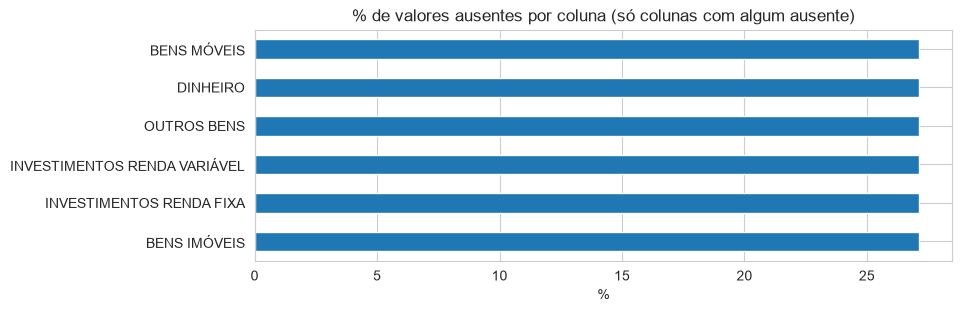

In [4]:
print(f"{df.shape[0]} candidatos x {df.shape[1]} colunas\n")
display(df.dtypes.value_counts().rename('nº de colunas'))

faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    plt.figure(figsize=(9, max(3, len(faltantes) * 0.3)))
    faltantes.plot(kind='barh')
    plt.title('% de valores ausentes por coluna (só colunas com algum ausente)')
    plt.xlabel('%')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2) Escolhendo o que explorar

O dataset tem dezenas de colunas — muitas são identificadores administrativos (`SQ_CANDIDATO`, `NR_CPF_CANDIDATO`, `DS_EMAIL`, hashes de geração...) sem valor analítico. As duas listas abaixo reúnem as colunas com conteúdo substantivo — **sintam-se livres para adicionar outras que despertarem curiosidade** (`df.columns` mostra tudo o que está disponível).

In [5]:
display(pd.DataFrame({"Coluna": df.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,ANO_ELEICAO
3,CD_TIPO_ELEICAO
4,NM_TIPO_ELEICAO
5,NR_TURNO
6,CD_ELEICAO
7,DS_ELEICAO
8,DT_ELEICAO
9,TP_ABRANGENCIA


In [6]:
colunas_numericas = [
    'IDADE',
    'Total_Bens',
    'Total_Bens_Log',
    'BENS MÓVEIS',
    'BENS IMÓVEIS',
    'DINHEIRO',
    'INVESTIMENTOS RENDA FIXA',
    'INVESTIMENTOS RENDA VARIÁVEL',
    'OUTROS BENS',
]
colunas_numericas = [c for c in colunas_numericas if c in df.columns]

colunas_categoricas = [
    'DS_GENERO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA',
    'DS_GRAU_INSTRUCAO',
    'DS_SITUACAO_CANDIDATURA',
    'DS_SIT_TOT_TURNO',
    'TP_AGREMIACAO',
    'SG_PARTIDO',
    'DS_OCUPACAO',
    'NR_TURNO',
    'SG_UE',
]
colunas_categoricas = [c for c in colunas_categoricas if c in df.columns]

print("Numéricas:")
display(pd.DataFrame({"Coluna": colunas_numericas}))
print("Categóricas:")
display(pd.DataFrame({"Coluna": colunas_categoricas}))

Numéricas:


,Coluna
0,IDADE
1,Total_Bens
2,Total_Bens_Log
3,BENS MÓVEIS
4,BENS IMÓVEIS
5,DINHEIRO
6,INVESTIMENTOS RENDA FIXA
7,INVESTIMENTOS RENDA VARIÁVEL
8,OUTROS BENS


Categóricas:


,Coluna
0,DS_GENERO
1,DS_ESTADO_CIVIL
2,DS_COR_RACA
3,DS_GRAU_INSTRUCAO
4,DS_SITUACAO_CANDIDATURA
5,DS_SIT_TOT_TURNO
6,TP_AGREMIACAO
7,SG_PARTIDO
8,DS_OCUPACAO
9,NR_TURNO


## 3) Variáveis numéricas: distribuição e outliers

In [7]:
display(df[colunas_numericas].describe().T)

,count,mean,std,min,25%,50%,75%,max
IDADE,"1,117.00",48.60,12.42,21.00,40.00,48.00,58.00,85.00
Total_Bens,"1,117.00","1,003,354.61","4,490,875.42",0.00,0.00,"157,849.37","710,000.00","75,659,161.21"
Total_Bens_Log,"1,117.00",9.19,5.86,0.00,0.00,11.97,13.47,18.14
BENS MÓVEIS,814.00,"84,882.58","183,608.44",0.00,0.00,"38,803.50","114,406.00","3,850,661.80"
BENS IMÓVEIS,814.00,"552,827.19","1,456,048.43",0.00,0.00,"156,708.02","600,000.00","28,900,209.44"
DINHEIRO,814.00,"35,668.53","161,465.44",0.00,0.00,0.00,"5,540.26","2,600,897.69"
INVESTIMENTOS RENDA FIXA,814.00,"67,218.26","784,962.56",0.00,0.00,0.00,372.96,"21,918,279.03"
INVESTIMENTOS RENDA VARIÁVEL,814.00,"106,794.30","634,211.40",0.00,0.00,0.00,0.00,"10,758,693.96"
OUTROS BENS,814.00,"529,448.32","3,951,551.29",0.00,0.00,0.00,"78,599.58","64,787,400.00"


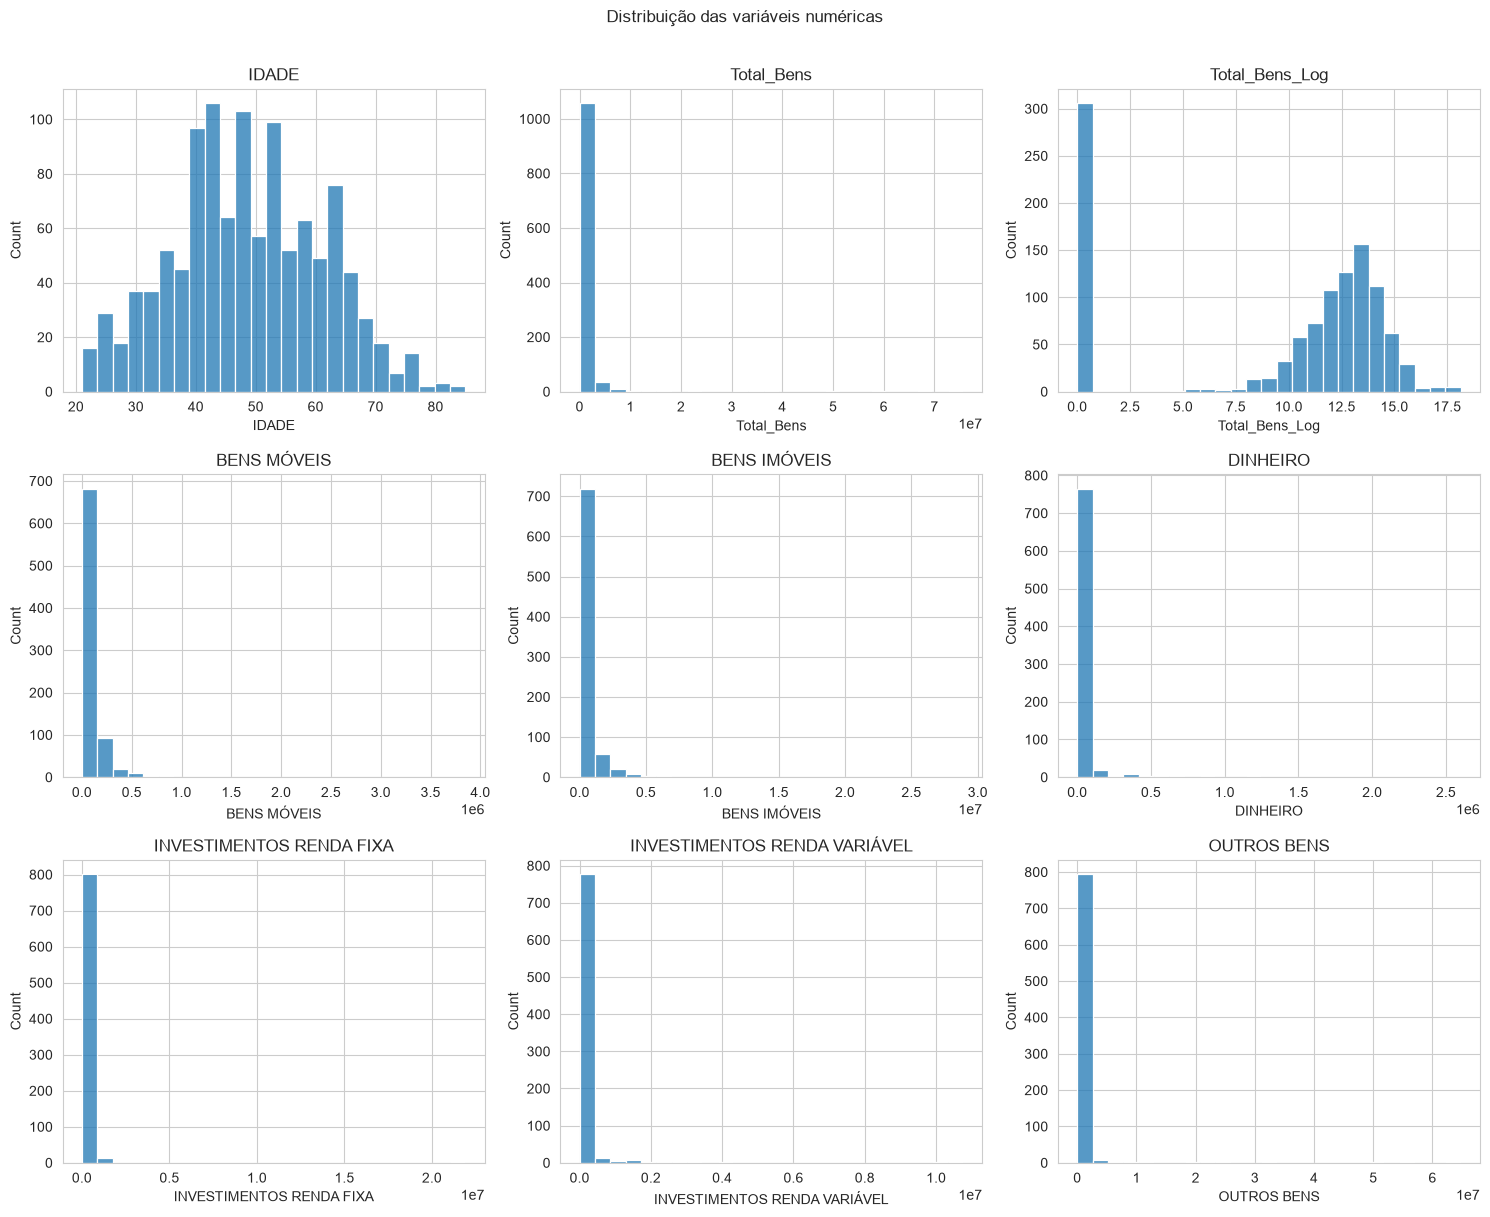

In [8]:
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.histplot(df[col], bins=25, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.01)
plt.tight_layout()
plt.show()

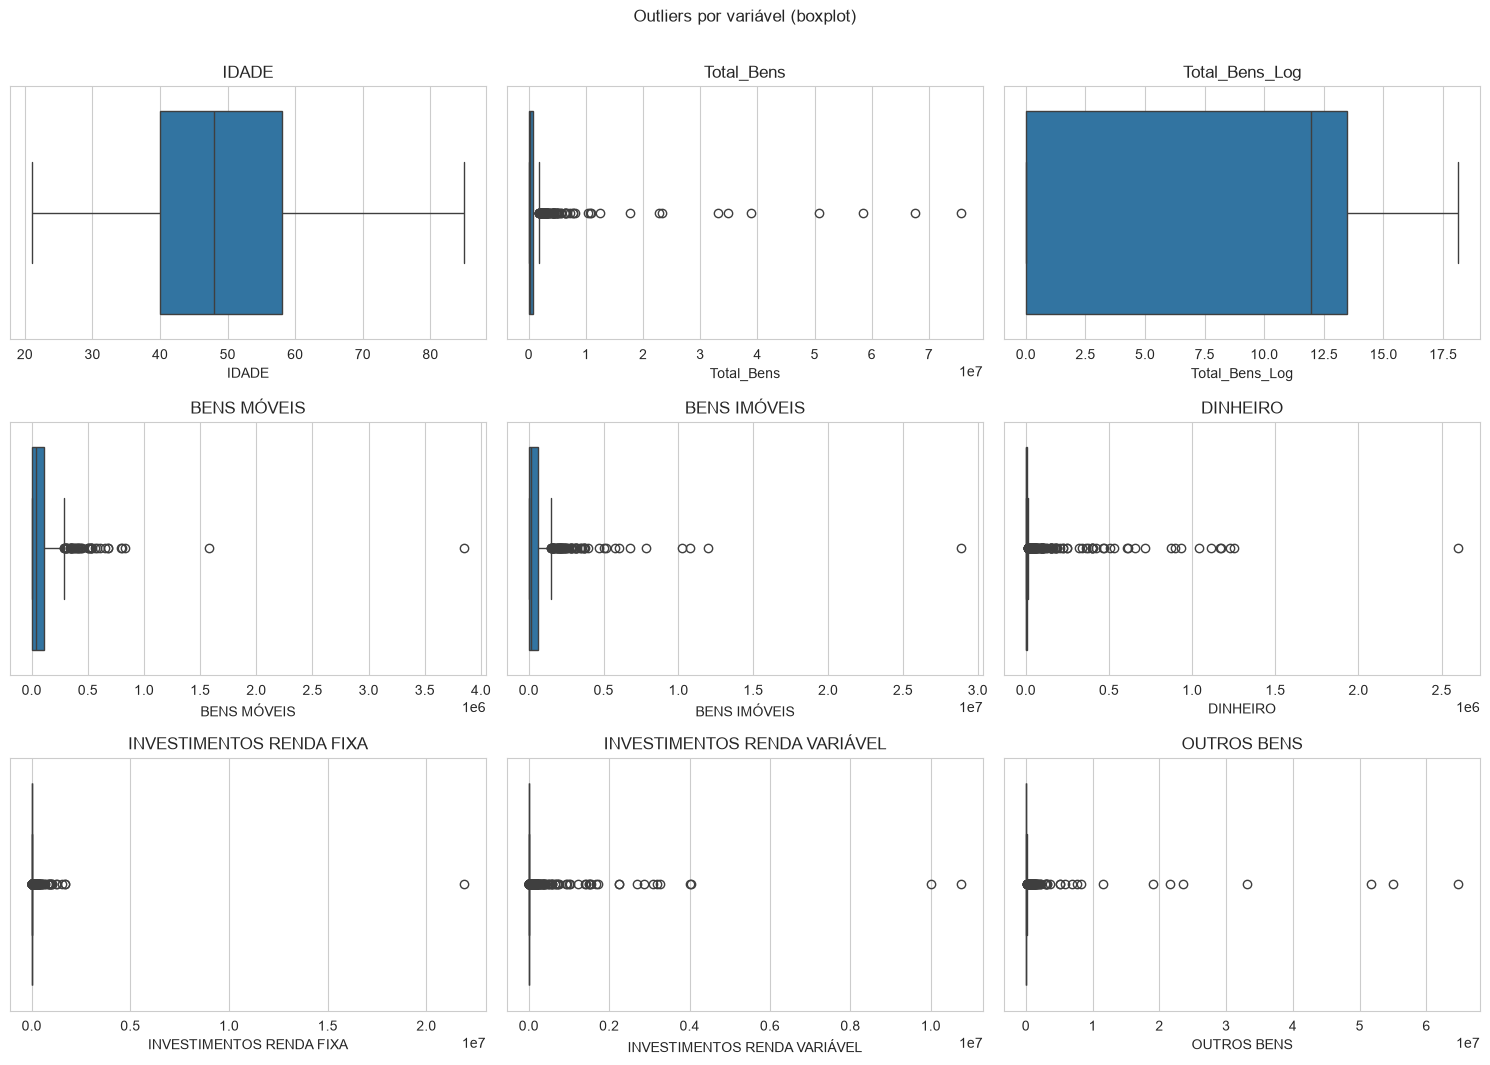

In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outliers por variável (boxplot)', y=1.01)
plt.tight_layout()
plt.show()

### 3.1) Quantificando os outliers (regra do IQR)

O boxplot mostra visualmente; esta tabela quantifica: quantos candidatos ficam fora do intervalo `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` em cada variável.

In [10]:
linhas = []
for col in colunas_numericas:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    linhas.append({
        'variavel': col, 'limite_inferior': lim_inf, 'limite_superior': lim_sup,
        'qtd_outliers': n_outliers, 'pct_outliers': round(100 * n_outliers / len(df), 1),
    })

pd.DataFrame(linhas).sort_values('pct_outliers', ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,pct_outliers
6,INVESTIMENTOS RENDA FIXA,-559.44,932.41,195,17.50
7,INVESTIMENTOS RENDA VARIÁVEL,0.00,0.00,194,17.40
5,DINHEIRO,"-8,310.39","13,850.65",158,14.10
8,OUTROS BENS,"-117,899.37","196,498.94",132,11.80
1,Total_Bens,"-1,065,000.00","1,775,000.00",118,10.60
4,BENS IMÓVEIS,"-900,000.00","1,500,000.00",71,6.40
3,BENS MÓVEIS,"-171,609.00","286,015.00",45,4.00
0,IDADE,13.00,85.00,0,0.00
2,Total_Bens_Log,-20.21,33.68,0,0.00


## 4) Variáveis categóricas: contagens e proporções

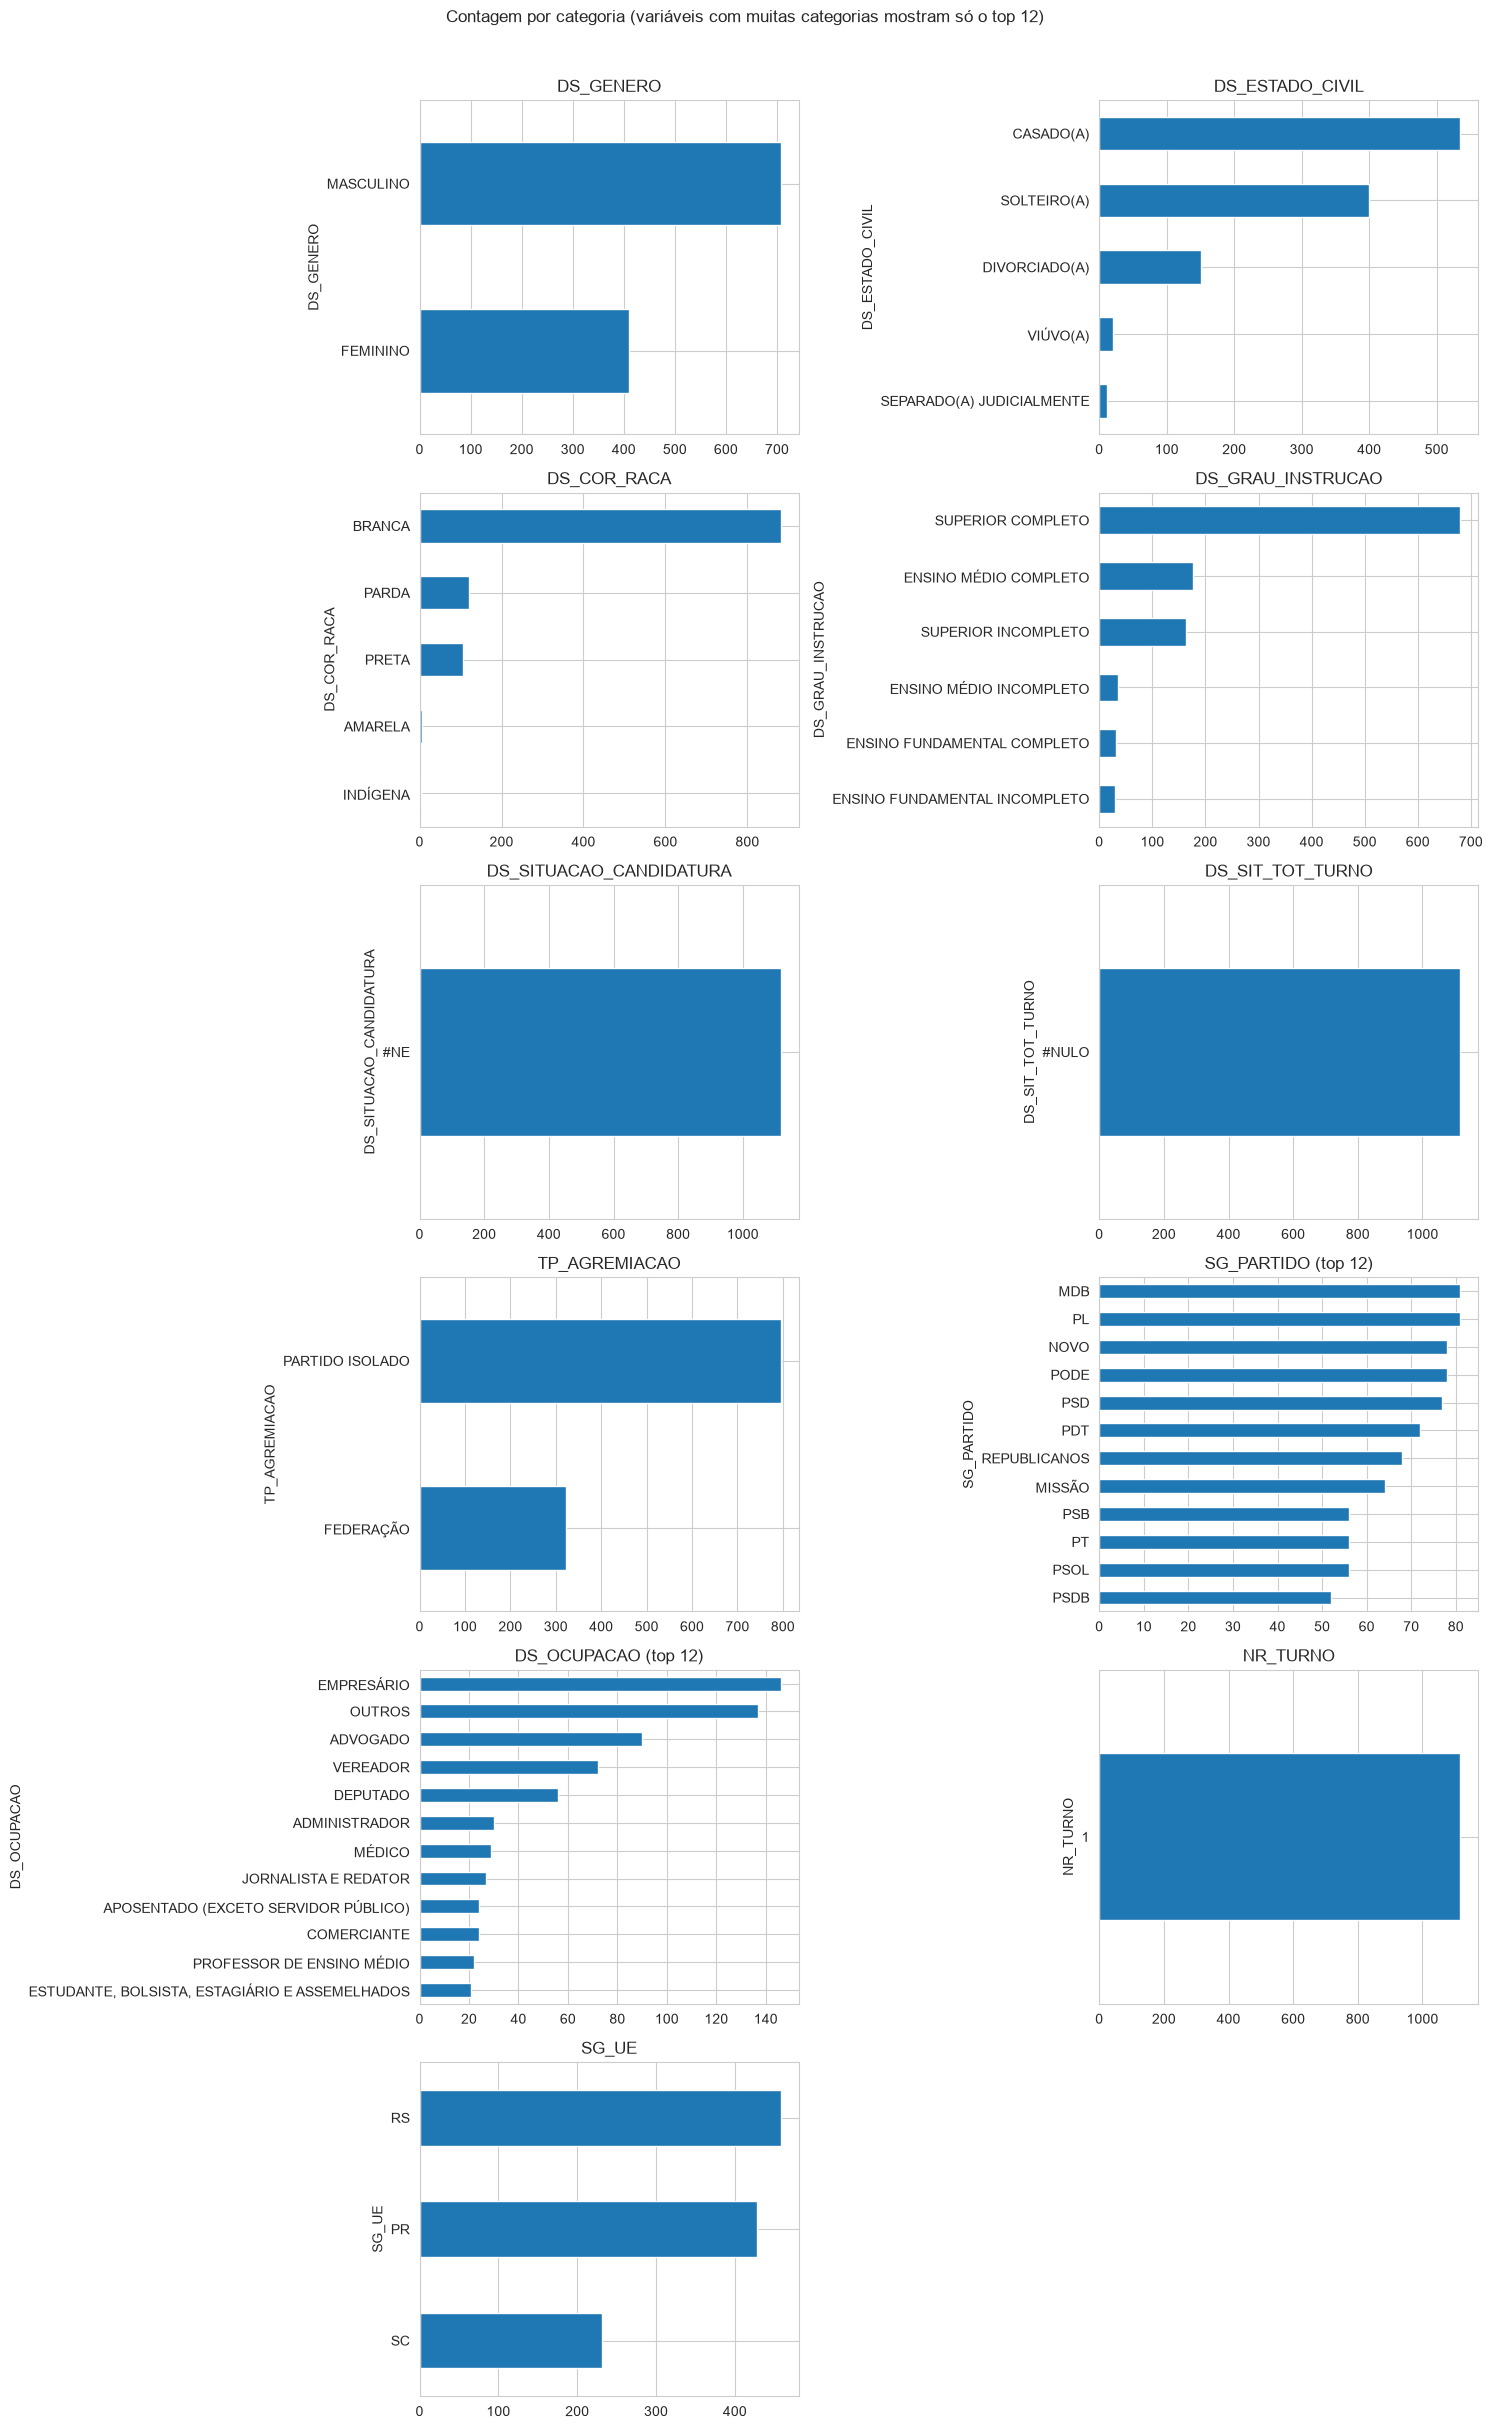

In [11]:
def plot_categorica(ax, coluna, top_n=12):
    contagem = df[coluna].value_counts().head(top_n)
    contagem.plot(kind='barh', ax=ax)
    ax.set_title(coluna + (f' (top {top_n})' if df[coluna].nunique() > top_n else ''))
    ax.invert_yaxis()

n = len(colunas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_categorica(axes[i], col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Contagem por categoria (variáveis com muitas categorias mostram só o top 12)', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
for col in colunas_categoricas:
    print(f"--- {col} ({df[col].nunique()} categorias) ---")
    print((df[col].value_counts(normalize=True).head(8) * 100).round(1).astype(str) + '%')
    print()

--- DS_GENERO (2 categorias) ---
DS_GENERO
MASCULINO    63.3%
FEMININO     36.7%
Name: proportion, dtype: str

--- DS_ESTADO_CIVIL (5 categorias) ---
DS_ESTADO_CIVIL
CASADO(A)                    47.9%
SOLTEIRO(A)                  35.7%
DIVORCIADO(A)                13.5%
VIÚVO(A)                      1.9%
SEPARADO(A) JUDICIALMENTE     1.0%
Name: proportion, dtype: str

--- DS_COR_RACA (5 categorias) ---
DS_COR_RACA
BRANCA      78.9%
PARDA       10.8%
PRETA        9.4%
AMARELA      0.5%
INDÍGENA     0.4%
Name: proportion, dtype: str

--- DS_GRAU_INSTRUCAO (6 categorias) ---
DS_GRAU_INSTRUCAO
SUPERIOR COMPLETO                60.9%
ENSINO MÉDIO COMPLETO            15.8%
SUPERIOR INCOMPLETO              14.6%
ENSINO MÉDIO INCOMPLETO           3.2%
ENSINO FUNDAMENTAL COMPLETO       2.9%
ENSINO FUNDAMENTAL INCOMPLETO     2.6%
Name: proportion, dtype: str

--- DS_SITUACAO_CANDIDATURA (1 categorias) ---
DS_SITUACAO_CANDIDATURA
#NE    100.0%
Name: proportion, dtype: str

--- DS_SIT_TOT_TURNO (1 

## 5) Dispersão entre variáveis numéricas

Correlação e gráficos de dispersão par a par — sem nenhuma variável de destaque, só pra ver como as variáveis se relacionam (ou não).

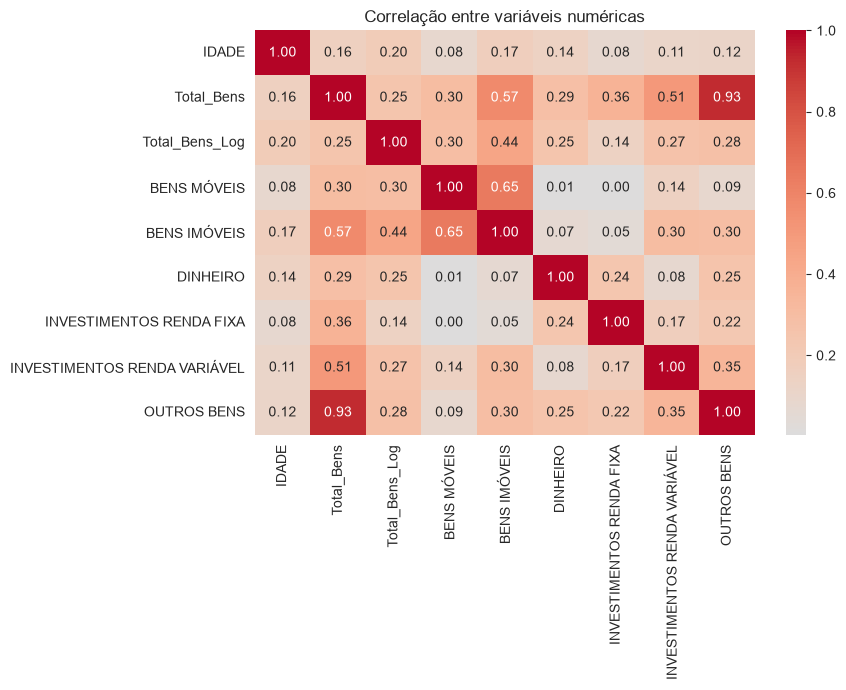

In [13]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

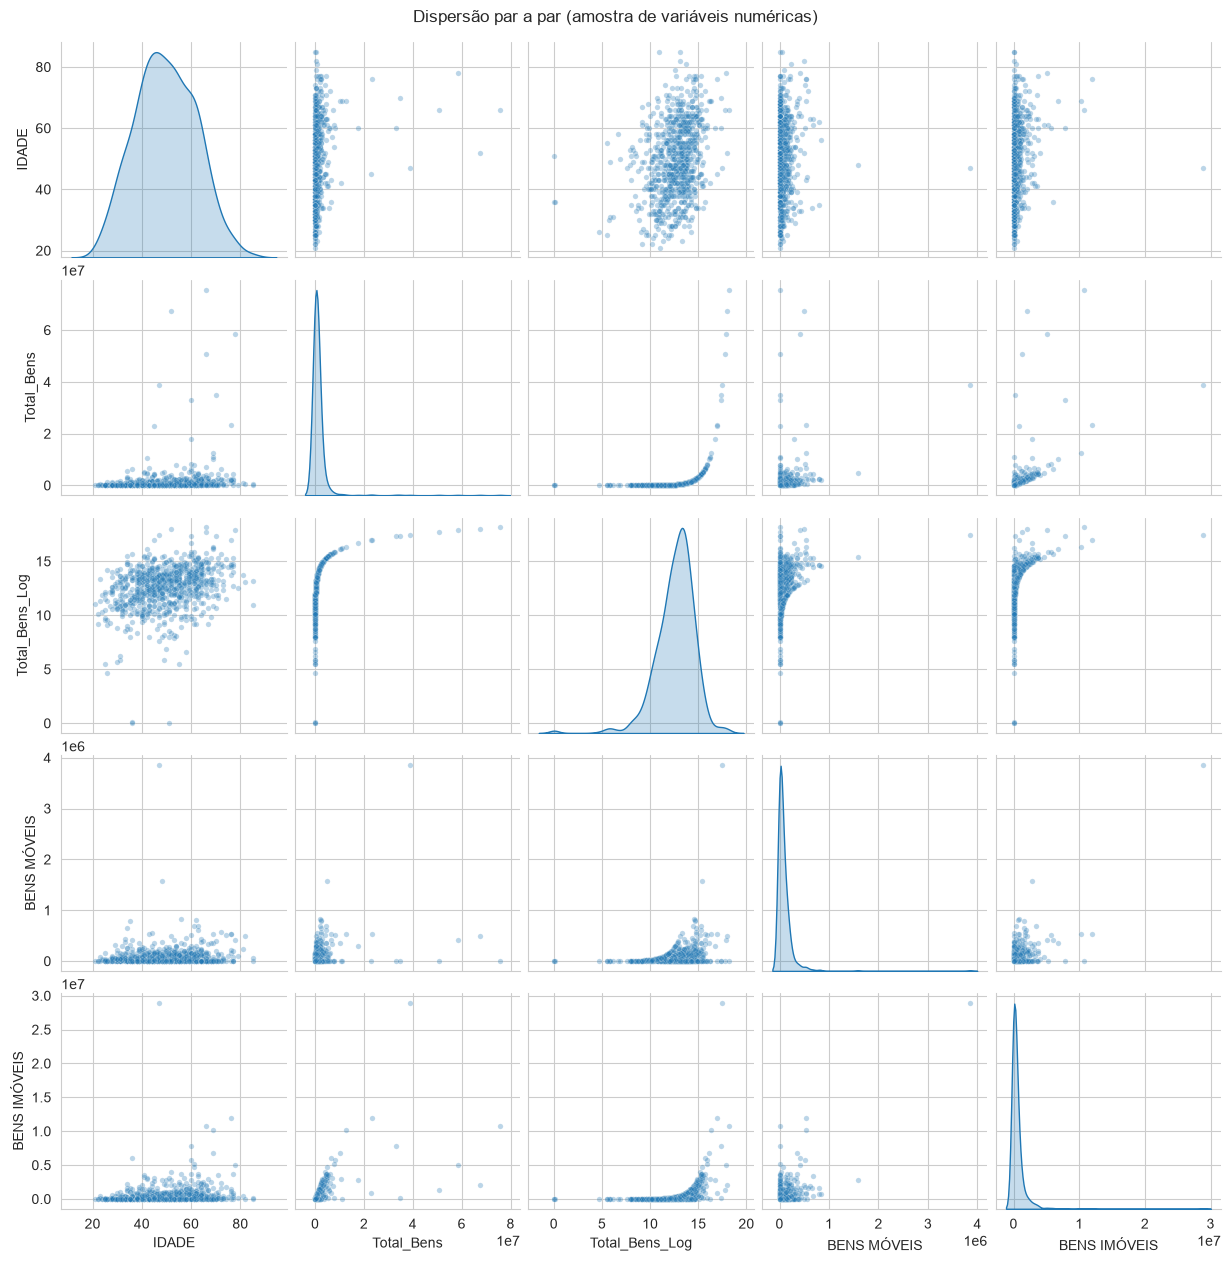

In [14]:
# Pairplot com um subconjunto (pairplot com muitas variáveis fica pesado/ilegível)
subset = colunas_numericas[:5]
sns.pairplot(df[subset].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Dispersão par a par (amostra de variáveis numéricas)', y=1.01)
plt.show()

### 5.1) Um exemplo de dispersão colorida

Só um exemplo de como cruzar uma variável numérica com outra numérica *e* uma categórica ao mesmo tempo — troquem `x`, `y` e `hue` livremente para explorar outras combinações.

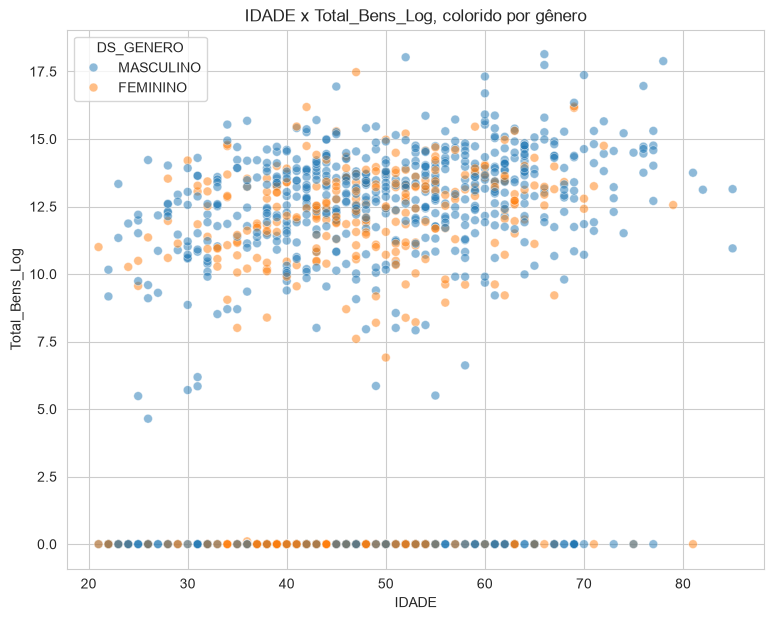

In [15]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='IDADE', y='Total_Bens_Log', hue='DS_GENERO', alpha=0.5, s=40)
plt.title('IDADE x Total_Bens_Log, colorido por gênero')
plt.show()

## 6) Proporções entre grupos

Alguns exemplos de cruzamentos categóricos — não são os únicos possíveis, só uma amostra do tipo de pergunta que dá pra fazer.

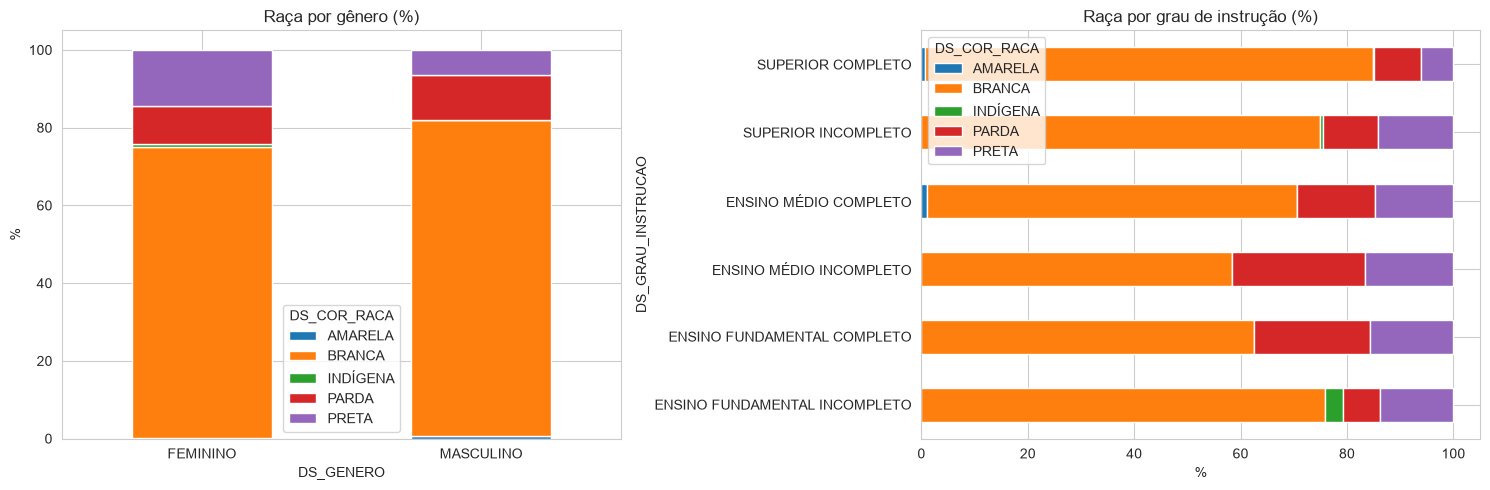

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df['DS_GENERO'], df['DS_COR_RACA'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0]
)
axes[0].set_title('Raça por gênero (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

ordem_instrucao = df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']].drop_duplicates().sort_values('CD_GRAU_INSTRUCAO')['DS_GRAU_INSTRUCAO']
pd.crosstab(df['DS_GRAU_INSTRUCAO'], df['DS_COR_RACA'], normalize='index').loc[ordem_instrucao].mul(100).plot(
    kind='barh', stacked=True, ax=axes[1]
)
axes[1].set_title('Raça por grau de instrução (%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

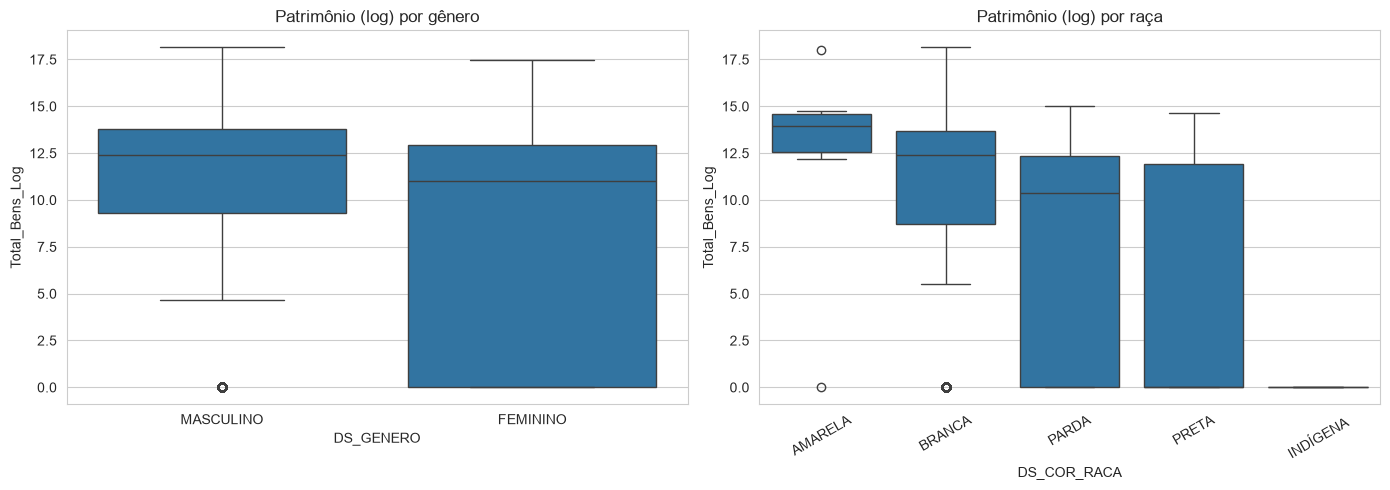

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GENERO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_COR_RACA', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

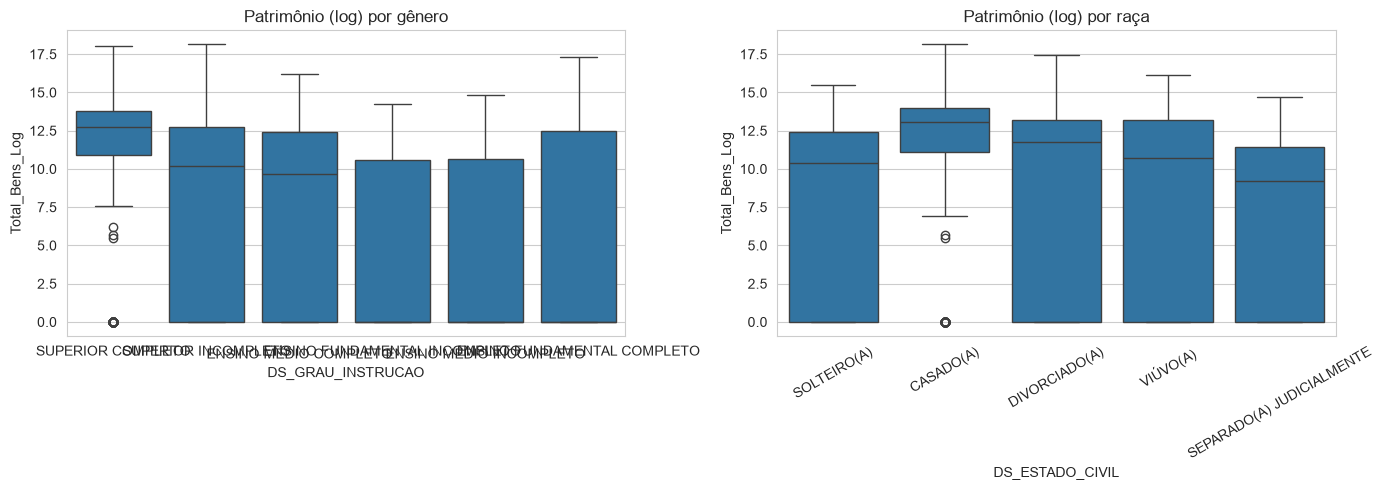

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GRAU_INSTRUCAO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_ESTADO_CIVIL', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

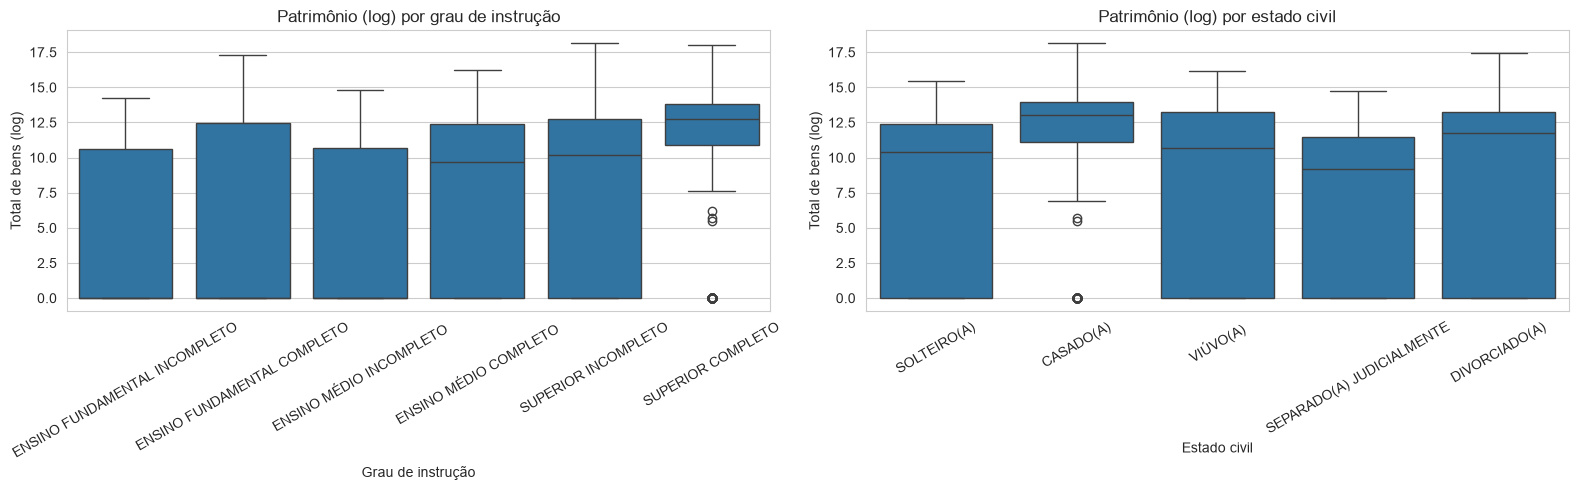

In [19]:
# Ordem do grau de instrução pelo respectivo código
ordem_instrucao = (
    df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']]
    .drop_duplicates()
    .sort_values('CD_GRAU_INSTRUCAO')
    ['DS_GRAU_INSTRUCAO']
    .tolist()
)

# Ordem do estado civil pelo respectivo código
ordem_estado_civil = (
    df[['CD_ESTADO_CIVIL', 'DS_ESTADO_CIVIL']]
    .drop_duplicates()
    .sort_values('CD_ESTADO_CIVIL')
    ['DS_ESTADO_CIVIL']
    .tolist()
)


# Cria os dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Grau de instrução
sns.boxplot(
    data=df,
    x='DS_GRAU_INSTRUCAO',
    y='Total_Bens_Log',
    order=ordem_instrucao,
    ax=axes[0]
)

axes[0].set_title('Patrimônio (log) por grau de instrução')
axes[0].set_xlabel('Grau de instrução')
axes[0].set_ylabel('Total de bens (log)')
axes[0].tick_params(axis='x', rotation=30)


# Estado civil
sns.boxplot(
    data=df,
    x='DS_ESTADO_CIVIL',
    y='Total_Bens_Log',
    order=ordem_estado_civil,
    ax=axes[1]
)

axes[1].set_title('Patrimônio (log) por estado civil')
axes[1].set_xlabel('Estado civil')
axes[1].set_ylabel('Total de bens (log)')
axes[1].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.show()

## 7) Comparação entre UFs

Esta seção só roda na visão **Brasil** (quando `UF = None`) — não se aplica ao recorte por estado.

In [20]:
if UF is None:
    resumo_uf = df.groupby('SG_UF').agg(
        qtd_candidatos=('SQ_CANDIDATO', 'count'),
        idade_media=('IDADE', 'mean'),
        patrimonio_mediano=('Total_Bens', 'median'),
        pct_feminino=('DS_GENERO', lambda x: (x == 'FEMININO').mean() * 100),
    ).round(1).sort_values('qtd_candidatos', ascending=False)

    display(resumo_uf)

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    resumo_uf['qtd_candidatos'].sort_values().plot(kind='barh', ax=axes[0])
    axes[0].set_title(f'Nº de candidatos a {CARGO} por UF')

    resumo_uf['patrimonio_mediano'].sort_values().plot(kind='barh', ax=axes[1], color='tab:orange')
    axes[1].set_title('Patrimônio mediano por UF (R$)')

    plt.tight_layout()
    plt.show()
else:
    print(f"UF = {UF!r} — seção não se aplica (dados já filtrados para uma única UF).")

UF = ['PR', 'RS', 'SC'] — seção não se aplica (dados já filtrados para uma única UF).


## 8) As 4 variáveis do projeto

A clusterização, as regras e as anomalias usam quatro variáveis contínuas: **idade**, **anos de estudo**, **patrimônio declarado** e **gasto de campanha**. Duas delas não estão na base desta fase e são criadas aqui do mesmo jeito que nos notebooks seguintes:

- `ANOS_ESTUDO`: o grau de instrução convertido em anos de estudo equivalentes (0 a 16), porque o código do TSE é ordinal e não tem espaçamento igual entre os níveis (ver `02_clusterizacao.ipynb`, Versão 2);
- `Total_Gasto_Campanha`: a soma das despesas contratadas por candidato, que vem da base gerada no `02_clusterizacao_com_despesa.ipynb` (Parte 1).

In [21]:
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
}

df4 = pd.read_csv("dados/candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv", low_memory=False)
df4['ANOS_ESTUDO'] = df4['DS_GRAU_INSTRUCAO'].str.strip().str.upper().map(ANOS_ESTUDO_POR_GRAU)

variaveis_projeto = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens', 'Total_Gasto_Campanha']

resumo_4 = df4[variaveis_projeto].describe().T
resumo_4['mediana'] = df4[variaveis_projeto].median()
resumo_4['pct_zero'] = (df4[variaveis_projeto] == 0).mean() * 100
display(resumo_4[['count', 'mean', 'mediana', 'std', 'min', '25%', '75%', 'max', 'pct_zero']])

print(f"Correlação entre patrimônio e gasto de campanha (em log): "
      f"{df4['Total_Bens_Log'].corr(df4['Total_Gasto_Campanha_Log']):.2f}")

,count,mean,mediana,std,min,25%,75%,max,pct_zero
IDADE,"1,117.00",48.60,48.00,12.42,21.00,40.00,58.00,85.00,0.00
ANOS_ESTUDO,"1,117.00",14.00,16.00,2.91,4.00,13.00,16.00,16.00,0.00
Total_Bens,"1,117.00","1,003,354.61","157,849.37","4,490,875.42",0.00,0.00,"710,000.00","75,659,161.21",27.31
Total_Gasto_Campanha,"1,117.00","219,403.18","34,336.23","469,919.54",0.00,"3,291.60","144,017.53","3,041,436.15",19.07


Correlação entre patrimônio e gasto de campanha (em log): 0.37


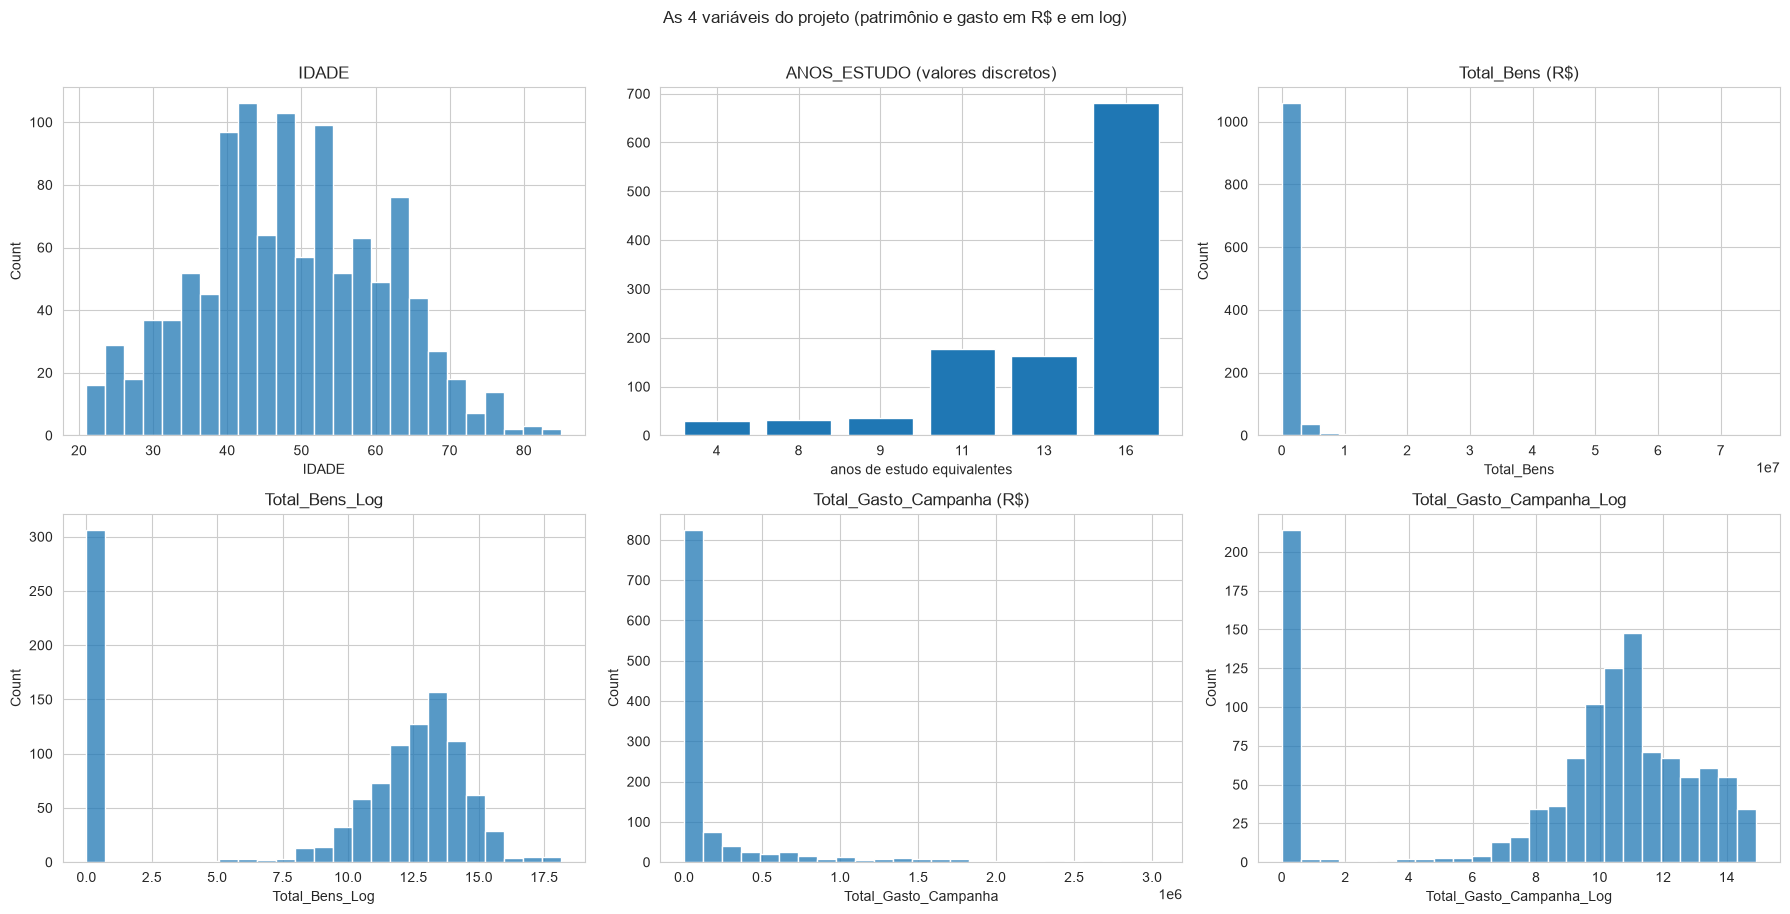

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

sns.histplot(df4['IDADE'], bins=25, ax=axes[0])
axes[0].set_title('IDADE')

contagem_anos = df4['ANOS_ESTUDO'].value_counts().sort_index()
axes[1].bar(contagem_anos.index.astype(int).astype(str), contagem_anos.values)
axes[1].set_title('ANOS_ESTUDO (valores discretos)')
axes[1].set_xlabel('anos de estudo equivalentes')

sns.histplot(df4['Total_Bens'], bins=25, ax=axes[2])
axes[2].set_title('Total_Bens (R$)')

sns.histplot(df4['Total_Bens_Log'], bins=25, ax=axes[3])
axes[3].set_title('Total_Bens_Log')

sns.histplot(df4['Total_Gasto_Campanha'], bins=25, ax=axes[4])
axes[4].set_title('Total_Gasto_Campanha (R$)')

sns.histplot(df4['Total_Gasto_Campanha_Log'], bins=25, ax=axes[5])
axes[5].set_title('Total_Gasto_Campanha_Log')

plt.suptitle('As 4 variáveis do projeto (patrimônio e gasto em R$ e em log)', y=1.01)
plt.tight_layout()
plt.show()

---
## Fechamento: o que os dados mostram

- **Idade** é a variável mais bem comportada: média de 48,6 e mediana de 48 anos, de 21 a 85, com distribuição próxima da normal e poucos outliers.
- **Escolaridade** é alta e concentrada: 61% têm superior completo (16 anos de estudo), e só 5,5% têm apenas o ensino fundamental. A variável tem poucos valores distintos, o que vai limitar as faixas por quartil no Apriori (só 2 faixas).
- **Patrimônio** é muito assimétrico: mediana de R$ 157,8 mil, média de R$ 1,0 mi e máximo de R$ 75,7 mi. **27% declararam patrimônio zero**, o que é alto para um cargo federal. Sem o log, um punhado de candidatos dominaria qualquer cálculo de distância.
- **Gasto de campanha** tem a mesma forma: mediana de R$ 34,3 mil, média de R$ 219 mil, máximo de R$ 3,04 mi e **19% sem nenhuma despesa contratada** até o extrato de 19/09/2026 (a campanha ainda está em andamento, então o valor é parcial).
- Patrimônio e gasto têm **correlação apenas moderada** (0,37 em log): quem tem mais bens não é, necessariamente, quem mais gasta. Por isso o gasto entra como uma quarta variável, e não como repetição do patrimônio.
- O perfil geral é majoritariamente **masculino (63%), branco (79%) e casado (48%)**, com partidos pulverizados e ocupações dominadas por empresários, advogados e vereadores.

Essas observações orientam as fases seguintes: usar **log** para patrimônio e gasto, **anos de estudo** em vez do código do TSE, e prestar atenção à massa de candidatos com **zero** em patrimônio e em gasto, que tende a formar grupos próprios.

## Próximo passo

**Fase 2 — Clusterização:** `02_clusterizacao.ipynb` (K-Means e Bisecting K-Means com 3 variáveis, versão exploratória) e `02_clusterizacao_com_despesa.ipynb` (gasto de campanha e o Bisecting K-Means oficial com as 4 variáveis).

<a id="parte-2"></a>

---

# Parte 02 — Clusterização com gasto de campanha

*Origem: `02_clusterizacao_com_despesa.ipynb`*

<a href="https://colab.research.google.com/github/itagibanetos/mineracao-dados-eleitorais-2026/blob/main/02_clusterizacao_com_despesa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parte 1 — Quanto cada candidato já gastou de campanha**


Nesta etapa, é realizada a importação dos arquivos necessários para a análise a partir do repositório criado no GitHub.

Inicialmente, foi utilizado o comando git clone para criar uma cópia do repositório mineracao-dados-eleitorais-2026 no ambiente do Google Colab. Essa etapa é necessária porque o Colab utiliza um ambiente temporário, ou seja, os arquivos podem deixar de estar disponíveis quando a sessão é encerrada ou reiniciada.

Em seguida, é usado o comando %cd para acessar a pasta do repositório clonada no caminho /content/mineracao-dados-eleitorais-2026. A partir desse momento, é possível utilizar caminhos relativos para acessar os arquivos do projeto, como a pasta dados.

Por fim, é executado o comando !ls dados para listar os arquivos presentes nessa pasta. Dessa forma, pude verificar se os arquivos de dados necessários para as etapas seguintes da análise estavam disponíveis corretamente no ambiente do Colab.

In [22]:
import sys

# Só no Google Colab: localmente os arquivos já estão na pasta do projeto
if "google.colab" in sys.modules:
    !git clone https://github.com/itagibanetos/mineracao-dados-eleitorais-2026.git
    %cd /content/mineracao-dados-eleitorais-2026

!ls dados

'ls' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


O código carrega a base de candidatos a Deputado Federal de PR, RS e SC, extrai do arquivo ZIP apenas os arquivos de despesas contratadas desses estados e processa os dados em partes para reduzir o uso de memória.

Em seguida, filtra as despesas do cargo analisado, soma o gasto contratado e conta a quantidade de despesas de cada candidato. Esses dados são unidos à base principal por meio do identificador `SQ_CANDIDATO`.

Por fim, o código cria as colunas de gasto total, quantidade de despesas, indicação de existência de despesa e gasto em escala logarítmica. A base consolidada é salva em um novo arquivo CSV para ser utilizada nas análises posteriores.

In [23]:
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import numpy as np

# =========================
# 1. Caminhos dos arquivos
# =========================
PASTA_DADOS = Path("dados")
PASTA_EXTRAIDOS = PASTA_DADOS / "extraidos_despesas"

ARQUIVO_CANDIDATOS = (
    PASTA_DADOS / "candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv"
)

ARQUIVO_ZIP = (
    PASTA_DADOS / "prestacao_de_contas_eleitorais_candidatos_2026.zip"
)

ARQUIVO_SAIDA = (
    PASTA_DADOS / "candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv"
)

ESTADOS = ["PR", "RS", "SC"]

# =============================================
# 2. Lê a base principal dos candidatos
# =============================================
candidatos = pd.read_csv(
    ARQUIVO_CANDIDATOS,
    sep=",",
    dtype={"SQ_CANDIDATO": "string"},
    low_memory=False
)

candidatos = candidatos[
    candidatos["DS_CARGO"].str.upper().eq("DEPUTADO FEDERAL")
].copy()

# =========================================================
# 3. Localiza e descompacta somente os CSVs necessários
# =========================================================
PASTA_EXTRAIDOS.mkdir(parents=True, exist_ok=True)

arquivos_esperados = {
    f"despesas_contratadas_candidatos_2026_{uf}.csv".lower()
    for uf in ESTADOS
}

with ZipFile(ARQUIVO_ZIP, "r") as zip_ref:
    arquivos_selecionados = [
        arquivo
        for arquivo in zip_ref.namelist()
        if Path(arquivo).name.lower() in arquivos_esperados
    ]

    if len(arquivos_selecionados) != len(ESTADOS):
        raise FileNotFoundError(
            "Não encontrei os arquivos de despesas contratadas "
            "de PR, RS e SC dentro do ZIP."
        )

    arquivos_extraidos = [
        Path(zip_ref.extract(arquivo, PASTA_EXTRAIDOS))
        for arquivo in arquivos_selecionados
    ]

# =====================================================================
# 4. Processa os arquivos grandes em partes e soma por candidato
# =====================================================================
parciais = []

for arquivo in arquivos_extraidos:
    print(f"Processando: {arquivo.name}")

    leitor = pd.read_csv(
        arquivo,
        sep=";",
        encoding="latin1",
        usecols=[
            "DS_CARGO",
            "SQ_CANDIDATO",
            "SQ_DESPESA",
            "VR_DESPESA_CONTRATADA"
        ],
        dtype={
            "DS_CARGO": "string",
            "SQ_CANDIDATO": "string",
            "SQ_DESPESA": "string",
            "VR_DESPESA_CONTRATADA": "string"
        },
        chunksize=200_000,
        low_memory=False
    )

    for parte in leitor:
        parte = parte[
            parte["DS_CARGO"].str.upper().eq("DEPUTADO FEDERAL")
        ].copy()

        parte["VR_DESPESA_CONTRATADA"] = pd.to_numeric(
            parte["VR_DESPESA_CONTRATADA"]
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False),
            errors="coerce"
        ).fillna(0)

        parcial = (
            parte
            .groupby("SQ_CANDIDATO", as_index=False)
            .agg(
                Total_Gasto_Campanha=(
                    "VR_DESPESA_CONTRATADA", "sum"
                ),
                QTD_DESPESAS_CONTRATADAS=(
                    "SQ_DESPESA", "count"
                )
            )
        )

        parciais.append(parcial)

# Consolida PR, RS e SC
totais_despesas = (
    pd.concat(parciais, ignore_index=True)
    .groupby("SQ_CANDIDATO", as_index=False)
    .agg(
        Total_Gasto_Campanha=(
            "Total_Gasto_Campanha", "sum"
        ),
        QTD_DESPESAS_CONTRATADAS=(
            "QTD_DESPESAS_CONTRATADAS", "sum"
        )
    )
)

# =====================================================
# 5. Une os gastos ao arquivo principal de candidatos
# =====================================================
resultado = candidatos.merge(
    totais_despesas,
    on="SQ_CANDIDATO",
    how="left"
)

resultado["TEM_DESPESA_CONTRATADA"] = (
    resultado["Total_Gasto_Campanha"].notna()
)

resultado["Total_Gasto_Campanha"] = (
    resultado["Total_Gasto_Campanha"].fillna(0)
)

resultado["QTD_DESPESAS_CONTRATADAS"] = (
    resultado["QTD_DESPESAS_CONTRATADAS"].fillna(0).astype(int)
)

# Nova variável com transformação logarítmica
resultado["Total_Gasto_Campanha_Log"] = np.log1p(
    resultado["Total_Gasto_Campanha"]
)

# ======================================
# 6. Gera o CSV para as novas análises
# ======================================
resultado.to_csv(
    ARQUIVO_SAIDA,
    index=False,
    encoding="utf-8-sig"
)

print(f"Arquivo criado: {ARQUIVO_SAIDA}")
display(
    resultado[
        [
            "SG_UF",
            "NM_CANDIDATO",
            "Total_Gasto_Campanha",
            "Total_Gasto_Campanha_Log",
            "QTD_DESPESAS_CONTRATADAS"
        ]
    ].head()
)

Processando: despesas_contratadas_candidatos_2026_PR.csv
Processando: despesas_contratadas_candidatos_2026_RS.csv
Processando: despesas_contratadas_candidatos_2026_SC.csv
Arquivo criado: dados\candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv


,SG_UF,NM_CANDIDATO,Total_Gasto_Campanha,Total_Gasto_Campanha_Log,QTD_DESPESAS_CONTRATADAS
0,PR,MARIO SETO TAKEGUMA JUNIOR,34140.0,10.438254,16
1,PR,ANTÔNIO FERNANDO TEIGAO,59862.86,10.999828,35
2,PR,CAMILLA DE MORAES GONDA,283738.41,12.555812,59
3,PR,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,0.0,0.0,1
4,PR,OMAR RAIMUNDO PICHETH NETO,144017.53,11.877697,48


O código carrega a base consolidada de candidatos com as despesas de campanha e transforma a variável de escolaridade em anos de estudo, utilizando uma tabela de correspondência entre cada nível de instrução e sua quantidade estimada de anos de estudo.

Em seguida, seleciona as variáveis `IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log` e `Total_Gasto_Campanha_Log` para a nova análise. Os registros com valores ausentes, inválidos ou sem informação de escolaridade são removidos.

Depois, as variáveis são padronizadas para que tenham a mesma escala e nenhuma delas exerça influência maior apenas por possuir valores numericamente mais altos.

O código executa o algoritmo K-means para diferentes quantidades de clusters, variando de 2 a 19 grupos. Para cada valor de `k`, calcula o WCSS, utilizado no método do cotovelo, e o índice silhouette, utilizado para avaliar a separação entre os clusters.

Por fim, são gerados um gráfico comparando o cotovelo e o silhouette, uma tabela com os resultados e uma listagem dos valores calculados para cada quantidade de clusters. Esses resultados permitem verificar se a inclusão do gasto de campanha altera a quantidade mais adequada de clusters para a análise.

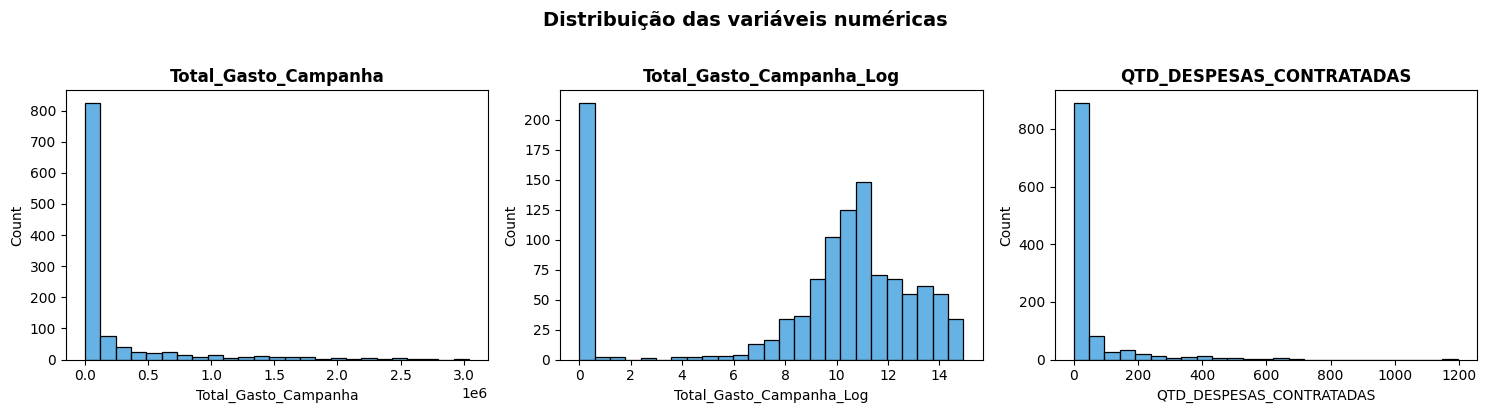

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Definir as colunas numéricas que você deseja plotar
colunas_numericas = ['Total_Gasto_Campanha', 'Total_Gasto_Campanha_Log', 'QTD_DESPESAS_CONTRATADAS']

# 2. Configuração da grade de subplots (igual ao seu modelo)
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))

# Garante que 'axes' seja iterável caso haja apenas 1 linha/coluna
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 3. Loop para plotar o histograma de cada variável
for i, col in enumerate(colunas_numericas):
    sns.histplot(resultado[col], bins=25, ax=axes[i], color='#3498db')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove eventuais subplots vazios da grade
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Candidatos sem correspondência de escolaridade: 0
Registros utilizados na análise: 1,117


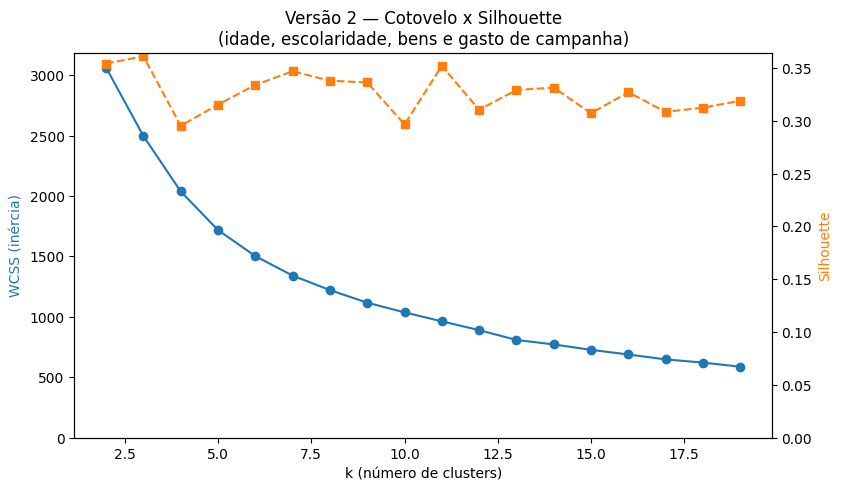

,k,WCSS,Silhouette
0,2,3062.103436,0.354206
1,3,2496.535013,0.361250
2,4,2037.956545,0.295375
3,5,1718.380490,0.315409
4,6,1502.773229,0.334056
5,7,1341.770642,0.346961
6,8,1221.716148,0.338039
7,9,1117.419772,0.336439
8,10,1037.491754,0.296613
9,11,962.996813,0.352052


k=2 | WCSS=3062.103 | silhouette=0.354
k=3 | WCSS=2496.535 | silhouette=0.361
k=4 | WCSS=2037.957 | silhouette=0.295
k=5 | WCSS=1718.380 | silhouette=0.315
k=6 | WCSS=1502.773 | silhouette=0.334
k=7 | WCSS=1341.771 | silhouette=0.347
k=8 | WCSS=1221.716 | silhouette=0.338
k=9 | WCSS=1117.420 | silhouette=0.336
k=10 | WCSS=1037.492 | silhouette=0.297
k=11 | WCSS=962.997 | silhouette=0.352
k=12 | WCSS=890.348 | silhouette=0.311
k=13 | WCSS=808.968 | silhouette=0.329
k=14 | WCSS=772.115 | silhouette=0.332
k=15 | WCSS=727.239 | silhouette=0.307
k=16 | WCSS=688.865 | silhouette=0.327
k=17 | WCSS=648.219 | silhouette=0.309
k=18 | WCSS=621.673 | silhouette=0.312
k=19 | WCSS=587.833 | silhouette=0.319


In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

SEMENTE = 42

# Arquivo gerado na etapa anterior
ARQUIVO_DADOS = Path(
    "dados/candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv"
)

# Carrega a base
df = pd.read_csv(
    ARQUIVO_DADOS,
    encoding="utf-8-sig",
    low_memory=False
)

# Converte escolaridade em anos de estudo
ANOS_ESTUDO_POR_GRAU = {
    "ANALFABETO": 0,
    "LÊ E ESCREVE": 1,
    "ENSINO FUNDAMENTAL INCOMPLETO": 4,
    "ENSINO FUNDAMENTAL COMPLETO": 8,
    "ENSINO MÉDIO INCOMPLETO": 9,
    "ENSINO MÉDIO COMPLETO": 11,
    "SUPERIOR INCOMPLETO": 13,
    "SUPERIOR COMPLETO": 16,
}

df["ANOS_ESTUDO"] = (
    df["DS_GRAU_INSTRUCAO"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map(ANOS_ESTUDO_POR_GRAU)
)

print(
    "Candidatos sem correspondência de escolaridade:",
    df["ANOS_ESTUDO"].isna().sum()
)

# Variáveis da nova análise
variaveis_v2 = [
    "IDADE",
    "ANOS_ESTUDO",
    "Total_Bens_Log",
    "Total_Gasto_Campanha_Log"
]

# Remove registros sem informação suficiente para a clusterização
dados_v2 = (
    df[variaveis_v2]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print(f"Registros utilizados na análise: {len(dados_v2):,}")

# Padroniza as variáveis
scaler_v2 = StandardScaler()
X_v2 = scaler_v2.fit_transform(dados_v2)

# Testa valores de k entre 2 e 19
wcss_v2, sil_v2 = [], []
faixa_k = range(2, 20)

for k in faixa_k:
    km = KMeans(
        n_clusters=k,
        random_state=SEMENTE,
        n_init=10
    )

    labels = km.fit_predict(X_v2)

    wcss_v2.append(km.inertia_)
    sil_v2.append(silhouette_score(X_v2, labels))

# Gráfico de cotovelo e silhouette
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    list(faixa_k),
    wcss_v2,
    marker="o",
    color="tab:blue"
)

ax1.set_xlabel("k (número de clusters)")
ax1.set_ylabel("WCSS (inércia)", color="tab:blue")
ax1.set_ylim(bottom=0)
ax1.set_title(
    "Versão 2 — Cotovelo x Silhouette\n"
    "(idade, escolaridade, bens e gasto de campanha)"
)

ax2 = ax1.twinx()

ax2.plot(
    list(faixa_k),
    sil_v2,
    marker="s",
    linestyle="--",
    color="tab:orange"
)

ax2.set_ylabel("Silhouette", color="tab:orange")
ax2.set_ylim(bottom=min(0, min(sil_v2)))

plt.show()

# Tabela com os resultados
resultado_k_v2 = pd.DataFrame({
    "k": list(faixa_k),
    "WCSS": wcss_v2,
    "Silhouette": sil_v2
})

display(resultado_k_v2)

for k, w, s in zip(faixa_k, wcss_v2, sil_v2):
    print(f"k={k} | WCSS={w:.3f} | silhouette={s:.3f}")

O código aplica o algoritmo K-means utilizando a quantidade final de clusters definida a partir da análise anterior de cotovelo e silhouette.

Inicialmente, são recuperados apenas os registros que foram utilizados na etapa de padronização das variáveis. Isso garante que a clusterização seja aplicada exatamente aos candidatos que possuem informações completas de idade, escolaridade, patrimônio e gasto de campanha.

Em seguida, o algoritmo K-means é executado sobre a matriz padronizada X_v2. O resultado atribui um número de cluster a cada candidato. Esses números são convertidos em letras, de modo que os grupos passem a ser identificados como Cluster A, Cluster B, Cluster C, Cluster D, Cluster E e Cluster F.

Também é criada uma paleta fixa de cores para os clusters. Essa paleta será reutilizada nos gráficos posteriores, permitindo que cada cluster mantenha a mesma cor durante toda a análise.

Por fim, o código calcula e exibe a quantidade de candidatos presente em cada cluster, além de informar o valor de k escolhido e o total de candidatos utilizados na clusterização.

In [26]:
import seaborn as sns
from sklearn.cluster import KMeans

# Escolha o k definido a partir do gráfico anterior
k_final_v2 = 6

# Recupera os registros usados para criar X_v2
df_cluster_v2 = df.loc[dados_v2.index].copy()

# Aplica K-means às variáveis padronizadas
kmeans_v2 = KMeans(
    n_clusters=k_final_v2,
    random_state=SEMENTE,
    n_init=10
)

df_cluster_v2["cluster"] = kmeans_v2.fit_predict(X_v2)

# Troca 0, 1, 2... por A, B, C...
df_cluster_v2["cluster"] = df_cluster_v2["cluster"].map(
    lambda x: chr(65 + x)
)

# Paleta fixa para os gráficos seguintes
clusters_ordenados_v2 = sorted(df_cluster_v2["cluster"].unique())

cores_cluster_v2 = dict(
    zip(
        clusters_ordenados_v2,
        sns.color_palette(
            "Set2",
            n_colors=len(clusters_ordenados_v2)
        )
    )
)

# Quantidade de candidatos por cluster
resumo_clusters_v2 = (
    df_cluster_v2["cluster"]
    .value_counts()
    .sort_index()
    .rename("Quantidade de candidatos")
)

display(resumo_clusters_v2)

print(f"K escolhido: {k_final_v2}")
print(f"Total de candidatos clusterizados: {len(df_cluster_v2):,}")

cluster
A    105
B    311
C    186
D    128
E    254
F    133
Name: Quantidade de candidatos, dtype: int64

K escolhido: 6
Total de candidatos clusterizados: 1,117


O código gera um resumo estatístico para interpretar as características de cada cluster criado pelo algoritmo K-means.

Para cada grupo, são calculados a quantidade de candidatos, a idade média, a média de anos de estudo, o patrimônio mediano, o gasto mediano e médio de campanha, além do percentual de candidatos sem gastos contratados registrados. Os valores são arredondados para uma casa decimal, facilitando a leitura e a comparação entre os clusters.

Em seguida, o código recupera os centróides gerados pelo K-means. Como o algoritmo foi aplicado sobre dados padronizados, os centróides inicialmente estão em uma escala transformada. Por esse motivo, é aplicada a transformação inversa utilizando o `scaler_v2`.

Após essa transformação, os centróides voltam a representar as escalas utilizadas nas variáveis originais: idade, anos de estudo, patrimônio em escala logarítmica e gasto de campanha em escala logarítmica.

Por fim, os centróides recebem as identificações A a F e são apresentados em uma tabela. Essa tabela permite comparar o perfil médio de cada cluster nas quatro variáveis utilizadas pela clusterização.

In [27]:
# Resumo interpretável de cada cluster
resumo_driver_v2 = (
    df_cluster_v2
    .groupby("cluster")
    .agg(
        qtd_candidatos=("SQ_CANDIDATO", "count"),
        idade_media=("IDADE", "mean"),
        anos_estudo_medio=("ANOS_ESTUDO", "mean"),
        patrimonio_mediano=("Total_Bens", "median"),
        gasto_campanha_mediano=("Total_Gasto_Campanha", "median"),
        gasto_campanha_medio=("Total_Gasto_Campanha", "mean"),
        pct_sem_gasto_contratado=(
            "Total_Gasto_Campanha",
            lambda serie: (serie == 0).mean() * 100
        )
    )
    .round(1)
)

display(resumo_driver_v2)

# Centróides nas escalas originais das quatro variáveis usadas no K-means
centroides_norm_v2 = kmeans_v2.cluster_centers_

centroides_naturais_v2 = scaler_v2.inverse_transform(
    centroides_norm_v2
)

df_centroides_v2 = pd.DataFrame(
    centroides_naturais_v2,
    columns=variaveis_v2
)

df_centroides_v2.index = [
    chr(65 + i) for i in range(k_final_v2)
]

df_centroides_v2.index.name = "cluster"

display(df_centroides_v2.round(2))

,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano,gasto_campanha_mediano,gasto_campanha_medio,pct_sem_gasto_contratado
cluster,,,,,,,
A,105,47.9,8.9,0.0,0.0,1828.7,84.8
B,311,40.4,15.7,319900.0,66240.0,322696.1,0.0
C,186,44.5,13.6,0.0,27631.5,79568.9,0.0
D,128,48.9,14.6,78500.0,0.0,1.1,96.9
E,254,61.7,15.7,797677.6,138207.9,430985.6,0.0
F,133,48.9,10.9,250000.0,39752.5,152274.9,0.0


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Gasto_Campanha_Log
cluster,,,,
A,47.88,8.94,1.38,1.09
B,40.37,15.70,12.54,11.19
C,44.47,13.59,0.09,10.12
D,48.91,14.57,9.07,0.11
E,61.68,15.66,13.53,11.80
F,48.95,10.85,12.07,10.57


O código permite definir manualmente a quantidade de clusters que será utilizada na análise por meio da variável `K_FINAL`. Após informar esse valor, o algoritmo K-means é executado novamente utilizando as variáveis padronizadas de idade, anos de estudo, patrimônio e gasto de campanha.

Os candidatos utilizados na clusterização são organizados em grupos identificados por letras, como Cluster A, Cluster B, Cluster C e assim por diante. Também é criada uma paleta de cores fixa para que cada cluster mantenha a mesma cor nos gráficos gerados.

Em seguida, o código recupera os centróides de cada cluster e normaliza seus valores entre 0 e 1. Essa normalização é necessária para permitir a comparação visual das variáveis no gráfico de radar, pois elas possuem escalas diferentes.

Por fim, são gerados dois tipos de visualização: um gráfico de radar com todos os clusters sobrepostos e gráficos individuais para cada cluster. O código também exibe a quantidade de candidatos presente em cada grupo formado.

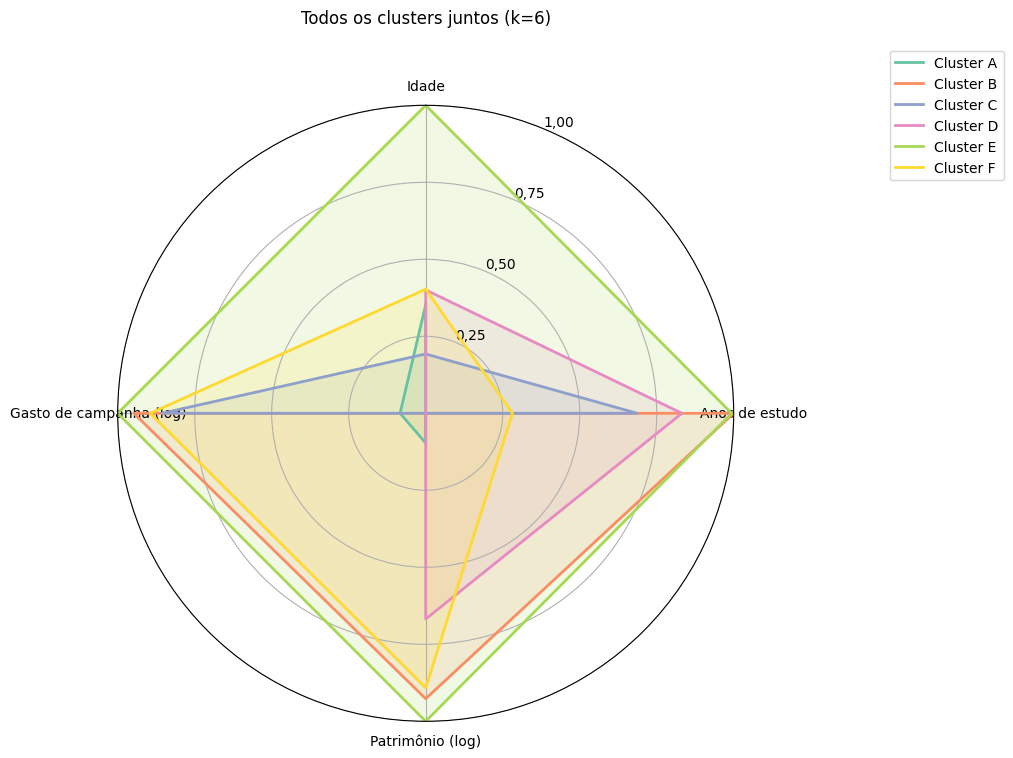

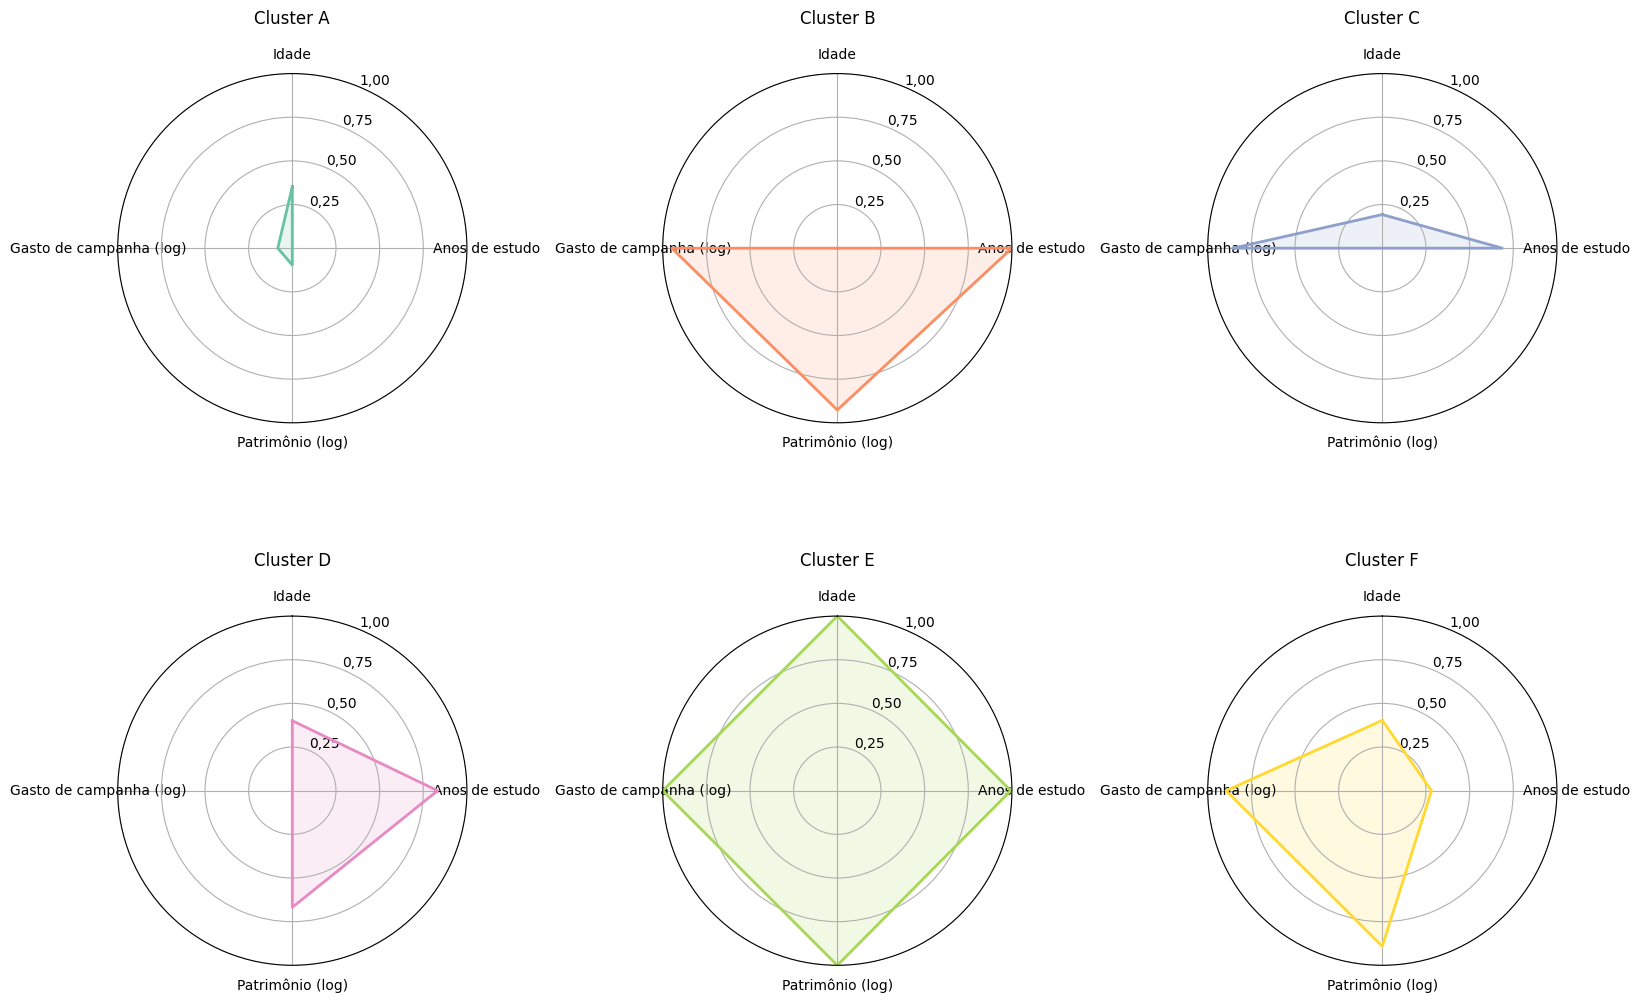

cluster
A    105
B    311
C    186
D    128
E    254
F    133
Name: Quantidade de candidatos, dtype: int64

In [28]:
from math import pi

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# ==================================================
# Informe aqui a quantidade de clusters desejada
# ==================================================
K_FINAL = 6

if K_FINAL < 2 or K_FINAL > len(dados_v2):
    raise ValueError("Informe um valor de K entre 2 e a quantidade de registros.")

# Recupera os candidatos utilizados na clusterização
df_cluster_v2 = df.loc[dados_v2.index].copy()

# Aplica novamente o K-means com o K informado
kmeans_v2 = KMeans(
    n_clusters=K_FINAL,
    random_state=SEMENTE,
    n_init=10
)

df_cluster_v2["cluster"] = kmeans_v2.fit_predict(X_v2)

# Converte os números dos clusters em letras: A, B, C...
df_cluster_v2["cluster"] = df_cluster_v2["cluster"].map(
    lambda x: chr(65 + x)
)

clusters_ordenados_v2 = sorted(df_cluster_v2["cluster"].unique())

# Define uma cor fixa para cada cluster
cores_cluster_v2 = dict(
    zip(
        clusters_ordenados_v2,
        sns.color_palette(
            "Set2",
            n_colors=K_FINAL
        )
    )
)

# Centróides originais das variáveis usadas no K-means
centroides_norm_v2 = kmeans_v2.cluster_centers_

centroides_naturais_v2 = scaler_v2.inverse_transform(
    centroides_norm_v2
)

# Normaliza os centróides entre 0 e 1 somente para o gráfico radar
scaler_radar_v2 = MinMaxScaler()

centros_radar_v2 = scaler_radar_v2.fit_transform(
    centroides_naturais_v2
)

labels_eixos_v2 = [
    "Idade",
    "Anos de estudo",
    "Patrimônio (log)",
    "Gasto de campanha (log)"
]

# Função para criar o gráfico radar
def plot_radar(ax, centros, labels_eixos, labels_series, cores, titulo):
    n_eixos = len(labels_eixos)

    angulos = [
        n / float(n_eixos) * 2 * pi
        for n in range(n_eixos)
    ]

    angulos += angulos[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels(["0,25", "0,50", "0,75", "1,00"])

    for i, linha in enumerate(centros):
        valores = list(linha) + [linha[0]]
        cor = cores[labels_series[i]]

        ax.plot(
            angulos,
            valores,
            linewidth=2,
            label=f"Cluster {labels_series[i]}",
            color=cor
        )

        ax.fill(
            angulos,
            valores,
            alpha=0.15,
            color=cor
        )

    ax.set_title(titulo, y=1.12)


# ==================================================
# Radar com todos os clusters
# ==================================================
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

plot_radar(
    ax,
    centros_radar_v2,
    labels_eixos_v2,
    clusters_ordenados_v2,
    cores_cluster_v2,
    f"Todos os clusters juntos (k={K_FINAL})"
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.45, 1.10)
)

plt.show()


# ==================================================
# Um gráfico radar para cada cluster
# ==================================================
ncols = min(K_FINAL, 3)
nrows = -(-K_FINAL // ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.5 * ncols, 5.5 * nrows),
    subplot_kw=dict(polar=True)
)

axes = np.atleast_1d(axes).ravel()

for i, cluster in enumerate(clusters_ordenados_v2):
    plot_radar(
        axes[i],
        [centros_radar_v2[i]],
        labels_eixos_v2,
        [cluster],
        cores_cluster_v2,
        f"Cluster {cluster}"
    )

# Remove espaços vazios do gráfico
for j in range(len(clusters_ordenados_v2), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Quantidade de candidatos em cada cluster
display(
    df_cluster_v2["cluster"]
    .value_counts()
    .sort_index()
    .rename("Quantidade de candidatos")
)

## **A pergunta de verdade: incluir Total_Gasto_Campanha_Log como uma 4ª variável-driver (junto com IDADE, ANOS_ESTUDO, Total_Bens_Log) muda os clusters da Fase 2? Quem gasta mais é o mesmo grupo de quem tem mais patrimônio, ou gasto de campanha é uma dimensão diferente de patrimônio pessoal?**

A inclusão de Gastos de Campanha como quarta variável-driver altera os clusters da Fase 2, porque introduz uma dimensão que não se confunde totalmente com patrimônio. Embora exista correlação parcial entre riqueza e gasto (r = 0,37 entre os logs), os gráficos mostram que há grupos que gastam muito sem serem os mais abastados — o cluster C do K-Means acima, por exemplo, tem patrimônio mediano zero e gasto mediano de R$ 27,6 mil. Portanto, gasto de campanha é uma dimensão diferente de patrimônio pessoal e contribui para redefinir os perfis dos clusters.

Por isso, a clusterização **oficial** do projeto (Parte 3, abaixo) usa o Bisecting K-Means com as quatro variáveis.

# **Parte 2 — Uma variável categórica por quartil, pra cada variável numérica do modelo**


In [29]:
import pandas as pd
import numpy as np

# Copia a base com os clusters já definidos
df_cluster_regras = df_cluster_v2.copy()

# Variáveis numéricas usadas na clusterização
variaveis_quartis = [
    "IDADE",
    "ANOS_ESTUDO",
    "Total_Bens_Log",
    "Total_Gasto_Campanha_Log"
]

resumo_faixas = []

for variavel in variaveis_quartis:
    nome_faixa = f"{variavel}_Faixa"

    # Gera códigos numéricos para os quartis.
    # labels=False permite lidar corretamente com faixas removidas
    # por valores repetidos.
    codigos_quartis = pd.qcut(
        df_cluster_regras[variavel],
        q=4,
        labels=False,
        duplicates="drop"
    )

    # Identifica quantas faixas foram realmente geradas
    quantidade_faixas = int(codigos_quartis.nunique())

    if quantidade_faixas == 0:
        df_cluster_regras[nome_faixa] = pd.NA
        print(f"{variavel}: nenhuma faixa pôde ser criada.")

        continue

    # Cria nomes dinâmicos: Q1, Q2, Q3 e Q4,
    # ou menos faixas quando houver muitos valores repetidos
    nomes_quartis = [
        f"Q{i + 1}"
        for i in range(quantidade_faixas)
    ]

    mapa_quartis = {
        i: f"Q{i + 1}"
        for i in range(quantidade_faixas)
    }

    df_cluster_regras[nome_faixa] = pd.Categorical(
        codigos_quartis.map(mapa_quartis),
        categories=nomes_quartis,
        ordered=True
    )

    # Cria resumo da distribuição das faixas
    distribuicao = (
        df_cluster_regras[nome_faixa]
        .value_counts(dropna=False)
        .reindex(nomes_quartis, fill_value=0)
    )

    for faixa, quantidade in distribuicao.items():
        resumo_faixas.append({
            "Variavel": variavel,
            "Faixa": faixa,
            "Quantidade": quantidade,
            "Percentual": round(
                quantidade / len(df_cluster_regras) * 100,
                2
            ),
            "Qtd_Faixas_Geradas": quantidade_faixas
        })

    print(
        f"{variavel}: {quantidade_faixas} faixa(s) gerada(s) "
        f"→ {', '.join(nomes_quartis)}"
    )

# Tabela para validação e documentação
resumo_faixas_df = pd.DataFrame(resumo_faixas)

display(resumo_faixas_df)

# Confere as novas colunas criadas
display(
    df_cluster_regras[
        [
            "IDADE",
            "IDADE_Faixa",
            "ANOS_ESTUDO",
            "ANOS_ESTUDO_Faixa",
            "Total_Bens_Log",
            "Total_Bens_Log_Faixa",
            "Total_Gasto_Campanha_Log",
            "Total_Gasto_Campanha_Log_Faixa",
            "cluster"
        ]
    ].head()
)

IDADE: 4 faixa(s) gerada(s) → Q1, Q2, Q3, Q4
ANOS_ESTUDO: 2 faixa(s) gerada(s) → Q1, Q2
Total_Bens_Log: 3 faixa(s) gerada(s) → Q1, Q2, Q3
Total_Gasto_Campanha_Log: 4 faixa(s) gerada(s) → Q1, Q2, Q3, Q4


,Variavel,Faixa,Quantidade,Percentual,Qtd_Faixas_Geradas
0,IDADE,Q1,302,27.04,4
1,IDADE,Q2,278,24.89,4
2,IDADE,Q3,272,24.35,4
3,IDADE,Q4,265,23.72,4
4,ANOS_ESTUDO,Q1,437,39.12,2
5,ANOS_ESTUDO,Q2,680,60.88,2
6,Total_Bens_Log,Q1,559,50.04,3
7,Total_Bens_Log,Q2,280,25.07,3
8,Total_Bens_Log,Q3,278,24.89,3
9,Total_Gasto_Campanha_Log,Q1,280,25.07,4


,IDADE,IDADE_Faixa,ANOS_ESTUDO,ANOS_ESTUDO_Faixa,Total_Bens_Log,Total_Bens_Log_Faixa,Total_Gasto_Campanha_Log,Total_Gasto_Campanha_Log_Faixa,cluster
0,39,Q1,16,Q2,12.187977,Q2,10.438254,Q2,B
1,69,Q4,16,Q2,12.794721,Q2,10.999828,Q3,E
2,25,Q1,16,Q2,9.560198,Q1,12.555812,Q4,B
3,22,Q1,13,Q1,0.000000,Q1,0.000000,Q1,A
4,55,Q3,16,Q2,12.720954,Q2,11.877697,Q3,E


O código criou faixas categóricas por quartil para as variáveis numéricas utilizadas na clusterização: idade, anos de estudo, patrimônio em escala logarítmica e gasto de campanha em escala logarítmica.

A quantidade de faixas obtida pode ser menor que quatro quando existem muitos valores repetidos. Isso ocorreu principalmente nas variáveis `ANOS_ESTUDO` e `Total_Bens_Log`. Em anos de estudo, diversos candidatos apresentam os mesmos níveis de escolaridade, como ensino médio completo ou superior completo. Já em patrimônio, uma parcela relevante dos candidatos possui valor igual a zero.

Para evitar a separação artificial de candidatos com o mesmo valor, foi utilizado o parâmetro `duplicates='drop'`. Dessa forma, o código remove limites de quartis repetidos e mantém apenas as faixas que podem ser formadas de maneira consistente com os dados.

Como resultado, foram geradas duas faixas para anos de estudo e três faixas para patrimônio em escala logarítmica. As variáveis idade e gasto de campanha mantiveram quatro faixas. Essa decisão preserva a integridade dos dados e permite que as variáveis categorizadas sejam utilizadas posteriormente na análise de regras de associação com o algoritmo Apriori.

---
# **Parte 3 — Bisecting K-Means com as 4 variáveis (resultado oficial)**

As orientações pedem a clusterização com **Bisecting K-Means** sobre as quatro variáveis: idade, anos de estudo, patrimônio (log) e gasto de campanha (log). As Partes 1 e 2 usaram K-Means comum; o `02_clusterizacao.ipynb` rodou o Bisecting só com três variáveis (sem despesas). Aqui juntamos as duas coisas, e **este é o resultado usado nos notebooks `03` (regras de associação) e `04` (anomalias)**.

Reaproveitamos a mesma implementação manual do `02_clusterizacao.ipynb` (`bisecting_kmeans_com_historico`, critério de inércia média) e a mesma matriz `X_v2` desta página (4 variáveis, `StandardScaler`, 1.117 candidatos).

In [30]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score


def bisecting_kmeans_com_historico(X, k_max, criterio='inercia', random_state=SEMENTE):
    """
    Mesma implementação do 02_clusterizacao.ipynb (Parte 2): roda o Bisecting K-Means
    manualmente até k_max clusters, guardando qual cluster foi dividido em cada passo.

    criterio:
      'tamanho'  -> a cada passo, divide o cluster com MAIS pontos
      'inercia'  -> a cada passo, divide o cluster com MAIOR inércia MÉDIA (dispersão por ponto)
    """
    def inercia(indices):
        if len(indices) < 2:
            return 0.0
        pontos = X[indices]
        centro = pontos.mean(axis=0)
        return float(((pontos - centro) ** 2).sum(axis=1).mean())

    clusters = {0: np.arange(X.shape[0])}
    historico = []
    proximo_id = 1

    for nivel in range(1, k_max):
        if criterio == 'tamanho':
            id_escolhido = max(clusters, key=lambda cid: len(clusters[cid]))
        else:
            id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))

        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break

        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        filho_a = indices_pai[labels2 == 0]
        filho_b = indices_pai[labels2 == 1]

        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2

        historico.append({
            'k_resultante': nivel + 1,
            'pai_id': id_escolhido, 'pai_tamanho': len(indices_pai), 'pai_inercia': inercia(indices_pai),
            'filho_a_id': id_a, 'filho_a_tamanho': len(filho_a),
            'filho_b_id': id_b, 'filho_b_tamanho': len(filho_b),
        })

        del clusters[id_escolhido]
        clusters[id_a] = filho_a
        clusters[id_b] = filho_b

    return clusters, historico


def particao_bisecting_em_k(X, historico, k):
    """Refaz as divisões do histórico até k clusters (o KMeans com a mesma SEMENTE é
    determinístico) e devolve um rótulo por candidato: A = maior cluster, B = o seguinte..."""
    clusters_no_k = {0: np.arange(X.shape[0])}
    for h in historico:
        if h['k_resultante'] > k:
            break
        indices_pai = clusters_no_k.pop(h['pai_id'])
        labels2 = KMeans(n_clusters=2, random_state=SEMENTE, n_init=10).fit_predict(X[indices_pai])
        clusters_no_k[h['filho_a_id']] = indices_pai[labels2 == 0]
        clusters_no_k[h['filho_b_id']] = indices_pai[labels2 == 1]

    ids_por_tamanho = sorted(clusters_no_k, key=lambda cid: len(clusters_no_k[cid]), reverse=True)
    rotulos = np.empty(X.shape[0], dtype=object)
    for i, cid in enumerate(ids_por_tamanho):
        rotulos[clusters_no_k[cid]] = chr(65 + i)
    return rotulos


k_max_bisecting_v2 = 10
_, historico_bisecting_v2 = bisecting_kmeans_com_historico(X_v2, k_max_bisecting_v2, criterio='inercia')

display(pd.DataFrame(historico_bisecting_v2)[
    ['k_resultante', 'pai_tamanho', 'pai_inercia', 'filho_a_tamanho', 'filho_b_tamanho']
].round(3))

,k_resultante,pai_tamanho,pai_inercia,filho_a_tamanho,filho_b_tamanho
0,2,1117,4.000,405,712
1,3,405,4.222,222,183
2,4,183,3.516,94,89
3,5,89,2.804,50,39
4,6,222,2.637,132,90
5,7,90,2.261,49,41
6,8,41,2.046,12,29
7,9,94,2.040,46,48
8,10,712,1.899,387,325


### Dois critérios diferentes: *qual cluster dividir* × *quando parar*

É fácil confundir os dois, então vale separar:

1. **Qual cluster dividir a cada passo** — decidido pelo próprio algoritmo: o de **maior inércia média** (a tabela acima, colunas `pai_tamanho` e `pai_inercia`). Isso **não é** o método do cotovelo; só diz qual grupo está mais espalhado naquele momento.
2. **Em que k parar** — decisão nossa. Para cada k, reconstruímos a partição completa e medimos a qualidade dela como um todo, com as mesmas métricas usadas no K-Means:
   - **WCSS total** (soma das inércias de todos os clusters) → **método do cotovelo**;
   - **Silhouette** (maior = melhor);
   - **Davies-Bouldin** (menor = melhor);
   - **Calinski-Harabasz** (maior = melhor).

,k,WCSS,Silhouette,Davies_Bouldin,Calinski_Harabasz,menor_cluster,tamanhos,ganho_WCSS
0,2,3062.103,0.354,1.376,511.927,405,712 / 405,NaN
1,3,2581.102,0.345,1.399,407.191,183,712 / 222 / 183,481.001
2,4,2378.994,0.341,1.339,325.777,89,712 / 222 / 94 / 89,202.108
3,5,2284.791,0.337,1.231,265.640,39,712 / 222 / 94 / 50 / 39,94.203
4,6,2104.422,0.317,1.199,249.564,39,712 / 132 / 94 / 90 / 50 / 39,180.369
5,7,2040.714,0.300,1.223,220.044,39,712 / 132 / 94 / 50 / 49 / 41 / 39,63.708
6,8,2003.910,0.292,1.149,194.810,12,712 / 132 / 94 / 50 / 49 / 39 / 29 / 12,36.805
7,9,1930.604,0.293,1.160,182.031,12,712 / 132 / 50 / 49 / 48 / 46 / 39 / 29 / 12,73.306
8,10,1475.769,0.275,1.186,249.392,12,387 / 325 / 132 / 50 / 49 / 48 / 46 / 39 / 29 ...,454.834


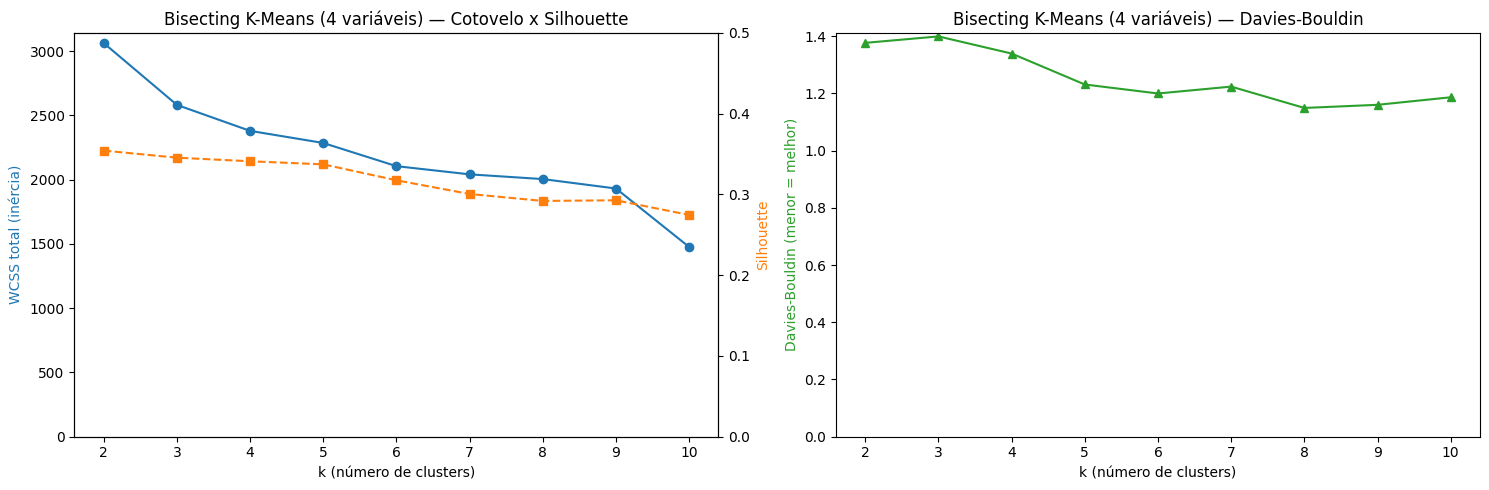

In [31]:
metricas_bisecting = []
particoes_bisecting_v2 = {}

for k in range(2, k_max_bisecting_v2 + 1):
    rotulos_k = particao_bisecting_em_k(X_v2, historico_bisecting_v2, k)
    particoes_bisecting_v2[k] = rotulos_k
    wcss_k = sum(
        ((X_v2[rotulos_k == c] - X_v2[rotulos_k == c].mean(axis=0)) ** 2).sum()
        for c in np.unique(rotulos_k)
    )
    tamanhos = pd.Series(rotulos_k).value_counts()
    metricas_bisecting.append({
        'k': k,
        'WCSS': wcss_k,
        'Silhouette': silhouette_score(X_v2, rotulos_k),
        'Davies_Bouldin': davies_bouldin_score(X_v2, rotulos_k),
        'Calinski_Harabasz': calinski_harabasz_score(X_v2, rotulos_k),
        'menor_cluster': int(tamanhos.min()),
        'tamanhos': ' / '.join(str(t) for t in tamanhos.sort_index()),
    })

metricas_bisecting = pd.DataFrame(metricas_bisecting)
metricas_bisecting['ganho_WCSS'] = -metricas_bisecting['WCSS'].diff()
display(metricas_bisecting.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
ax1.plot(metricas_bisecting['k'], metricas_bisecting['WCSS'], marker='o', color='tab:blue')
ax1.set_xlabel('k (número de clusters)')
ax1.set_ylabel('WCSS total (inércia)', color='tab:blue')
ax1.set_ylim(bottom=0)
ax1.set_title('Bisecting K-Means (4 variáveis) — Cotovelo x Silhouette')
ax1b = ax1.twinx()
ax1b.plot(metricas_bisecting['k'], metricas_bisecting['Silhouette'], marker='s', linestyle='--', color='tab:orange')
ax1b.set_ylabel('Silhouette', color='tab:orange')
ax1b.set_ylim(0, 0.5)

ax2 = axes[1]
ax2.plot(metricas_bisecting['k'], metricas_bisecting['Davies_Bouldin'], marker='^', color='tab:green')
ax2.set_xlabel('k (número de clusters)')
ax2.set_ylabel('Davies-Bouldin (menor = melhor)', color='tab:green')
ax2.set_ylim(bottom=0)
ax2.set_title('Bisecting K-Means (4 variáveis) — Davies-Bouldin')

plt.tight_layout()
plt.show()

### Escolha do k

Escolhemos **k = 4**, cruzando três argumentos:

1. **Cotovelo.** A redução de WCSS a cada nova divisão cai rápido: 481 (k=3), 202 (k=4), 94 (k=5). Depois de k=4, cada divisão acrescenta pouca explicação. (O salto em k=10 é a primeira divisão do grupo grande de 712 candidatos, que o critério de inércia média só escolhe depois de esgotar os grupos menores.)
2. **Silhouette e Davies-Bouldin.** A silhouette quase não muda de k=2 a k=4 (0,354 → 0,345 → 0,341), e o Davies-Bouldin **melhora** em k=4 (1,339, contra 1,399 em k=3). Ou seja, a quarta divisão não piora a separação dos grupos. Para comparação, o K-Means com as mesmas 4 variáveis tem silhouette de 0,361 (k=3) e 0,295 (k=4).
3. **Interpretabilidade.** A divisão de k=4 separa, entre quem ainda não tem gasto de campanha, um grupo mais jovem e escolarizado de outro mais velho e de baixa escolaridade — dois perfis que fazem sentido separados. Já k=5 só quebra esse último grupo em pedaços de 50 e 39 candidatos (menos de 5% da base cada), sem um perfil novo.

Silhouette — Bisecting K-Means, 4 variáveis (k=4): 0.341


,qtd,idade_media,anos_estudo_medio,patrimonio_mediano,pct_sem_bens,gasto_mediano,gasto_medio,pct_sem_gasto,pct_do_total
cluster_bisecting,,,,,,,,,
A,712,50.0,15.1,506199.4,0.1,66131.0,322018.8,6.3,63.7
B,222,44.6,12.8,0.0,86.9,23728.0,70807.8,0.0,19.9
C,94,42.5,13.7,0.0,76.6,0.0,4.0,94.7,8.4
D,89,53.7,8.6,16000.0,43.8,0.0,856.7,88.8,8.0


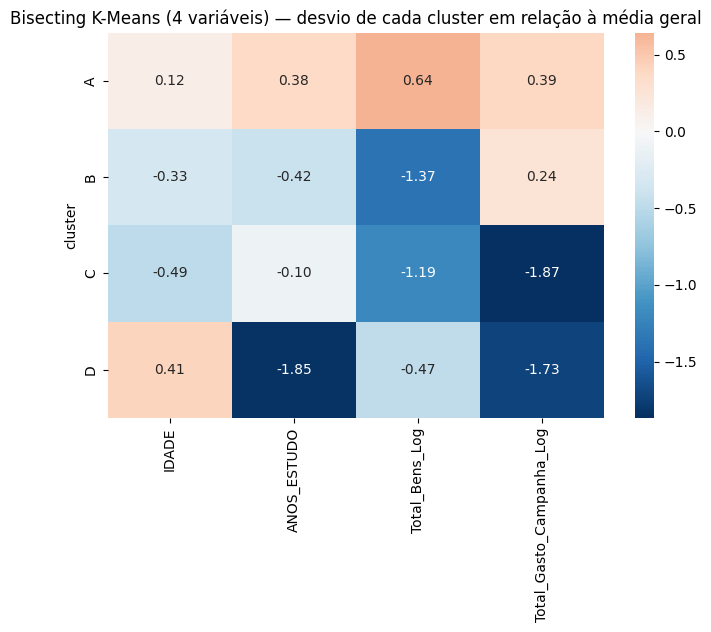

In [34]:
k_bisecting_v2 = 4

df_bisecting_v2 = df.loc[dados_v2.index].copy()
df_bisecting_v2['cluster_bisecting'] = particoes_bisecting_v2[k_bisecting_v2]
clusters_bisecting_v2 = sorted(df_bisecting_v2['cluster_bisecting'].unique())

print(f"Silhouette — Bisecting K-Means, 4 variáveis (k={k_bisecting_v2}): "
      f"{silhouette_score(X_v2, df_bisecting_v2['cluster_bisecting']):.3f}")

ficha_bisecting_v2 = df_bisecting_v2.groupby('cluster_bisecting').agg(
    qtd=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
    pct_sem_bens=('Total_Bens', lambda s: (s == 0).mean() * 100),
    gasto_mediano=('Total_Gasto_Campanha', 'median'),
    gasto_medio=('Total_Gasto_Campanha', 'mean'),
    pct_sem_gasto=('Total_Gasto_Campanha', lambda s: (s == 0).mean() * 100),
).round(1)
ficha_bisecting_v2['pct_do_total'] = (ficha_bisecting_v2['qtd'] / ficha_bisecting_v2['qtd'].sum() * 100).round(1)
display(ficha_bisecting_v2)

# Desvio de cada cluster em relação à média geral, em desvios-padrão
zscore_bisecting_v2 = (
    (df_bisecting_v2.groupby('cluster_bisecting')[variaveis_v2].mean() - dados_v2.mean()) / dados_v2.std()
)
plt.figure(figsize=(8, 1 + k_bisecting_v2))
sns.heatmap(zscore_bisecting_v2, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Bisecting K-Means (4 variáveis) — desvio de cada cluster em relação à média geral')
plt.xlabel('')
plt.ylabel('cluster')
plt.show()

In [36]:
NOMES_CLUSTER_BISECTING = {
    'A': 'Estabelecidos com patrimônio e campanha',
    'B': 'Em campanha sem patrimônio declarado',
    'C': 'Jovens sem patrimônio e sem campanha',
    'D': 'Baixa escolaridade e sem campanha',
}
df_bisecting_v2['nome_cluster_bisecting'] = df_bisecting_v2['cluster_bisecting'].map(NOMES_CLUSTER_BISECTING)
nomes_bisecting_v2 = [NOMES_CLUSTER_BISECTING[c] for c in clusters_bisecting_v2]
cores_nome_bisecting_v2 = dict(zip(nomes_bisecting_v2, sns.color_palette('Set2', n_colors=len(nomes_bisecting_v2))))

df_bisecting_v2[['cluster_bisecting', 'nome_cluster_bisecting']].value_counts().sort_index()

cluster_bisecting  nome_cluster_bisecting                 
A                  Estabelecidos com patrimônio e campanha    712
B                  Em campanha sem patrimônio declarado       222
C                  Jovens sem patrimônio e sem campanha        94
D                  Baixa escolaridade e sem campanha           89
Name: count, dtype: int64

### Perfil dos clusters: gênero, cor/raça e estado civil

Essas variáveis **não entraram** na clusterização; servem para descrever os grupos depois de prontos.

DS_GENERO,FEMININO,MASCULINO
cluster_bisecting,,
A,32.9,67.1
B,48.6,51.4
C,40.4,59.6
D,33.7,66.3


DS_COR_RACA,AMARELA,BRANCA,INDÍGENA,PARDA,PRETA
cluster_bisecting,,,,,
A,0.7,85.3,0.0,8.6,5.5
B,0.5,63.1,1.8,16.2,18.5
C,0.0,73.4,0.0,12.8,13.8
D,0.0,73.0,0.0,13.5,13.5


DS_ESTADO_CIVIL,CASADO(A),DIVORCIADO(A),SEPARADO(A) JUDICIALMENTE,SOLTEIRO(A),VIÚVO(A)
cluster_bisecting,,,,,
A,57.2,12.2,0.7,28.4,1.5
B,30.2,14.0,1.8,51.8,2.3
C,27.7,19.1,0.0,53.2,0.0
D,39.3,16.9,2.2,36.0,5.6


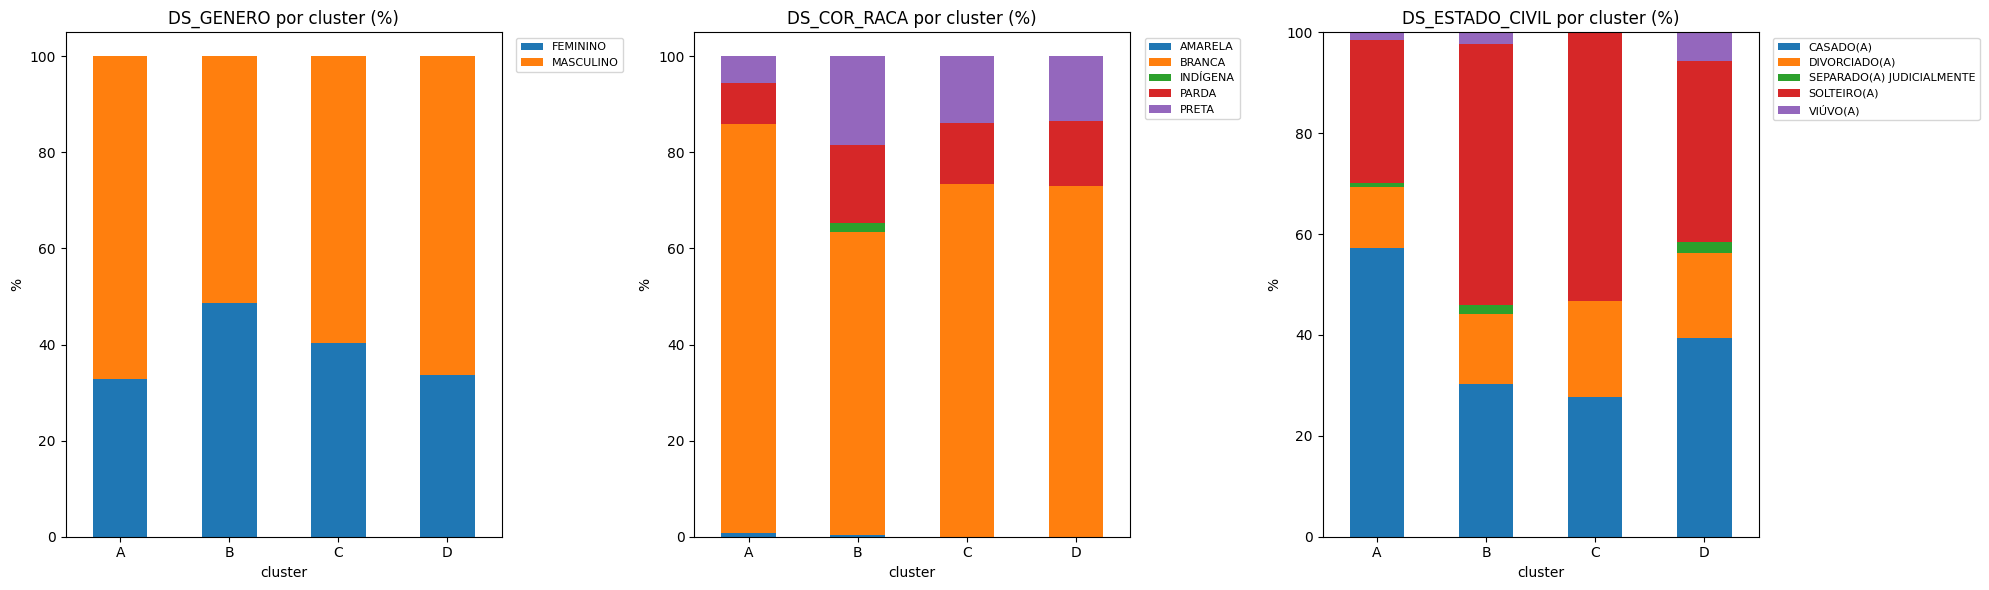

In [41]:

colunas_perfil = ['DS_GENERO', 'DS_COR_RACA', 'DS_ESTADO_CIVIL']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col in zip(axes, colunas_perfil):
    tabela = pd.crosstab(df_bisecting_v2['cluster_bisecting'], df_bisecting_v2[col], normalize='index').mul(100)
    display(tabela.round(1))
    tabela.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'{col} por cluster (%)')
    ax.set_ylabel('%')
    ax.set_xlabel('cluster')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

### Profissão, partido e UF

Profissão (`DS_OCUPACAO`) e partido (`SG_PARTIDO`) têm dezenas de categorias, então mostramos só as 5 mais frequentes de cada cluster.

In [ ]:
for cl in clusters_bisecting_v2:
    sub = df_bisecting_v2[df_bisecting_v2['cluster_bisecting'] == cl]
    print(f"Cluster {cl} — {NOMES_CLUSTER_BISECTING[cl]} ({len(sub)} candidatos)")
    for coluna, titulo in [('DS_OCUPACAO', 'Ocupações'), ('SG_PARTIDO', 'Partidos')]:
        top5 = (sub[coluna].value_counts(normalize=True) * 100).head(5)
        print(f"  {titulo}: " + '; '.join(f"{valor} ({pct:.1f}%)" for valor, pct in top5.items()))
    print()

display(
    pd.crosstab(df_bisecting_v2['cluster_bisecting'], df_bisecting_v2['SG_UF'], normalize='index')
    .mul(100).round(1)
)

Cluster A — Estabelecidos com patrimônio e campanha (712 candidatos)
  Ocupações: EMPRESÁRIO (14.0%); ADVOGADO (10.0%); VEREADOR (8.6%); DEPUTADO (7.6%); OUTROS (7.2%)
  Partidos: PL (9.4%); PODE (9.1%); MDB (8.3%); NOVO (8.3%); REPUBLICANOS (7.6%)

Cluster B — Em campanha sem patrimônio declarado (222 candidatos)
  Ocupações: OUTROS (19.4%); EMPRESÁRIO (14.0%); ADVOGADO (5.9%); ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS (4.1%); VEREADOR (4.1%)
  Partidos: PSOL (10.4%); MISSÃO (9.5%); PSD (7.7%); PSB (7.2%); MDB (7.2%)

Cluster C — Nível superior sem campanha (94 candidatos)
  Ocupações: OUTROS (25.5%); ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS (6.4%); EMPRESÁRIO (6.4%); ADVOGADO (6.4%); ADMINISTRADOR (6.4%)
  Partidos: DC (14.9%); DEMOCRATA (11.7%); MISSÃO (10.6%); AVANTE (10.6%); PSD (8.5%)

Cluster D — Base popular sem campanha (89 candidatos)
  Ocupações: OUTROS (21.3%); COMERCIANTE (11.2%); EMPRESÁRIO (10.1%); DONA DE CASA (9.0%); APOSENTADO (EXCETO SERVIDOR PÚBLICO) (4.5

SG_UF,PR,RS,SC
cluster_bisecting,,,
A,39.9,37.9,22.2
B,34.2,42.3,23.4
C,40.4,46.8,12.8
D,33.7,56.2,10.1


### Nomes finais dos clusters (Bisecting K-Means, 4 variáveis, k=4)

Os nomes vêm da ficha técnica, do heatmap de desvio e das tabelas de perfil acima. As duas primeiras divisões da árvore explicam a lógica: o **1º corte** separa quem tem patrimônio **e** campanha (712) do resto (405); o **2º corte** separa, dentro desse resto, quem já tem gasto de campanha (222) de quem ainda não tem (183); o **3º corte** divide os sem gasto por escolaridade e idade (94 / 89).

| Cluster | n | Idade | Anos de estudo | Sem bens | Sem gasto | Nome |
|---|---|---|---|---|---|---|
| A | 712 (64%) | 50,0 | 15,1 | 0,1% | 6,3% | **Estabelecidos com patrimônio e campanha** |
| B | 222 (20%) | 44,6 | 12,8 | 86,9% | 0% | **Em campanha sem patrimônio declarado** |
| C | 94 (8%) | 42,5 | 13,7 | 76,6% | 94,7% | **Nível superior sem campanha** |
| D | 89 (8%) | 53,7 | 8,6 | 43,8% | 88,8% | **Base popular sem campanha** |

- **A — Estabelecidos com patrimônio e campanha.** Praticamente todos declaram bens (mediana de R$ 506 mil) e já têm despesas contratadas (mediana de R$ 66 mil). É o grupo mais branco (85%), mais masculino (67%) e mais casado (57%). As ocupações mais comuns são empresário, advogado, vereador e deputado: é onde estão os políticos de carreira.
- **B — Em campanha sem patrimônio declarado.** Todos já gastam (mediana de R$ 24 mil), mas 87% não declararam bens. É o grupo **mais feminino** (49%) e **menos branco** (35% pretos ou pardos). PSOL é o partido mais frequente, e estudante aparece entre as ocupações mais comuns: um perfil de candidatura militante ou de renovação, com estrutura de campanha mas sem patrimônio pessoal.
- **C — Nível superior sem campanha.** 95% sem nenhuma despesa contratada até a data do extrato e 77% sem bens declarados. O que o separa do grupo D é a escolaridade: 72% têm ensino superior completo ou incompleto (no D, só 2%). É também o grupo mais jovem (42,5 anos; 48% têm até 40 anos) e o de mais solteiros (53%). Os partidos mais comuns são pequenos (DC, Democrata, Missão, Avante).
  *Por que não "escolarizados"?* O nível superior do C é alto **em relação ao D**, não em relação à base inteira (72% contra 76% no total). As regras de associação do `03` mostram isso: o item mais associado ao C é superior **incompleto**.
- **D — Base popular sem campanha.** A menor escolaridade da base (8,6 anos; 40% com ensino médio completo, 40% só com o fundamental e nenhum com superior completo) e o grupo mais velho (53,7 anos). Também sem gasto de campanha, e metade declara algum bem de valor baixo (mediana de R$ 16 mil). As ocupações são comerciante, dona de casa e aposentado; os partidos, DC, Democrata e Agir. 56% são do RS.

> **Cuidado na leitura de "sem campanha":** o gasto vem das despesas contratadas até o extrato de 19/09/2026, com a campanha ainda em andamento. "Sem gasto" quer dizer "sem despesa registrada até essa data", e não necessariamente que a candidatura não fará campanha.

<a id="parte-3"></a>

---

# Parte 03 — Regras de associação

*Origem: `03_regras_associacao.ipynb`*

<a href="https://colab.research.google.com/github/Rflavia/mineracao_dados/blob/main/03_regras_associacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 3 — Regras de Associação: Candidatos 2026 (TSE)

## Pergunta de negócio

> **Que combinações de características dos candidatos aparecem juntas com mais frequência do que se fossem independentes? Em particular: quais atributos (partido, gênero, escolaridade, cor/raça, UF de nascimento) estão associados a cada perfil identificado na Fase 2 — e, assim que a eleição ocorrer, a ser eleito?**

Até aqui, a clusterização (Fase 2) agrupou candidatos por **distância** em variáveis numéricas (idade, escolaridade, patrimônio). Regras de associação fazem uma pergunta diferente: em vez de "quem está perto de quem", **quais combinações de atributos categóricos aparecem juntas com mais frequência do que o acaso explicaria**? A técnica clássica pra isso é o **Apriori**, que originalmente resolve o problema da "cesta de compras" (que produtos são comprados juntos) — aqui, cada candidato é uma cesta, e cada valor de cada variável categórica (partido, gênero, escolaridade...) é um item dessa cesta.


### Carregamento do repositório
A célula abaixo prepara o repositório no ambiente temporário do Google Colab. Caso o repositório ainda não esteja disponível no ambiente, ele será clonado do GitHub. Se a pasta mineracao_dados já existir, o clone não será realizado novamente. Em seguida, o diretório de trabalho é definido e a pasta dados é disponibilizada por meio do sparse checkout.

In [7]:
import os
import sys
#Nesta fase, vamos usar o repositório mineracao_dados para acessar os dados e scripts necessários.

# Só no Google Colab: localmente os arquivos já estão na pasta do projeto
# (e o sparse-checkout abaixo alteraria o repositório local)
if "google.colab" in sys.modules:
    if not os.path.exists('/content/mineracao_dados'):
        !git clone --depth 1 --filter=blob:none --sparse https://github.com/Rflavia/mineracao_dados.git
    else:
        print("Repositório já existe no ambiente.")

    %cd /content/mineracao_dados
    !git sparse-checkout set dados

## Configuração

Use os **mesmos valores** que você usou nas Fases 0/1/2, para carregar o arquivo certo.


In [8]:
CARGO = "DEPUTADO FEDERAL"
UFS_REGIAO = ["PR", "RS" , "SC"]
ANO_ELEICAO = 2026


## Preparando a base — reconstituindo os clusters nomeados da Fase 2

Apriori precisa de **itens categóricos**, não de distância — mas queremos incluir o cluster da Fase 2 como mais um item da cesta (pra achar regras do tipo "esse perfil de candidato é do cluster X"). O resultado oficial da Fase 2 é o **Bisecting K-Means com as 4 variáveis** (`IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log`, `Total_Gasto_Campanha_Log`, padronizadas com `StandardScaler`), **k=4**, critério de inércia média — ver `02_clusterizacao_com_despesa.ipynb`, Parte 3. Os quatro clusters foram batizados a partir da ficha técnica e da composição demográfica/partidária:

- **A — Estabelecidos com patrimônio e campanha** (712, 64%): declaram bens e já têm gasto de campanha.
- **B — Em campanha sem patrimônio declarado** (222, 20%): todos já gastam, mas 87% não declararam bens.
- **C — Nível superior sem campanha** (94, 8%): 95% sem gasto; 72% com superior completo ou incompleto; o grupo mais jovem.
- **D — Base popular sem campanha** (89, 8%): a menor escolaridade (8,6 anos) e o grupo mais velho, 89% sem gasto.

Recalculamos aqui, rapidamente, a mesma partição (mesma `SEMENTE`, mesmo critério, mesmos nomes), para este notebook rodar sozinho.

In [9]:
import warnings
warnings.filterwarnings("ignore")
if "google.colab" in sys.modules:
    !pip install -q pyvis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules
from pyvis.network import Network
from IPython.display import IFrame

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)  # não truncar antecedents/consequents nas tabelas

SEMENTE = 42
np.random.seed(SEMENTE)  # mesmo racional de reprodutibilidade defensiva dos notebooks anteriores

if UFS_REGIAO is None:
    nome_uf = "BRASIL"
elif isinstance(UFS_REGIAO, list):
    nome_uf = "_".join(UFS_REGIAO)
else:
    nome_uf = UFS_REGIAO



nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}_com_despesas.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_DEPUTADO_FEDERAL_PR_RS_SC_2026_com_despesas.csv  ->  1117 candidatos, 63 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE,Total_Gasto_Campanha,QTD_DESPESAS_CONTRATADAS,TEM_DESPESA_CONTRATADA,Total_Gasto_Campanha_Log
0,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532588,4050,MARIO SETO TAKEGUMA JUNIOR,MARIO CERTO,#NULO,6434321910,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1987-01-07,92467190698,2,MASCULINO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),4,AMARELA,132,PSICÓLOGO,-1,#NULO,0.0,45000.0,11544.24,87605.86,0.0,52262.32,196412.42,12.187977,39,34140.00,16,True,10.438254
1,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532589,4045,ANTÔNIO FERNANDO TEIGAO,FERNANDÃO,#NULO,30357934920,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1957-10-21,12790340663,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,257,EMPRESÁRIO,-1,#NULO,0.0,87000.0,4984.47,25453.75,15000.0,227871.27,360309.49,12.794721,69,59862.86,35,True,10.999828
2,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532590,4000,CAMILLA DE MORAES GONDA,CAMILLA GONDA,#NULO,10555616924,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,2000-10-14,115434590639,4,FEMININO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),1,BRANCA,278,VEREADOR,-1,#NULO,0.0,0.0,0.00,14187.66,0.0,0.00,14187.66,9.560198,25,283738.41,59,True,12.555812
3,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532591,4070,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,CHARLESTON JÚNIOR INCLUSÃO,#NULO,10945908946,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,2004-07-05,124740900612,2,MASCULINO,7,SUPERIOR INCOMPLETO,1,SOLTEIRO(A),1,BRANCA,931,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,22,0.00,1,True,0.000000
4,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532592,4077,OMAR RAIMUNDO PICHETH NETO,OMAR PICHETH,#NULO,82002045968,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1971-07-28,46300400663,2,MASCULINO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,278,VEREADOR,-1,#NULO,275000.0,40000.0,0.00,19686.98,0.0,0.00,334686.98,12.720954,55,144017.53,48,True,11.877697


In [10]:
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
    # 'NÃO DIVULGÁVEL' fica de fora de propósito — mesma decisão da Versão 2 do notebook de clusterização
}

df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].str.strip().str.upper().map(ANOS_ESTUDO_POR_GRAU)

In [11]:
# mesmas 4 variáveis e mesma padronização do 02_clusterizacao_com_despesa.ipynb (Parte 3)
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Gasto_Campanha_Log']

df_cluster = df.dropna(subset=colunas_driver).copy()
print(f"Base para clusterização/regras: {df_cluster.shape[0]} candidatos "
      f"(descartados {df.shape[0] - df_cluster.shape[0]} sem alguma das 4 variáveis)")

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])

Base para clusterização/regras: 1117 candidatos (descartados 0 sem alguma das 4 variáveis)


In [19]:
def inercia(indices):
    if len(indices) < 2:
        return 0.0
    pontos = X[indices]
    centro = pontos.mean(axis=0)
    return float(((pontos - centro) ** 2).sum(axis=1).mean())


def bisecting_kmeans_ate_k(X, k_max, random_state=SEMENTE):
    """Mesma lógica do 02_clusterizacao_com_despesa.ipynb (Parte 3, critério de inércia média) — mas só
    devolve a partição final em k_max clusters, sem guardar o histórico de divisões (essa
    exploração já foi feita e documentada lá)."""
    clusters = {0: np.arange(X.shape[0])}
    proximo_id = 1
    for _ in range(1, k_max):
        id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))
        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break
        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2
        del clusters[id_escolhido]
        clusters[id_a] = indices_pai[labels2 == 0]
        clusters[id_b] = indices_pai[labels2 == 1]
    return clusters


k_bisecting = 4  # mesmo k escolhido no 02_clusterizacao_com_despesa.ipynb (Parte 3)

clusters_finais = bisecting_kmeans_ate_k(X, k_bisecting)
ids_por_tamanho = sorted(clusters_finais, key=lambda cid: len(clusters_finais[cid]), reverse=True)

rotulos = np.empty(X.shape[0], dtype=object)
for letra, cid in zip([chr(65 + i) for i in range(len(ids_por_tamanho))], ids_por_tamanho):
    rotulos[clusters_finais[cid]] = letra
df_cluster['cluster_bisecting'] = rotulos

# mesmos nomes definidos no 02_clusterizacao_com_despesa.ipynb (Parte 3), a partir da mesma ficha técnica
NOMES_CLUSTER_BISECTING = {
    'A': 'Estabelecidos com patrimônio e campanha',
    'B': 'Em campanha sem patrimônio declarado',
    'C': 'Jovens sem patrimônio e sem campanha',
    'D': 'Baixa escolaridade e sem campanha',
}
df_cluster['cluster'] = df_cluster['cluster_bisecting'].map(NOMES_CLUSTER_BISECTING)

df_cluster['cluster'].value_counts().sort_index()

cluster
Baixa escolaridade e sem campanha           89
Em campanha sem patrimônio declarado       222
Estabelecidos com patrimônio e campanha    712
Jovens sem patrimônio e sem campanha        94
Name: count, dtype: int64

### Faixas por quartil das 4 variáveis contínuas

O Apriori só aceita itens categóricos, então cada variável contínua do modelo vira uma faixa por quartil (mesma regra da Parte 2 do `02_clusterizacao_com_despesa.ipynb`: `pd.qcut(q=4, duplicates='drop')`). Quando muitos candidatos têm o mesmo valor, alguns limites de quartil coincidem e a variável fica com menos de 4 faixas:

- `ANOS_ESTUDO` fica com **2 faixas**, porque 61% dos candidatos têm exatamente 16 anos (superior completo);
- `Total_Bens_Log` fica com **3 faixas**, porque 27% declararam patrimônio zero (a primeira faixa junta os zeros com quem tem até a mediana).

Para facilitar a leitura das regras, o nome de cada faixa traz o intervalo em unidades naturais (anos ou R$), e não em log.

In [20]:
def formatar_reais(valor):
    if valor < 1_000:
        return f"R$ {valor:,.0f}"
    if valor < 1_000_000:
        return f"R$ {valor / 1_000:,.0f} mil"
    return f"R$ {valor / 1_000_000:,.1f} mi"


variaveis_faixa = {
    'IDADE': lambda v: f"{v:.0f}",
    'ANOS_ESTUDO': lambda v: f"{v:.0f}",
    'Total_Bens_Log': lambda v: formatar_reais(np.expm1(v)),            # volta do log para R$
    'Total_Gasto_Campanha_Log': lambda v: formatar_reais(np.expm1(v)),
}

for variavel, fmt in variaveis_faixa.items():
    codigos, limites = pd.qcut(df_cluster[variavel], q=4, labels=False, retbins=True, duplicates='drop')
    rotulos_faixa = {
        i: f"Q{i + 1} ({fmt(limites[i])} a {fmt(limites[i + 1])})"
        for i in range(len(limites) - 1)
    }
    df_cluster[f'{variavel}_Faixa'] = codigos.map(rotulos_faixa)

colunas_faixa = [f'{v}_Faixa' for v in variaveis_faixa]

for col in colunas_faixa:
    print(f"--- {col} ---")
    print(df_cluster[col].value_counts().sort_index().to_string())
    print()

--- IDADE_Faixa ---
IDADE_Faixa
Q1 (21 a 40)    302
Q2 (40 a 48)    278
Q3 (48 a 58)    272
Q4 (58 a 85)    265

--- ANOS_ESTUDO_Faixa ---
ANOS_ESTUDO_Faixa
Q1 (4 a 13)     437
Q2 (13 a 16)    680

--- Total_Bens_Log_Faixa ---
Total_Bens_Log_Faixa
Q1 (R$ 0 a R$ 158 mil)          559
Q2 (R$ 158 mil a R$ 710 mil)    280
Q3 (R$ 710 mil a R$ 75.7 mi)    278

--- Total_Gasto_Campanha_Log_Faixa ---
Total_Gasto_Campanha_Log_Faixa
Q1 (R$ 0 a R$ 3 mil)           280
Q2 (R$ 3 mil a R$ 34 mil)      279
Q3 (R$ 34 mil a R$ 144 mil)    279
Q4 (R$ 144 mil a R$ 3.0 mi)    279



## Montando a "cesta" de itens

Apriori não trabalha com números contínuos como o K-Means — ele precisa de **itens binários** (presente/ausente), do mesmo jeito que "pão" e "leite" são itens numa cesta de supermercado. Cada linha vira uma "cesta" (um candidato), e cada valor de cada variável categórica vira um "item" via one-hot encoding (`SG_PARTIDO=PT`, `DS_GENERO=FEMININO`, `cluster=Base popular sem campanha`, ...).

Variáveis escolhidas:
- `SG_PARTIDO`, `DS_GENERO`, `DS_GRAU_INSTRUCAO`, `DS_ESTADO_CIVIL`, `DS_COR_RACA`, `SG_UF_NASCIMENTO` — perfil do candidato.
- `IDADE_Faixa`, `ANOS_ESTUDO_Faixa`, `Total_Bens_Log_Faixa`, `Total_Gasto_Campanha_Log_Faixa` — as 4 variáveis contínuas da clusterização, em faixas por quartil (célula anterior).
- `cluster` — o nome do cluster da Fase 2 (Bisecting K-Means, 4 variáveis, k=4), recalculado acima. Incluir o cluster como item deixa a pergunta "o que caracteriza cada cluster?" (já respondida via ficha técnica na Fase 2) ser respondida de novo do ponto de vista de regras — e permite achar combinações de 2+ variáveis que sozinhas não bastariam.
- `SG_UF` — entra porque o recorte tem 3 UFs (PR, RS e SC); com uma UF fixa ela teria um único valor e não discriminaria nada.
- `DS_SIT_TOT_TURNO` (eleito ou não) — só entra depois que a eleição de fato ocorrer (a coluna hoje vem toda com o mesmo valor, `#NULO`). A seção que usa isso fica pronta, mas roda condicionalmente lá na frente.

**Redundância conhecida:** `ANOS_ESTUDO_Faixa` é derivada de `DS_GRAU_INSTRUCAO` (a faixa Q2 é exatamente "superior completo"). Mantemos as duas — o grau de instrução é mais detalhado, a faixa é a variável do modelo —, mas descartamos as regras que misturam as duas, porque seriam verdadeiras por definição (confiança 1) e não diriam nada.

`DS_OCUPACAO` fica de fora por ora: são 109 ocupações diferentes para 1.117 candidatos, e a maioria teria poucos candidatos, suporte baixo demais para dizer qualquer coisa. O cruzamento de profissão com os clusters está no `02_clusterizacao_com_despesa.ipynb` (top 5 ocupações por cluster).

In [21]:
colunas_apriori = ['SG_PARTIDO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO', 'DS_ESTADO_CIVIL',
                   'DS_COR_RACA', 'SG_UF_NASCIMENTO'] + colunas_faixa + ['cluster']

if UFS_REGIAO is None or len(UFS_REGIAO) > 1:
    colunas_apriori.append('SG_UF')

# a eleição de 2026 ainda não ocorreu -> DS_SIT_TOT_TURNO vem toda com o mesmo valor por enquanto
usar_resultado_eleicao = df_cluster['DS_SIT_TOT_TURNO'].nunique() > 1
if usar_resultado_eleicao:
    colunas_apriori.append('DS_SIT_TOT_TURNO')

cesta_base = df_cluster[['SQ_CANDIDATO'] + colunas_apriori].copy()
cesta = pd.get_dummies(cesta_base, columns=colunas_apriori, prefix_sep='=')
cesta = cesta.set_index('SQ_CANDIDATO')

print(f"{cesta.shape[0]} candidatos (cestas) x {cesta.shape[1]} itens possíveis (um por valor de cada variável)")
cesta_base.head()

1117 candidatos (cestas) x 84 itens possíveis (um por valor de cada variável)


,SQ_CANDIDATO,SG_PARTIDO,DS_GENERO,DS_GRAU_INSTRUCAO,DS_ESTADO_CIVIL,DS_COR_RACA,SG_UF_NASCIMENTO,IDADE_Faixa,ANOS_ESTUDO_Faixa,Total_Bens_Log_Faixa,Total_Gasto_Campanha_Log_Faixa,cluster,SG_UF
0,160002532588,PSB,MASCULINO,SUPERIOR COMPLETO,SOLTEIRO(A),AMARELA,PR,Q1 (21 a 40),Q2 (13 a 16),Q2 (R$ 158 mil a R$ 710 mil),Q2 (R$ 3 mil a R$ 34 mil),Estabelecidos com patrimônio e campanha,PR
1,160002532589,PSB,MASCULINO,SUPERIOR COMPLETO,CASADO(A),BRANCA,PR,Q4 (58 a 85),Q2 (13 a 16),Q2 (R$ 158 mil a R$ 710 mil),Q3 (R$ 34 mil a R$ 144 mil),Estabelecidos com patrimônio e campanha,PR
2,160002532590,PSB,FEMININO,SUPERIOR COMPLETO,SOLTEIRO(A),BRANCA,PR,Q1 (21 a 40),Q2 (13 a 16),Q1 (R$ 0 a R$ 158 mil),Q4 (R$ 144 mil a R$ 3.0 mi),Estabelecidos com patrimônio e campanha,PR
3,160002532591,PSB,MASCULINO,SUPERIOR INCOMPLETO,SOLTEIRO(A),BRANCA,PR,Q1 (21 a 40),Q1 (4 a 13),Q1 (R$ 0 a R$ 158 mil),Q1 (R$ 0 a R$ 3 mil),Jovens sem patrimônio e sem campanha,PR
4,160002532592,PSB,MASCULINO,SUPERIOR COMPLETO,DIVORCIADO(A),BRANCA,PR,Q3 (48 a 58),Q2 (13 a 16),Q2 (R$ 158 mil a R$ 710 mil),Q3 (R$ 34 mil a R$ 144 mil),Estabelecidos com patrimônio e campanha,PR


## Itens frequentes: o que aparece sozinho, com que frequência

O Apriori funciona em duas etapas. Primeiro, encontra **itemsets frequentes** — combinações de 1, 2, 3... itens que aparecem juntas em pelo menos `min_suporte` das cestas. Só depois, na segunda etapa, ele vira **regras** (`A → B`). Começamos pelos itemsets de um item só — a frequência "crua" de cada valor, antes de cruzar qualquer coisa.


In [22]:
min_suporte = 0.02  # ~22 candidatos; ajuste se quiser regras mais raras (menor) ou mais comuns (maior)

itens_frequentes = apriori(cesta, min_support=min_suporte, use_colnames=True)
print(f"{len(itens_frequentes)} itemsets frequentes (min_suporte={min_suporte})")

individuais = itens_frequentes[itens_frequentes['itemsets'].apply(lambda x: len(x) == 1)].copy()
individuais['item'] = individuais['itemsets'].apply(lambda x: next(iter(x)))
individuais['qtd_candidatos'] = (individuais['support'] * len(cesta)).round().astype(int)
individuais.sort_values('support', ascending=False)[['item', 'support', 'qtd_candidatos']].head(15)

15241 itemsets frequentes (min_suporte=0.02)


,item,support,qtd_candidatos
30,DS_COR_RACA=BRANCA,0.788720,881
53,cluster=Estabelecidos com patrimônio e campanha,0.637422,712
20,DS_GENERO=MASCULINO,0.632945,707
43,ANOS_ESTUDO_Faixa=Q2 (13 a 16),0.608774,680
25,DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO,0.608774,680
44,Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil),0.500448,559
27,DS_ESTADO_CIVIL=CASADO(A),0.478962,535
56,SG_UF=RS,0.410027,458
35,SG_UF_NASCIMENTO=RS,0.400179,447
42,ANOS_ESTUDO_Faixa=Q1 (4 a 13),0.391226,437


### Suporte, confiança e lift — o que cada métrica mede

Regras de associação têm o formato **"se A, então B"** (A = antecedente, B = consequente), e três números resumem o quão forte é essa relação:

- **Suporte** — fração de candidatos em que A e B aparecem juntos: `suporte(A→B) = P(A e B)`. Mede o quão comum é a combinação; suporte baixo (poucos candidatos) é terreno fértil pra coincidência.
- **Confiança** — entre os candidatos que têm A, qual fração também tem B: `confiança(A→B) = P(B | A) = suporte(A e B) / suporte(A)`. É a "taxa de acerto" da regra.
- **Lift** — o quanto a confiança da regra é maior (ou menor) do que se A e B fossem independentes: `lift(A→B) = confiança(A→B) / suporte(B)`. `lift = 1` → A e B são independentes (a regra não diz nada); `lift > 1` → aparecem juntos mais do que o esperado ao acaso; `lift < 1` → aparecem juntos menos do que o esperado.

**Um cuidado importante nesta base:** são 1.117 candidatos espalhados por 27 partidos — vários partidos têm só 10 a 20 candidatos, e combinações de 3 ou mais itens caem rapidamente para poucas dezenas de pessoas. Com grupos pequenos, bastam algumas coincidências pra um lift parecer alto, sem que isso signifique relação real nenhuma. Por isso toda tabela de regras abaixo vem com uma coluna `qtd_candidatos` — sempre olhem ela antes de confiar num lift alto.


In [23]:
regras = association_rules(itens_frequentes, metric='lift', min_threshold=1)


def mistura_escolaridade(regra):
    """True se a regra usa ao mesmo tempo DS_GRAU_INSTRUCAO e ANOS_ESTUDO_Faixa — as duas
    medem a mesma coisa, então a regra seria verdadeira por definição."""
    itens = regra['antecedents'] | regra['consequents']
    return (any(i.startswith('DS_GRAU_INSTRUCAO=') for i in itens)
            and any(i.startswith('ANOS_ESTUDO_Faixa=') for i in itens))


regras = regras[~regras.apply(mistura_escolaridade, axis=1)]
regras['qtd_candidatos'] = (regras['support'] * len(cesta)).round().astype(int)
regras = regras.sort_values('confidence', ascending=False)


def formatar_regras(df_regras):
    """Troca antecedents/consequents (frozenset) por texto legível, só pra exibição —
    os dados originais (usados pra filtrar/ordenar) continuam intactos."""
    df_fmt = df_regras.copy()
    df_fmt['antecedents'] = df_fmt['antecedents'].apply(lambda x: ', '.join(sorted(str(i) for i in x)))
    df_fmt['consequents'] = df_fmt['consequents'].apply(lambda x: ', '.join(sorted(str(i) for i in x)))
    return df_fmt


print(f"{len(regras)} regras (lift >= 1)")
formatar_regras(regras[['antecedents', 'consequents', 'qtd_candidatos', 'support', 'confidence', 'lift']].head(10))

266648 regras (lift >= 1)


,antecedents,consequents,qtd_candidatos,support,confidence,lift
276116,"DS_COR_RACA=BRANCA, DS_ESTADO_CIVIL=CASADO(A), SG_UF_NASCIMENTO=RS, Total_Bens_Log_Faixa=Q3 (R$ 710 mil a R$ 75.7 mi), Total_Gasto_Campanha_Log_Faixa=Q4 (R$ 144 mil a R$ 3.0 mi)",cluster=Estabelecidos com patrimônio e campanha,33,0.029543,1.0,1.568820
276119,"DS_ESTADO_CIVIL=CASADO(A), SG_UF_NASCIMENTO=RS, Total_Bens_Log_Faixa=Q3 (R$ 710 mil a R$ 75.7 mi), Total_Gasto_Campanha_Log_Faixa=Q4 (R$ 144 mil a R$ 3.0 mi), cluster=Estabelecidos com patrimônio e campanha",DS_COR_RACA=BRANCA,33,0.029543,1.0,1.267877
70800,"DS_ESTADO_CIVIL=SOLTEIRO(A), DS_GENERO=FEMININO, IDADE_Faixa=Q2 (40 a 48), cluster=Estabelecidos com patrimônio e campanha",ANOS_ESTUDO_Faixa=Q2 (13 a 16),29,0.025962,1.0,1.642647
303131,"DS_COR_RACA=BRANCA, DS_ESTADO_CIVIL=CASADO(A), DS_GENERO=MASCULINO, DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO, IDADE_Faixa=Q3 (48 a 58), Total_Bens_Log_Faixa=Q3 (R$ 710 mil a R$ 75.7 mi)",cluster=Estabelecidos com patrimônio e campanha,34,0.030439,1.0,1.568820
6736,"DS_ESTADO_CIVIL=CASADO(A), cluster=Jovens sem patrimônio e sem campanha",Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil),26,0.023277,1.0,1.998211
233305,"ANOS_ESTUDO_Faixa=Q2 (13 a 16), DS_GENERO=MASCULINO, SG_UF_NASCIMENTO=PR, Total_Bens_Log_Faixa=Q3 (R$ 710 mil a R$ 75.7 mi), Total_Gasto_Campanha_Log_Faixa=Q4 (R$ 144 mil a R$ 3.0 mi)",cluster=Estabelecidos com patrimônio e campanha,34,0.030439,1.0,1.568820
35244,"DS_COR_RACA=BRANCA, DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO, Total_Bens_Log_Faixa=Q3 (R$ 710 mil a R$ 75.7 mi)",cluster=Estabelecidos com patrimônio e campanha,203,0.181737,1.0,1.568820
386001,"ANOS_ESTUDO_Faixa=Q2 (13 a 16), DS_COR_RACA=BRANCA, SG_UF=PR, SG_UF_NASCIMENTO=PR, Total_Bens_Log_Faixa=Q3 (R$ 710 mil a R$ 75.7 mi), Total_Gasto_Campanha_Log_Faixa=Q4 (R$ 144 mil a R$ 3.0 mi)",cluster=Estabelecidos com patrimônio e campanha,39,0.034915,1.0,1.568820
123507,"DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO, IDADE_Faixa=Q2 (40 a 48), SG_UF_NASCIMENTO=SC, cluster=Estabelecidos com patrimônio e campanha",DS_COR_RACA=BRANCA,28,0.025067,1.0,1.267877
233427,"ANOS_ESTUDO_Faixa=Q2 (13 a 16), DS_GENERO=MASCULINO, SG_UF=PR, SG_UF_NASCIMENTO=PR, Total_Bens_Log_Faixa=Q3 (R$ 710 mil a R$ 75.7 mi)",cluster=Estabelecidos com patrimônio e campanha,60,0.053715,1.0,1.568820


### Cuidado: suporte pequeno infla o lift

Vamos ver isso na prática: as regras de maior lift da base inteira, sem nenhum filtro de suporte, comparadas às regras de maior lift **exigindo pelo menos 10 candidatos** por trás delas.


In [24]:
regras_1_consequente = regras[regras['consequents'].apply(lambda x: len(x) == 1)].copy()
colunas_exibir = ['antecedents', 'consequents', 'qtd_candidatos', 'confidence', 'lift']

print("--- Maior lift, sem filtro de suporte ---")
display(formatar_regras(regras_1_consequente.sort_values('lift', ascending=False)[colunas_exibir].head(5)))

print("--- Maior lift, exigindo qtd_candidatos >= 10 ---")
display(formatar_regras(regras_1_consequente[regras_1_consequente['qtd_candidatos'] >= 10]
        .sort_values('lift', ascending=False)[colunas_exibir].head(5)))


--- Maior lift, sem filtro de suporte ---


,antecedents,consequents,qtd_candidatos,confidence,lift
56912,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), IDADE_Faixa=Q4 (58 a 85), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,31,0.861111,10.807428
157306,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), DS_COR_RACA=BRANCA, IDADE_Faixa=Q4 (58 a 85), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,23,0.851852,10.691219
163144,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), IDADE_Faixa=Q4 (58 a 85), Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,23,0.851852,10.691219
40477,"DS_GRAU_INSTRUCAO=SUPERIOR INCOMPLETO, Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Jovens sem patrimônio e sem campanha,25,0.781250,9.283577
56560,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), IDADE_Faixa=Q3 (48 a 58), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,25,0.714286,8.964687


--- Maior lift, exigindo qtd_candidatos >= 10 ---


,antecedents,consequents,qtd_candidatos,confidence,lift
56912,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), IDADE_Faixa=Q4 (58 a 85), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,31,0.861111,10.807428
157306,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), DS_COR_RACA=BRANCA, IDADE_Faixa=Q4 (58 a 85), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,23,0.851852,10.691219
163144,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), IDADE_Faixa=Q4 (58 a 85), Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,23,0.851852,10.691219
40477,"DS_GRAU_INSTRUCAO=SUPERIOR INCOMPLETO, Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Jovens sem patrimônio e sem campanha,25,0.781250,9.283577
56560,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), IDADE_Faixa=Q3 (48 a 58), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,25,0.714286,8.964687


Com `min_suporte = 0.02`, toda regra que sai do Apriori já tem pelo menos ~22 candidatos por trás — por isso as duas listas acima coincidem: o piso de suporte da própria mineração já fez o papel do filtro de 10 candidatos. Se baixarem o `min_suporte` (ex.: 0,005, ~6 candidatos), vale repetir a comparação: é nas regras sustentadas por pouquíssimos candidatos que o lift costuma inflar.

As regras de maior lift (≈ 10) são combinações das **faixas das variáveis do modelo** — escolaridade até 13 anos + idade de 58 anos ou mais + gasto na faixa mais baixa → `cluster=Base popular sem campanha`. Elas estão certas, mas são quase circulares: o cluster foi construído com essas mesmas variáveis. Por isso, mais abaixo, separamos as regras que chegam ao cluster **sem** usar as variáveis do modelo.

### Filtrando pra regras que valem a pena olhar

In [25]:
suporte_pratico = 0.03    # ~34 candidatos
confianca_pratica = 0.5

regras_simples = regras[
    regras['antecedents'].apply(lambda x: len(x) <= 2) & regras['consequents'].apply(lambda x: len(x) == 1)
]
regras_confiaveis = regras_simples[
    (regras_simples['support'] >= suporte_pratico) & (regras_simples['confidence'] >= confianca_pratica)
]

print(f"{len(regras_confiaveis)} regras com suporte >= {suporte_pratico} e confiança >= {confianca_pratica}")
formatar_regras(regras_confiaveis.sort_values('confidence', ascending=False)[colunas_exibir].head(15))

1751 regras com suporte >= 0.03 e confiança >= 0.5


,antecedents,consequents,qtd_candidatos,confidence,lift
7340,"DS_ESTADO_CIVIL=SOLTEIRO(A), SG_UF_NASCIMENTO=SC",SG_UF=SC,51,1.0,4.835498
7620,"DS_ESTADO_CIVIL=SOLTEIRO(A), Total_Bens_Log_Faixa=Q3 (R$ 710 mil a R$ 75.7 mi)",cluster=Estabelecidos com patrimônio e campanha,43,1.0,1.568820
7626,"DS_ESTADO_CIVIL=SOLTEIRO(A), cluster=Jovens sem patrimônio e sem campanha",Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil),50,1.0,3.989286
7588,"DS_ESTADO_CIVIL=SOLTEIRO(A), cluster=Jovens sem patrimônio e sem campanha",Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil),50,1.0,1.998211
8172,"DS_COR_RACA=BRANCA, cluster=Jovens sem patrimônio e sem campanha",Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil),69,1.0,1.998211
8089,"DS_COR_RACA=BRANCA, cluster=Baixa escolaridade e sem campanha",ANOS_ESTUDO_Faixa=Q1 (4 a 13),65,1.0,2.556064
8250,"DS_COR_RACA=BRANCA, cluster=Jovens sem patrimônio e sem campanha",Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil),69,1.0,3.989286
8564,"DS_COR_RACA=PRETA, cluster=Em campanha sem patrimônio declarado",Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil),41,1.0,1.998211
9069,"SG_UF_NASCIMENTO=RS, cluster=Baixa escolaridade e sem campanha",ANOS_ESTUDO_Faixa=Q1 (4 a 13),46,1.0,2.556064
9150,"SG_UF_NASCIMENTO=RS, cluster=Jovens sem patrimônio e sem campanha",Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil),41,1.0,1.998211


## O que prediz o cluster de um candidato?

Filtramos as regras cujo **consequente é um único item de cluster** — ou seja, "se o candidato tem tais características, ele cai no cluster X". É a mesma pergunta que a Fase 2 respondeu via ficha técnica, agora vista pelo ângulo de combinações de atributos categóricos.

Um cuidado extra aqui: os quatro clusters são **desbalanceados** (A = 64%, B = 20%, C = 8%, D = 8%). Ordenar só por confiança faria a tabela inteira virar uma lista de regras "→ A", fácil de acertar por ser a maioria, mas com lift baixo (no máximo 1/0,64 ≈ 1,6). E um piso fixo de confiança (ex.: 0,5) teria o efeito oposto: os clusters pequenos quase não aparecem. Por isso pegamos as regras de **maior lift dentro de cada cluster**, separadamente — assim os quatro aparecem, e dá pra comparar a força relativa de cada um.

Como as faixas de patrimônio e de gasto também estão na cesta, as regras com essas faixas no antecedente são quase uma "releitura" da própria clusterização (o cluster foi construído com essas variáveis). As regras mais informativas são as que chegam ao cluster a partir de variáveis que **não** entraram no modelo — gênero, cor/raça, partido, estado civil, UF.

In [26]:
def regras_para_consequente(regras_completas, prefixo, n_por_valor=6, min_suporte=min_suporte, max_antecedentes=2):
    """
    Entre as regras cujo único item consequente comece com `prefixo` (ex.: 'cluster='),
    devolve as `n_por_valor` de MAIOR LIFT pra CADA valor distinto do consequente — sem piso
    de confiança fixo, porque um valor raro (poucos candidatos) não sustenta regras de
    confiança alta mesmo quando o lift é forte; ordenar só por confiança deixaria os valores
    mais comuns dominando a tabela inteira (ver célula anterior).
    """
    candidatas = regras_completas[
        regras_completas['consequents'].apply(lambda x: len(x) == 1 and next(iter(x)).startswith(prefixo))
        & regras_completas['antecedents'].apply(lambda x: len(x) <= max_antecedentes)
        & (regras_completas['support'] >= min_suporte)
    ].copy()
    candidatas['alvo'] = candidatas['consequents'].apply(lambda x: next(iter(x)))
    resultado = (candidatas.sort_values('lift', ascending=False)
                            .groupby('alvo', group_keys=False)
                            .head(n_por_valor)
                            .sort_values(['alvo', 'lift'], ascending=[True, False]))
    return resultado.drop(columns='alvo')


regras_cluster = regras_para_consequente(regras, 'cluster=')
print(f"{len(regras_cluster)} regras (até 6 por cluster, ordenadas por lift dentro de cada um)")
formatar_regras(regras_cluster[colunas_exibir])


24 regras (até 6 por cluster, ordenadas por lift dentro de cada um)


,antecedents,consequents,qtd_candidatos,confidence,lift
10312,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,85,0.537975,6.751885
10200,"IDADE_Faixa=Q4 (58 a 85), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,31,0.525424,6.594363
4858,"DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,36,0.514286,6.454575
10804,"SG_UF=RS, Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,49,0.392000,4.919820
9194,"SG_UF_NASCIMENTO=RS, Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,45,0.384615,4.827139
10008,"IDADE_Faixa=Q3 (48 a 58), Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil)",cluster=Baixa escolaridade e sem campanha,25,0.378788,4.754001
10615,"Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil), Total_Gasto_Campanha_Log_Faixa=Q2 (R$ 3 mil a R$ 34 mil)",cluster=Em campanha sem patrimônio declarado,102,0.645570,3.248204
4876,"DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO, Total_Gasto_Campanha_Log_Faixa=Q2 (R$ 3 mil a R$ 34 mil)",cluster=Em campanha sem patrimônio declarado,24,0.585366,2.945287
2231,"SG_PARTIDO=PSOL, Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil)",cluster=Em campanha sem patrimônio declarado,23,0.575000,2.893131
10334,"ANOS_ESTUDO_Faixa=Q1 (4 a 13), Total_Gasto_Campanha_Log_Faixa=Q2 (R$ 3 mil a R$ 34 mil)",cluster=Em campanha sem patrimônio declarado,68,0.552846,2.781660


**Leitura.** Com as faixas das variáveis do modelo no antecedente, as regras reconstroem os clusters quase por definição — é uma checagem de consistência (as faixas por quartil contam a mesma história que os centróides), não uma descoberta:

- **Base popular sem campanha** ← escolaridade até 13 anos + gasto até R$ 3 mil (lift 6,8, 85 candidatos), ou 58 anos ou mais + gasto até R$ 3 mil (lift 6,6).
- **Nível superior sem campanha** ← superior incompleto + gasto até R$ 3 mil (lift 8,3, 25 candidatos), ou até 40 anos + gasto até R$ 3 mil (lift 5,6).
- **Em campanha sem patrimônio declarado** ← bens até R$ 158 mil + gasto de R$ 3 mil a R$ 34 mil (lift 3,2, 102 candidatos).
- **Estabelecidos com patrimônio e campanha** ← bens acima de R$ 710 mil + qualquer outro item (confiança 1). O lift fica em 1,57, que é o teto possível para um cluster com 64% da base (1 / 0,64).

A pergunta mais interessante é o que prediz o cluster **sem** usar as variáveis do modelo — ou seja, só com gênero, cor/raça, estado civil, partido e UF:

In [27]:
variaveis_do_modelo = tuple(f'{c}=' for c in colunas_faixa) + ('DS_GRAU_INSTRUCAO=',)

regras_sem_modelo = regras[
    regras['antecedents'].apply(lambda x: not any(str(i).startswith(variaveis_do_modelo) for i in x))
]
regras_cluster_externas = regras_para_consequente(regras_sem_modelo, 'cluster=')
print(f"{len(regras_cluster_externas)} regras sem variáveis do modelo no antecedente (até 6 por cluster)")
formatar_regras(regras_cluster_externas[colunas_exibir])

24 regras sem variáveis do modelo no antecedente (até 6 por cluster)


,antecedents,consequents,qtd_candidatos,confidence,lift
4032,"DS_GENERO=MASCULINO, SG_UF_NASCIMENTO=RS",cluster=Baixa escolaridade e sem campanha,33,0.114583,1.438085
4486,"DS_GENERO=MASCULINO, SG_UF=RS",cluster=Baixa escolaridade e sem campanha,34,0.114478,1.436765
8316,"DS_COR_RACA=BRANCA, SG_UF=RS",cluster=Baixa escolaridade e sem campanha,40,0.109890,1.379183
786,SG_UF=RS,cluster=Baixa escolaridade e sem campanha,50,0.109170,1.370149
9254,"SG_UF=RS, SG_UF_NASCIMENTO=RS",cluster=Baixa escolaridade e sem campanha,44,0.106538,1.337106
618,SG_UF_NASCIMENTO=RS,cluster=Baixa escolaridade e sem campanha,46,0.102908,1.291557
7232,"DS_COR_RACA=PRETA, DS_ESTADO_CIVIL=SOLTEIRO(A)",cluster=Em campanha sem patrimônio declarado,28,0.459016,2.309555
8506,"DS_COR_RACA=PRETA, SG_UF_NASCIMENTO=RS",cluster=Em campanha sem patrimônio declarado,23,0.450980,2.269122
2845,"DS_COR_RACA=PRETA, DS_GENERO=FEMININO",cluster=Em campanha sem patrimônio declarado,25,0.423729,2.132005
238,SG_PARTIDO=PSOL,cluster=Em campanha sem patrimônio declarado,23,0.410714,2.066522


**Leitura (sem as variáveis do modelo).**

- **Em campanha sem patrimônio declarado** é o cluster com as regras externas mais fortes: `DS_COR_RACA=PRETA` → B (lift 2,0: 39% dos candidatos pretos estão nesse cluster, contra 20% da base), `PRETA + SOLTEIRO(A)` (lift 2,3), `PRETA + FEMININO` (lift 2,1) e `SG_PARTIDO=PSOL` (lift 2,1).
- **Estabelecidos com patrimônio e campanha** ← partidos grandes e com estrutura: PP, PT, PODE, PDT (no RS) e NOVO, com confiança de 0,89 a 0,97 e lift de 1,4 a 1,5 (perto do teto de 1,57). São legendas de todo o espectro ideológico: ter patrimônio e campanha estruturada se associa mais ao **tamanho do partido** do que à ideologia.
- **Base popular sem campanha** ← `SG_UF=RS` (lift 1,4: 11% dos candidatos gaúchos estão nesse cluster, contra 8% da base).
- **Nível superior sem campanha** ← `SOLTEIRO(A)` (lift 1,5).

Os lifts externos são moderados (no máximo 2,3): gênero, raça e partido não *definem* os clusters, mas deslocam as proporções de forma consistente — e isso aparece mesmo sem essas variáveis terem entrado na clusterização.

### Visualizando como grafo

Uma tabela com dezenas de regras é difícil de escanear — um grafo interativo ajuda a ver de relance quais itens aparecem mais como "explicação" (antecedentes) e quais aparecem mais como "resultado" (consequentes). Cada item vira um nó (`SG_PARTIDO=PCO`, `cluster=D`, ...); cada regra vira uma seta do antecedente pro consequente, com espessura proporcional à confiança. Os nós que começam com `cluster=` ficam destacados em vermelho e maiores, pra serem fáceis de achar no meio dos outros itens. Passe o mouse sobre uma seta pra ver confiança, lift e quantos candidatos sustentam aquela regra — e arraste os nós se a rede ficar embaralhada.


In [36]:
def grafo_regras_html(regras_plot, arquivo_html, titulo, prefixo_destaque='cluster='):
    """
    Desenha as regras como uma rede interativa (pyvis) e grava em `arquivo_html`. Cada REGRA
    vira um nó de antecedente e um nó de consequente (quando o antecedente tem mais de um
    item, eles aparecem juntos no mesmo nó, separados por "+") ligados por UMA única aresta
    — nunca uma aresta por item isolado, pra não sugerir que um item sozinho sustenta a
    confiança/lift de uma regra que na verdade depende da combinação inteira (era isso que
    causava setas duplicadas entre o mesmo par de nós). Nós que contêm algum item começando
    com `prefixo_destaque` (por padrão, os clusters da Fase 2) ficam destacados em vermelho e
    maiores. Espessura da aresta = confiança da regra; passe o mouse pra ver confiança, lift
    e quantos candidatos a sustentam. Os controles de física (embaixo do grafo) deixam
    ajustar a repulsão/gravidade entre os nós ao vivo.

    Retorna um IFrame carregando o arquivo — se aparecer em branco/preto aqui embaixo (alguns
    ambientes bloqueiam o JavaScript de saídas de célula em notebooks "não confiáveis"), abra
    `arquivo_html` direto no navegador; o grafo é o mesmo.
    """
    print(titulo)
    net = Network(height='600px', width='100%', bgcolor='#222222', font_color='white',
                  notebook=True, directed=True, cdn_resources='in_line')

    nos_adicionados = set()
    for _, row in regras_plot.iterrows():
        antecedente = ' + '.join(sorted(str(item) for item in row['antecedents']))
        consequente = ' + '.join(sorted(str(item) for item in row['consequents']))

        for label, itemset in [(antecedente, row['antecedents']), (consequente, row['consequents'])]:
            if label in nos_adicionados:
                continue
            destaque = any(str(item).startswith(prefixo_destaque) for item in itemset)
            net.add_node(
                label, label, title=label,
                color='#e41a1c' if destaque else '#1f78b4',
                size=30 if destaque else 12,
                font={'size': 22 if destaque else 14},
            )
            nos_adicionados.add(label)

        titulo_aresta = (f"Confiança: {row['confidence']:.2f} | Lift: {row['lift']:.2f} | "
                          f"{row['qtd_candidatos']} candidatos")
        net.add_edge(antecedente, consequente, value=row['confidence'], title=titulo_aresta)

    net.show_buttons(filter_=['physics'])
    html = net.generate_html()

    with open(arquivo_html, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f"Grafo salvo em: {arquivo_html} — se não aparecer abaixo, abra esse arquivo no navegador.")
    return IFrame(arquivo_html, width='100%', height=750)


grafo_regras_html(regras_cluster.head(20), 'grafo_regras_cluster.html', 'O que prediz o cluster de um candidato?')


O que prediz o cluster de um candidato?
Grafo salvo em: grafo_regras_cluster.html — se não aparecer abaixo, abra esse arquivo no navegador.


## O que caracteriza quem já é de um cluster?

A seção anterior fixou o **consequente** (`cluster=X`) e perguntou o que o prediz. Agora invertemos: fixamos o **antecedente** — "dado que o candidato é do cluster X, ..." — e olhamos pra que outros itens aparecem como consequente com lift alto. É uma pergunta diferente, não a mesma coisa ao contrário: uma regra `A → B` de lift alto não garante que `B → A` também tenha lift alto (confiança e suporte de cada lado são diferentes), então vale olhar as duas direções separadamente.


In [ ]:
def regras_para_antecedente(regras_completas, item_fixo, n=8, min_suporte=min_suporte, max_consequentes=1):
    """
    Entre as regras cujo antecedente é EXATAMENTE {item_fixo} (um único item), devolve as
    `n` de maior lift. Direção oposta de `regras_para_consequente`: lá fixamos o "efeito"
    (o consequente) e procurávamos o que o prediz; aqui fixamos a "causa" (o antecedente) e
    olhamos o que ela prediz.
    """
    candidatas = regras_completas[
        regras_completas['antecedents'].apply(lambda x: len(x) == 1 and next(iter(x)) == item_fixo)
        & regras_completas['consequents'].apply(lambda x: len(x) <= max_consequentes)
        & (regras_completas['support'] >= min_suporte)
    ]
    return candidatas.sort_values('lift', ascending=False).head(n)


regras_por_cluster_fixo = {
    f'cluster={nome}': regras_para_antecedente(regras, f'cluster={nome}')
    for nome in NOMES_CLUSTER_BISECTING.values()
}

for item_fixo, subset in regras_por_cluster_fixo.items():
    print(f"--- {item_fixo} ({len(subset)} regras) ---")
    display(formatar_regras(subset[colunas_exibir]))

--- cluster=Estabelecidos com patrimônio e campanha (8 regras) ---


,antecedents,consequents,qtd_candidatos,confidence,lift
757,cluster=Estabelecidos com patrimônio e campanha,Total_Bens_Log_Faixa=Q3 (R$ 710 mil a R$ 75.7 mi),275,0.386236,1.551891
750,cluster=Estabelecidos com patrimônio e campanha,Total_Bens_Log_Faixa=Q2 (R$ 158 mil a R$ 710 mil),258,0.362360,1.445556
781,cluster=Estabelecidos com patrimônio e campanha,Total_Gasto_Campanha_Log_Faixa=Q4 (R$ 144 mil a R$ 3.0 mi),257,0.360955,1.445114
167,cluster=Estabelecidos com patrimônio e campanha,SG_PARTIDO=PP,33,0.046348,1.362397
255,cluster=Estabelecidos com patrimônio e campanha,SG_PARTIDO=PT,47,0.066011,1.316688
155,cluster=Estabelecidos com patrimônio e campanha,SG_PARTIDO=PODE,65,0.091292,1.307350
130,cluster=Estabelecidos com patrimônio e campanha,SG_PARTIDO=PL,67,0.094101,1.297666
729,cluster=Estabelecidos com patrimônio e campanha,ANOS_ESTUDO_Faixa=Q2 (13 a 16),554,0.778090,1.278127


--- cluster=Em campanha sem patrimônio declarado (8 regras) ---


,antecedents,consequents,qtd_candidatos,confidence,lift
239,cluster=Em campanha sem patrimônio declarado,SG_PARTIDO=PSOL,23,0.103604,2.066522
741,cluster=Em campanha sem patrimônio declarado,Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil),220,0.990991,1.980209
583,cluster=Em campanha sem patrimônio declarado,DS_COR_RACA=PRETA,41,0.184685,1.964693
771,cluster=Em campanha sem patrimônio declarado,Total_Gasto_Campanha_Log_Faixa=Q2 (R$ 3 mil a R$ 34 mil),103,0.463964,1.857519
380,cluster=Em campanha sem patrimônio declarado,DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO,60,0.270270,1.705604
714,cluster=Em campanha sem patrimônio declarado,ANOS_ESTUDO_Faixa=Q1 (4 a 13),139,0.626126,1.600418
442,cluster=Em campanha sem patrimônio declarado,DS_GRAU_INSTRUCAO=SUPERIOR INCOMPLETO,49,0.220721,1.512546
566,cluster=Em campanha sem patrimônio declarado,DS_COR_RACA=PARDA,36,0.162162,1.496985


--- cluster=Nível superior sem campanha (8 regras) ---


,antecedents,consequents,qtd_candidatos,confidence,lift
765,cluster=Nível superior sem campanha,Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil),94,1.000000,3.989286
743,cluster=Nível superior sem campanha,Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil),94,1.000000,1.998211
445,cluster=Nível superior sem campanha,DS_GRAU_INSTRUCAO=SUPERIOR INCOMPLETO,25,0.265957,1.822543
655,cluster=Nível superior sem campanha,IDADE_Faixa=Q1 (21 a 40),45,0.478723,1.770643
525,cluster=Nível superior sem campanha,DS_ESTADO_CIVIL=SOLTEIRO(A),50,0.531915,1.489095
716,cluster=Nível superior sem campanha,ANOS_ESTUDO_Faixa=Q1 (4 a 13),51,0.542553,1.386801
799,cluster=Nível superior sem campanha,SG_UF=RS,44,0.468085,1.141596
305,cluster=Nível superior sem campanha,DS_GENERO=FEMININO,38,0.404255,1.101349


--- cluster=Base popular sem campanha (8 regras) ---


,antecedents,consequents,qtd_candidatos,confidence,lift
762,cluster=Base popular sem campanha,Total_Gasto_Campanha_Log_Faixa=Q1 (R$ 0 a R$ 3 mil),85,0.955056,3.809992
712,cluster=Base popular sem campanha,ANOS_ESTUDO_Faixa=Q1 (4 a 13),89,1.000000,2.556064
378,cluster=Base popular sem campanha,DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO,36,0.404494,2.552657
699,cluster=Base popular sem campanha,IDADE_Faixa=Q4 (58 a 85),34,0.382022,1.610261
738,cluster=Base popular sem campanha,Total_Bens_Log_Faixa=Q1 (R$ 0 a R$ 158 mil),66,0.741573,1.481819
787,cluster=Base popular sem campanha,SG_UF=RS,50,0.561798,1.370149
618,cluster=Base popular sem campanha,SG_UF_NASCIMENTO=RS,46,0.516854,1.291557
682,cluster=Base popular sem campanha,IDADE_Faixa=Q3 (48 a 58),26,0.292135,1.199686


**Leitura (antecedente fixo).**

- **Estabelecidos com patrimônio e campanha** → bens acima de R$ 710 mil e gasto acima de R$ 144 mil (lift ≈ 1,5), superior completo (78%), e os partidos PP, PT, PODE e PL.
- **Em campanha sem patrimônio declarado** → PSOL (lift 2,1), cor preta (2,0) e parda (1,5), ensino médio completo (1,7) e superior incompleto (1,5). 99% têm bens até R$ 158 mil, e o gasto se concentra entre R$ 3 mil e R$ 34 mil: campanha ativa, mas modesta.
- **Nível superior sem campanha** → gasto até R$ 3 mil (100%), bens até R$ 158 mil (100%), superior incompleto (lift 1,8), até 40 anos (1,8) e solteiro(a) (1,5).
- **Base popular sem campanha** → escolaridade até 13 anos (100%), ensino médio completo (lift 2,6), 58 anos ou mais (1,6) e RS (1,4).

### As regras confirmam os nomes dos clusters?

| Cluster | Nome | O que as regras mostram | Confirma? |
|---|---|---|---|
| A | Estabelecidos com patrimônio e campanha | bens e gasto nas faixas mais altas, superior completo, partidos grandes | **Sim** |
| B | Em campanha sem patrimônio declarado | 99% com bens na faixa mais baixa, gasto entre R$ 3 mil e R$ 144 mil; associado a PSOL e a cor preta/parda | **Sim** — e acrescenta um recorte racial e partidário que o nome não diz |
| C | Nível superior sem campanha | gasto e bens na faixa mais baixa (100%), superior incompleto, até 40 anos, solteiros | **Sim, com ressalva:** o nível superior é alto em relação ao D, não à base inteira; o traço mais forte é superior *incompleto*, então é um grupo mais jovem e ainda em formação |
| D | Base popular sem campanha | escolaridade até 13 anos (100%), ensino médio, 58 anos ou mais, RS | **Sim** |

Uma primeira versão dos nomes chamava o C de "Escolarizados"; as regras mostraram que isso só valia na comparação com o D, e por isso o nome foi ajustado.

### Visualizando como grafo (antecedente fixo)

Mesmo grafo interativo de antes, só que agora as três "causas" (os clusters) são o ponto de partida fixo, e os itens que aparecem como consequência é que variam.


In [ ]:
regras_antecedente_fixo = pd.concat(regras_por_cluster_fixo.values())
grafo_regras_html(regras_antecedente_fixo, 'grafo_regras_antecedente_fixo.html', 'O que caracteriza quem já é de um cluster?')


O que caracteriza quem já é de um cluster?
Grafo salvo em: grafo_regras_antecedente_fixo.html — se não aparecer abaixo, abra esse arquivo no navegador.


## E quando a eleição já tiver ocorrido?

Esta seção só roda depois que a Fase 0 for rodada de novo com o resultado oficial (`DS_SIT_TOT_TURNO` deixa de vir toda com o mesmo valor `#NULO`) — por enquanto, ela se anuncia e não faz nada. Repare que não precisamos escrever nenhum código novo: como `DS_SIT_TOT_TURNO` já entrou na cesta lá na preparação (quando aplicável), a mesma `regras_para_consequente` e o mesmo `grafo_regras_html` servem pra essa pergunta também.


In [ ]:
if usar_resultado_eleicao:
    regras_eleicao = regras_para_consequente(regras, 'DS_SIT_TOT_TURNO=')
    print(f"{len(regras_eleicao)} regras apontando para o resultado da eleição")
    display(formatar_regras(regras_eleicao[colunas_exibir].head(15)))
    grafo_regras_html(regras_eleicao.head(20), 'grafo_regras_eleicao.html', 'O que prediz ser eleito?', prefixo_destaque='DS_SIT_TOT_TURNO=')
else:
    print("DS_SIT_TOT_TURNO ainda não tem informação real (a eleição de 2026 não ocorreu) — "
          "essa seção fica pronta pra usar assim que a Fase 0 for rodada de novo com o resultado oficial. "
          "Por enquanto, pulamos.")


DS_SIT_TOT_TURNO ainda não tem informação real (a eleição de 2026 não ocorreu) — essa seção fica pronta pra usar assim que a Fase 0 for rodada de novo com o resultado oficial. Por enquanto, pulamos.


---
## Fechamento e próximos passos

Resumindo o roteiro: transformamos cada candidato numa "cesta" de atributos categóricos (partido, gênero, escolaridade, estado civil, cor/raça, UF, UF de nascimento, as faixas por quartil das 4 variáveis da clusterização e o cluster da Fase 2), mineramos itemsets frequentes com o Apriori, geramos regras `A → B` com suporte/confiança/lift e olhamos o cluster nas duas posições — como consequente ("o que prediz o cluster?") e como antecedente ("o que caracteriza quem é do cluster?").

Principais achados:
- as faixas das variáveis do modelo reconstroem os 4 clusters com lift alto, o que confirma a consistência da clusterização;
- sem as variáveis do modelo, a associação mais forte é entre **cor/raça preta, PSOL e o cluster "Em campanha sem patrimônio declarado"** (lift ≈ 2), e entre **partidos grandes e o cluster com patrimônio e campanha**;
- as regras confirmam os nomes de A, B e D, e levaram a ajustar o nome do C.

**Exercícios sugeridos:**
- Agrupar `DS_OCUPACAO` em categorias maiores (ex.: "política", "direito", "saúde", "educação", "empresário"...) e incluir na cesta.
- Variar `min_suporte` (célula da seção "Itens frequentes") e ver como o número de regras muda.
- Replicar para `SENADOR` ou `DEPUTADO ESTADUAL` — só muda a célula de configuração, do mesmo jeito que nas fases anteriores.
- Depois que a eleição ocorrer: rodar a Fase 0 de novo, e conferir se a seção "E quando a eleição já tiver ocorrido?" acima encontra regras fortes ligadas a `DS_SIT_TOT_TURNO=ELEITO`.

Próxima etapa do pipeline: `04_deteccao_anomalias.ipynb`.

<a id="parte-4"></a>

---

# Parte 04 — Detecção de anomalias

*Origem: `04_deteccao_anomalias.ipynb`*

# Fase 4 — Detecção de Anomalias: Candidatos 2026 (TSE)

## Pergunta de negócio

> **Existem candidatos com um perfil claramente atípico — seja em relação a toda a base, seja em relação ao grupo (cluster) a que pertencem?**

Isso é, na verdade, **duas perguntas diferentes**:

1. **Anomalia global** — esse candidato foge do padrão dos 1.117 candidatos a Deputado Federal de PR, RS e SC, não importa o cluster?
2. **Anomalia local (dentro do cluster)** — esse candidato foge do padrão do **seu próprio grupo**? Um candidato pode ser perfeitamente comum na base inteira e ainda assim se destacar dentro do cluster **Base popular sem campanha** (ex.: alguém com patrimônio alto num grupo que quase não tem bens) — ou o contrário: parecer estranho olhando a base toda, mas ser exatamente o que se espera dentro do seu cluster.

Usamos os clusters oficiais da Fase 2 (`02_clusterizacao_com_despesa.ipynb`, Parte 3: Bisecting K-Means com as 4 variáveis, k=4 — **Estabelecidos com patrimônio e campanha**, **Em campanha sem patrimônio declarado**, **Nível superior sem campanha** e **Base popular sem campanha**) e o algoritmo **Isolation Forest** — diferente de tudo que vimos até aqui: K-Means/Bisecting/hierárquico procuram *grupos*; DBSCAN também procura densidade; o Isolation Forest procura diretamente **quem é fácil de isolar do resto**.

## Configuração

Use os **mesmos valores** que você usou nas Fases 0/1/2/3.


In [1]:
CARGO = "DEPUTADO FEDERAL"
UF = ["PR" , "RS", "SC"]
ANO_ELEICAO = 2026

## Preparando a base — reconstituindo os clusters nomeados da Fase 2

Mesma lógica de auto-suficiência já usada em `03_regras_associacao.ipynb`: recalculamos aqui, rapidamente, o **Bisecting K-Means com as 4 variáveis (k=4)** da Fase 2 e aplicamos os mesmos nomes — pra este notebook rodar sozinho, sem depender de nenhum arquivo intermediário salvo pelos outros.

In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
import plotly.graph_objects as go
import plotly.io as pio

# Gráficos 3D dentro do próprio notebook (o renderer "browser" abria uma aba e deixava a saída vazia)
pio.renderers.default = "colab" if "google.colab" in sys.modules else "plotly_mimetype+notebook"

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

SEMENTE = 42
np.random.seed(SEMENTE)  # mesmo racional de reprodutibilidade defensiva dos notebooks anteriores

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
nome_uf = '_'.join(UF) if isinstance(UF, list) else nome_uf
arquivo = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}_com_despesas.csv"  # base com o gasto de campanha

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_DEPUTADO_FEDERAL_PR_RS_SC_2026_com_despesas.csv  ->  1117 candidatos, 63 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE,Total_Gasto_Campanha,QTD_DESPESAS_CONTRATADAS,TEM_DESPESA_CONTRATADA,Total_Gasto_Campanha_Log
0,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532588,4050,MARIO SETO TAKEGUMA JUNIOR,MARIO CERTO,#NULO,6434321910,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1987-01-07,92467190698,2,MASCULINO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),4,AMARELA,132,PSICÓLOGO,-1,#NULO,0.0,45000.0,11544.24,87605.86,0.0,52262.32,196412.42,12.187977,39,34140.00,16,True,10.438254
1,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532589,4045,ANTÔNIO FERNANDO TEIGAO,FERNANDÃO,#NULO,30357934920,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1957-10-21,12790340663,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,257,EMPRESÁRIO,-1,#NULO,0.0,87000.0,4984.47,25453.75,15000.0,227871.27,360309.49,12.794721,69,59862.86,35,True,10.999828
2,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532590,4000,CAMILLA DE MORAES GONDA,CAMILLA GONDA,#NULO,10555616924,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,2000-10-14,115434590639,4,FEMININO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),1,BRANCA,278,VEREADOR,-1,#NULO,0.0,0.0,0.00,14187.66,0.0,0.00,14187.66,9.560198,25,283738.41,59,True,12.555812
3,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532591,4070,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,CHARLESTON JÚNIOR INCLUSÃO,#NULO,10945908946,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,2004-07-05,124740900612,2,MASCULINO,7,SUPERIOR INCOMPLETO,1,SOLTEIRO(A),1,BRANCA,931,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,22,0.00,1,True,0.000000
4,19/09/2026,16:30:44,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532592,4077,OMAR RAIMUNDO PICHETH NETO,OMAR PICHETH,#NULO,82002045968,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1971-07-28,46300400663,2,MASCULINO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,278,VEREADOR,-1,#NULO,275000.0,40000.0,0.00,19686.98,0.0,0.00,334686.98,12.720954,55,144017.53,48,True,11.877697


In [3]:
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
    # 'NÃO DIVULGÁVEL' fica de fora de propósito — mesma decisão da Versão 2 do notebook de clusterização
}

df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].str.strip().str.upper().map(ANOS_ESTUDO_POR_GRAU)

In [4]:
# mesmas 4 variáveis e mesma padronização do 02_clusterizacao_com_despesa.ipynb (Parte 3)
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Gasto_Campanha_Log']

df_cluster = df.dropna(subset=colunas_driver).copy()
df_cluster = df_cluster.reset_index(drop=True)
print(f"Base: {df_cluster.shape[0]} candidatos "
      f"(descartados {df.shape[0] - df_cluster.shape[0]} sem alguma das 4 variáveis)")

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])

Base: 1117 candidatos (descartados 0 sem alguma das 4 variáveis)


In [5]:
def inercia(indices):
    if len(indices) < 2:
        return 0.0
    pontos = X[indices]
    centro = pontos.mean(axis=0)
    return float(((pontos - centro) ** 2).sum(axis=1).mean())


def bisecting_kmeans_ate_k(X, k_max, random_state=SEMENTE):
    """Mesma lógica do 02_clusterizacao_com_despesa.ipynb (Parte 3, critério de inércia média) — só a
    partição final em k_max clusters, sem guardar o histórico de divisões."""
    clusters = {0: np.arange(X.shape[0])}
    proximo_id = 1
    for _ in range(1, k_max):
        id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))
        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break
        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2
        del clusters[id_escolhido]
        clusters[id_a] = indices_pai[labels2 == 0]
        clusters[id_b] = indices_pai[labels2 == 1]
    return clusters


k_bisecting = 4  # mesmo k escolhido no 02_clusterizacao_com_despesa.ipynb (Parte 3)

clusters_finais = bisecting_kmeans_ate_k(X, k_bisecting)
ids_por_tamanho = sorted(clusters_finais, key=lambda cid: len(clusters_finais[cid]), reverse=True)

rotulos = np.empty(X.shape[0], dtype=object)
for letra, cid in zip([chr(65 + i) for i in range(len(ids_por_tamanho))], ids_por_tamanho):
    rotulos[clusters_finais[cid]] = letra
df_cluster['cluster_bisecting'] = rotulos

# mesmos nomes definidos no 02_clusterizacao_com_despesa.ipynb (Parte 3), a partir da mesma ficha técnica
NOMES_CLUSTER_BISECTING = {
    'A': 'Estabelecidos com patrimônio e campanha',
    'B': 'Em campanha sem patrimônio declarado',
    'C': 'Jovens sem patrimônio e sem campanha',
    'D': 'Baixa escolaridade e sem campanha',
}
df_cluster['cluster'] = df_cluster['cluster_bisecting'].map(NOMES_CLUSTER_BISECTING)

df_cluster['cluster'].value_counts().sort_index()

cluster
Baixa escolaridade e sem campanha           89
Em campanha sem patrimônio declarado       222
Estabelecidos com patrimônio e campanha    712
Jovens sem patrimônio e sem campanha        94
Name: count, dtype: int64

## Isolation Forest: como funciona

Todos os algoritmos das fases anteriores definem "normal" de forma indireta: K-Means olha distância até um centro, DBSCAN olha densidade de vizinhança. O **Isolation Forest** faz a pergunta ao contrário, e de forma bem mais direta: **quão fácil é isolar este ponto do resto, cortando o espaço aleatoriamente?**

A ideia, passo a passo:

1. Constrói várias **árvores de isolamento** (isolation trees). Cada árvore escolhe, em cada nó, uma variável **aleatória** e um ponto de corte **aleatório** entre o mínimo e o máximo daquela variável ali — sem nenhuma lógica de "melhor corte" como numa árvore de decisão comum.
2. Repete o corte recursivamente até que cada ponto fique sozinho numa partição.
3. Pontos **isolados** (poucos e diferentes do resto) tendem a cair sozinhos logo nos primeiros cortes — **caminho curto** da raiz até a folha. Pontos numa região **densa** (muitos vizinhos parecidos) precisam de muito mais cortes até se separarem de todo mundo — **caminho longo**.
4. O **score de anomalia** de cada ponto é a média do comprimento desse caminho em todas as árvores da floresta, normalizada — quanto **menor** o caminho médio, mais anômalo.

Duas vantagens práticas: não precisa calcular distância entre todos os pares de pontos (como DBSCAN/hierárquico), então escala bem; e não assume nenhuma forma pro que é "normal" (nem esférica, como K-Means, nem uma região densa contígua, como DBSCAN).

**O parâmetro `contamination`** é a fração de pontos que vocês **esperam de antemão** que sejam anômalos — é uma suposição de quem está modelando, não algo medido a partir dos dados (mesmo espírito do `k` do K-Means ou do `eps` do DBSCAN: um parâmetro que exige julgamento, não tem uma resposta "correta" automática).

### Vendo com dados fictícios

Como com dado real nunca sabemos de verdade quem é anômalo, geramos aqui uma base fictícia onde **nós** decidimos quem é "normal" (dois grupos bem comportados) e quem é "anômalo" (pontos espalhados aleatoriamente pelo espaço) — aí comparamos com o que o algoritmo encontra sozinho, sem ver esses rótulos.


In [6]:
rng = np.random.default_rng(SEMENTE)

# "normal": dois grupos bem comportados (como se fossem 2 clusters)
normal_1 = rng.normal(loc=[2, 2], scale=0.6, size=(80, 2))
normal_2 = rng.normal(loc=[6, 6], scale=0.6, size=(80, 2))
X_normal_ficticio = np.vstack([normal_1, normal_2])

# "anômalo": pontos espalhados aleatoriamente pelo espaço, longe dos dois grupos
X_anomalo_ficticio = rng.uniform(low=-2, high=10, size=(12, 2))

X_ficticio = np.vstack([X_normal_ficticio, X_anomalo_ficticio])
rotulo_real_ficticio = np.array(['Normal'] * len(X_normal_ficticio) + ['Anômalo (fictício)'] * len(X_anomalo_ficticio))

# contamination = a fração real de anômalos fictícios (aqui podemos "trapacear" porque sabemos)
iso_ficticio = IsolationForest(contamination=len(X_anomalo_ficticio) / len(X_ficticio),
                                random_state=SEMENTE, n_estimators=200)
pred_ficticio = iso_ficticio.fit_predict(X_ficticio)
score_ficticio = iso_ficticio.decision_function(X_ficticio)

print(f"Score médio — Normal: {score_ficticio[rotulo_real_ficticio == 'Normal'].mean():.3f}  |  "
      f"Anômalo: {score_ficticio[rotulo_real_ficticio == 'Anômalo (fictício)'].mean():.3f}")


Score médio — Normal: 0.132  |  Anômalo: -0.092


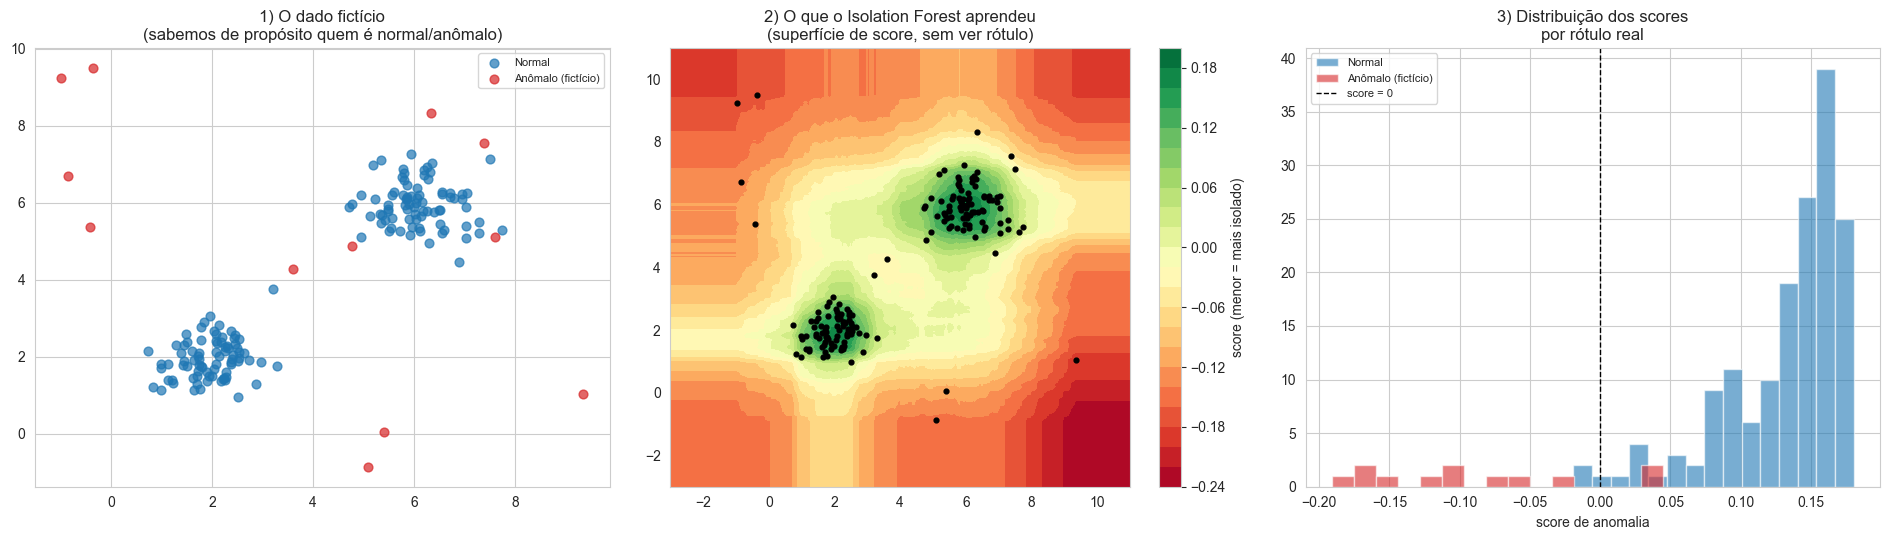

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

cores_ficticio = {'Normal': 'tab:blue', 'Anômalo (fictício)': 'tab:red'}
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    axes[0].scatter(X_ficticio[m, 0], X_ficticio[m, 1], c=cor, label=rotulo, alpha=0.7, s=40)
axes[0].set_title('1) O dado fictício\n(sabemos de propósito quem é normal/anômalo)')
axes[0].legend(fontsize=8)

# superfície de score: o que o algoritmo "enxerga", sem ver rótulo nenhum
xx, yy = np.meshgrid(np.linspace(-3, 11, 300), np.linspace(-3, 11, 300))
Z = iso_ficticio.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
cs = axes[1].contourf(xx, yy, Z, levels=20, cmap='RdYlGn')
axes[1].scatter(X_ficticio[:, 0], X_ficticio[:, 1], c='black', s=12)
plt.colorbar(cs, ax=axes[1], label='score (menor = mais isolado)')
axes[1].set_title('2) O que o Isolation Forest aprendeu\n(superfície de score, sem ver rótulo)')

# distribuição dos scores por rótulo real
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    axes[2].hist(score_ficticio[m], bins=15, color=cor, alpha=0.6, label=rotulo)
axes[2].axvline(0, color='black', linestyle='--', linewidth=1, label='score = 0')
axes[2].set_title('3) Distribuição dos scores\npor rótulo real')
axes[2].set_xlabel('score de anomalia')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


A superfície de score (painel 2) fica **verde** (score alto, "normal") bem em cima dos dois grupos densos, e **vermelha** (score baixo, "anômalo") nas bordas e longe de tudo — exatamente onde estão os pontos fictícios que geramos como "anômalos". O algoritmo nunca viu o rótulo `Normal`/`Anômalo (fictício)`: ele chegou nisso só de contar quão rápido cada ponto fica isolado. O histograma (painel 3) mostra a mesma coisa de outro ângulo: os scores dos pontos normais ficam concentrados bem acima de zero; os anômalos, misturados mais pra baixo — a separação não é perfeita (alguns anômalos fictícios caíram por sorte perto dos grupos densos), o que já é um bom aviso pra quando aplicarmos em dado real: o Isolation Forest não é infalível, é uma sugestão de onde olhar com mais atenção.


### Por dentro de uma única árvore

A superfície de score acima é o resultado **já combinado** de 200 árvores. Pra enxergar o mecanismo de verdade — os cortes aleatórios que dão nome ao algoritmo — olhamos uma árvore sozinha: cada linha abaixo é um corte (variável aleatória, ponto de corte aleatório entre o mínimo e o máximo ali). Escolhemos dois pontos de propósito — um bem no meio de um grupo denso, outro o mais "anômalo" segundo o próprio modelo — e comparamos quantos cortes cada um precisou até ficar sozinho numa partição.


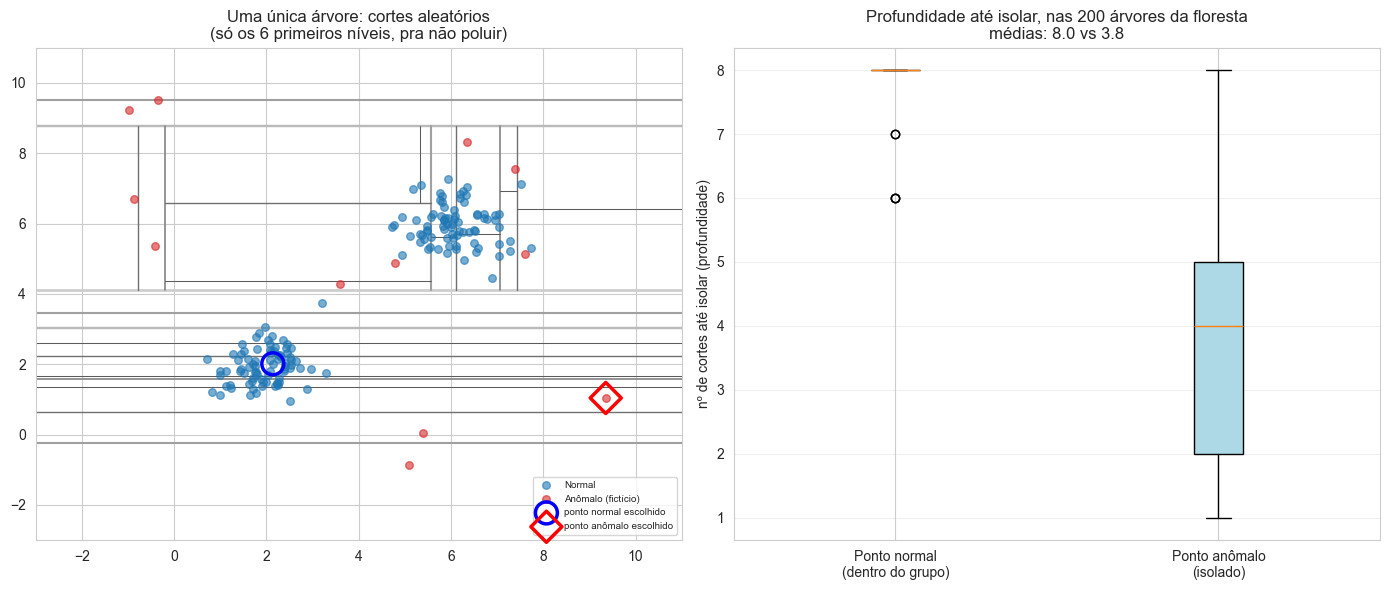

In [8]:
def desenhar_particoes(ax, tree_, no, x_min, x_max, y_min, y_max, profundidade=0, profundidade_max=6):
    """Desenha recursivamente os cortes de uma árvore de isolamento dentro de uma caixa
    [x_min,x_max] x [y_min,y_max]. Só os primeiros `profundidade_max` níveis são desenhados —
    a árvore de verdade continua até isolar cada ponto sozinho, mas isso poluiria demais o
    desenho sem ajudar a entender a ideia."""
    if profundidade >= profundidade_max or tree_.children_left[no] == -1:  # -1 = folha
        return
    variavel, limiar = tree_.feature[no], tree_.threshold[no]
    cor = plt.cm.Greys(0.3 + 0.5 * profundidade / profundidade_max)
    espessura = max(2 - 0.25 * profundidade, 0.4)
    if variavel == 0:
        ax.plot([limiar, limiar], [y_min, y_max], color=cor, linewidth=espessura)
        desenhar_particoes(ax, tree_, tree_.children_left[no], x_min, limiar, y_min, y_max, profundidade + 1, profundidade_max)
        desenhar_particoes(ax, tree_, tree_.children_right[no], limiar, x_max, y_min, y_max, profundidade + 1, profundidade_max)
    else:
        ax.plot([x_min, x_max], [limiar, limiar], color=cor, linewidth=espessura)
        desenhar_particoes(ax, tree_, tree_.children_left[no], x_min, x_max, y_min, limiar, profundidade + 1, profundidade_max)
        desenhar_particoes(ax, tree_, tree_.children_right[no], x_min, x_max, limiar, y_max, profundidade + 1, profundidade_max)


def profundidade_isolamento(tree_, ponto):
    """Quantos cortes uma árvore precisa até isolar `ponto` sozinho numa folha."""
    no, profundidade = 0, 0
    while tree_.children_left[no] != -1:
        variavel, limiar = tree_.feature[no], tree_.threshold[no]
        no = tree_.children_left[no] if ponto[variavel] <= limiar else tree_.children_right[no]
        profundidade += 1
    return profundidade


# dois pontos escolhidos de propósito: o mais "normal" (mais perto do centro do 1º grupo) e o
# mais "anômalo" de verdade segundo o próprio modelo (menor score entre os pontos fictícios)
ponto_normal = X_normal_ficticio[np.argmin(np.linalg.norm(X_normal_ficticio - [2, 2], axis=1))]
scores_dos_anomalos = iso_ficticio.decision_function(X_anomalo_ficticio)
ponto_anomalo = X_anomalo_ficticio[np.argmin(scores_dos_anomalos)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# painel A: uma única árvore da floresta, cortes desenhados
ax = axes[0]
x_min, x_max, y_min, y_max = -3, 11, -3, 11
uma_arvore = iso_ficticio.estimators_[0].tree_
desenhar_particoes(ax, uma_arvore, 0, x_min, x_max, y_min, y_max)
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    ax.scatter(X_ficticio[m, 0], X_ficticio[m, 1], c=cor, alpha=0.6, s=30, label=rotulo, zorder=3)
ax.scatter(*ponto_normal, s=250, facecolor='none', edgecolor='blue', linewidth=2.5, zorder=4, label='ponto normal escolhido')
ax.scatter(*ponto_anomalo, s=250, facecolor='none', edgecolor='red', linewidth=2.5, marker='D', zorder=4, label='ponto anômalo escolhido')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title('Uma única árvore: cortes aleatórios\n(só os 6 primeiros níveis, pra não poluir)')
ax.legend(fontsize=7, loc='lower right')

# painel B: profundidade até isolar cada um dos 2 pontos, em TODAS as árvores da floresta
profundidades_normal = [profundidade_isolamento(arv.tree_, ponto_normal) for arv in iso_ficticio.estimators_]
profundidades_anomalo = [profundidade_isolamento(arv.tree_, ponto_anomalo) for arv in iso_ficticio.estimators_]

ax2 = axes[1]
ax2.boxplot([profundidades_normal, profundidades_anomalo],
            tick_labels=['Ponto normal\n(dentro do grupo)', 'Ponto anômalo\n(isolado)'],
            patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax2.set_ylabel('nº de cortes até isolar (profundidade)')
ax2.set_title(f'Profundidade até isolar, nas {len(iso_ficticio.estimators_)} árvores da floresta\n'
              f'médias: {np.mean(profundidades_normal):.1f} vs {np.mean(profundidades_anomalo):.1f}')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


No painel A, repare que os cortes se acumulam (linhas mais escuras e grossas, dos primeiros níveis) tentando separar os dois grupos densos um do outro — é preciso *bastante* corte aleatório até isolar alguém que está cercado de vizinhos parecidos. Já nas regiões vazias, um corte já sobra bastante espaço sozinho.

O painel B mostra a consequência disso, com números de verdade: o ponto normal escolhido precisa, em média, de **quase o dobro** de cortes pra ficar isolado, comparado ao ponto anômalo. Repare também que a profundidade **varia bastante de árvore pra árvore** (a caixa do anômalo vai de 1 a 8 cortes) — cada árvore sorteou cortes diferentes, então uma única árvore pode "errar" por sorte. É exatamente por isso que o algoritmo tira a **média de centenas de árvores**, em vez de confiar numa só: no agregado, o padrão (caminho curto = anômalo) se sustenta, mesmo que árvore isolada nenhuma seja confiável sozinha.


---
## Detecção global: quem foge do padrão geral da base?

Reaproveitamos exatamente as mesmas 4 variáveis-driver já padronizadas na Fase 2 (`X`: `IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log`, `Total_Gasto_Campanha_Log`) — mesma pergunta de negócio, agora olhando pra quem está nas bordas em vez de procurar grupos.

Antes de fixar `contamination`, vale ver como o número de candidatos sinalizados muda conforme a suposição — e se os candidatos sinalizados com um valor menor continuam sinalizados com um valor maior (se o ranking for estável, o `contamination` só muda o ponto de corte, não quem é considerado atípico):

In [9]:
atipicos_por_contamination = {}
for cont in [0.02, 0.03, 0.05, 0.08, 'auto']:
    iso_teste = IsolationForest(contamination=cont, random_state=SEMENTE, n_estimators=200)
    pred_teste = iso_teste.fit_predict(X)
    atipicos_por_contamination[cont] = set(np.where(pred_teste == -1)[0])
    n_atipicos = len(atipicos_por_contamination[cont])
    print(f"contamination={cont!s:>6}: {n_atipicos:3d} atípicos de {len(X)} ({n_atipicos / len(X):.1%})")

print()
for menor, maior in [(0.02, 0.05), (0.03, 0.05), (0.05, 0.08)]:
    contidos = len(atipicos_por_contamination[menor] & atipicos_por_contamination[maior])
    print(f"dos {len(atipicos_por_contamination[menor])} atípicos com {menor}, "
          f"{contidos} continuam atípicos com {maior}")

contamination=  0.02:  22 atípicos de 1117 (2.0%)
contamination=  0.03:  34 atípicos de 1117 (3.0%)
contamination=  0.05:  56 atípicos de 1117 (5.0%)
contamination=  0.08:  90 atípicos de 1117 (8.1%)
contamination=  auto: 430 atípicos de 1117 (38.5%)

dos 22 atípicos com 0.02, 22 continuam atípicos com 0.05
dos 34 atípicos com 0.03, 34 continuam atípicos com 0.05
dos 56 atípicos com 0.05, 56 continuam atípicos com 0.08


O modo `'auto'` do scikit-learn usa uma heurística própria (baseada no paper original do Isolation Forest) que, nesta base, marca **430 candidatos (38,5%)** como atípicos — claramente alto demais pra ser útil. Fixamos `contamination=0.05` (5%, **56 candidatos**): um grupo pequeno o bastante pra examinar um por um.

A escolha é **estável**: os 22 atípicos com 2% e os 34 com 3% estão todos entre os 56 com 5%, e os 56 estão todos entre os 90 com 8%. O ranking de "quem é mais atípico" não muda com o parâmetro — o `contamination` só define até onde da lista a gente olha.

Não há filtro prévio de outliers: a regra do IQR usada em versões anteriores não removia nenhum candidato, porque patrimônio e gasto já entram em log.

In [10]:
contamination_global = 0.05  # ajuste conforme a célula anterior, se quiser um recorte maior/menor

iso_global = IsolationForest(contamination=contamination_global, random_state=SEMENTE, n_estimators=200)
pred_global = iso_global.fit_predict(X)
score_global = iso_global.decision_function(X)

df_cluster['anomalia_global'] = np.where(pred_global == -1, 'Atípico', 'Típico')
df_cluster['score_global'] = score_global

n_atipicos_global = (df_cluster['anomalia_global'] == 'Atípico').sum()
print(f"{n_atipicos_global} candidatos atípicos na base inteira (contamination={contamination_global})")

colunas_ficha_anomalia = ['NM_URNA_CANDIDATO', 'SG_PARTIDO', 'IDADE', 'ANOS_ESTUDO', 'Total_Bens',
                          'Total_Gasto_Campanha', 'cluster']

56 candidatos atípicos na base inteira (contamination=0.05)


### Lista de atípicos (visão global)


In [11]:
atipicos_globais = df_cluster[df_cluster['anomalia_global'] == 'Atípico'] \
    .sort_values('score_global')[colunas_ficha_anomalia + ['score_global']]

atipicos_globais


,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Gasto_Campanha,cluster,score_global
873,JULIO CARVALHO,AGIR,71,4,150000.00,0.00,Baixa escolaridade e sem campanha,-0.087226
875,GENTIL ALVES,AGIR,61,4,40000.00,0.00,Baixa escolaridade e sem campanha,-0.074529
1080,LINDAMERI RODRIGUES,PRD,29,4,0.00,0.00,Baixa escolaridade e sem campanha,-0.069058
871,MARTINHO (BIXO DE PÉ),AGIR,65,4,0.00,0.00,Baixa escolaridade e sem campanha,-0.066142
652,IVONEIDE DUARTE,PDT,85,8,57000.00,2179.55,Baixa escolaridade e sem campanha,-0.058162
534,MARCON,PT,62,4,126648.78,1281151.49,Em campanha sem patrimônio declarado,-0.057549
854,ARLINDO MENÇA BAIA,SOLIDARIEDADE,65,4,30000.00,7899.50,Baixa escolaridade e sem campanha,-0.056623
813,PATRICIA PEGORARO,DEMOCRATA,47,4,43000.00,0.00,Baixa escolaridade e sem campanha,-0.054926
867,PASTORA MARISA,AGIR,48,4,180000.00,0.00,Baixa escolaridade e sem campanha,-0.051949
721,ALTAIR ALVES,PSDB,75,8,0.00,14940.00,Em campanha sem patrimônio declarado,-0.048517


### Por que esses candidatos são atípicos?

- **Baixa escolaridade é a principal fonte de anomalia.** 39 dos 56 atípicos têm só o ensino fundamental (29 com fundamental incompleto), uma faixa que representa apenas 5,5% da base. Numa base em que 61% têm superior completo, essa é a região mais vazia do espaço. Por isso 26 dos 56 atípicos estão na *Base popular sem campanha*.
- **Combinações raras de patrimônio e gasto.** Marcon (PT, fundamental incompleto, R$ 1,28 mi de gasto), Jocelito Canto (nenhum bem declarado e R$ 1,86 mi de gasto) e Neguinho Grassi (R$ 33 mi em bens, com fundamental completo) não são extremos numa variável só, mas na combinação.
- **Idades extremas:** Ivoneide Duarte (85 anos) e Maria de Lourdes (81), e, no outro extremo, candidatos de 22 a 24 anos (Pai Franz, Eduardo Menegol, Arthur Cesconetto).
- **Grandes fortunas:** Newton Bonin (R$ 75,7 mi), Dilceu Sperafico (R$ 58,4 mi) e Neuza Viganó (R$ 10,9 mi).

**Limite do método:** como patrimônio e gasto entram em log, valores muito altos ficam próximos entre si. Adilson Seidi (R$ 67,5 mi, 2º maior patrimônio) e Heraldo Trento (R$ 50,7 mi) **não** são atípicos, e nenhum dos 6 maiores gastos de campanha (de R$ 2,6 mi a R$ 3,04 mi, com Onyx Lorenzoni no topo) aparece na lista. O Isolation Forest, aqui, aponta **combinações raras**, e não os maiores valores absolutos.

### Onde esses candidatos aparecem, visualmente


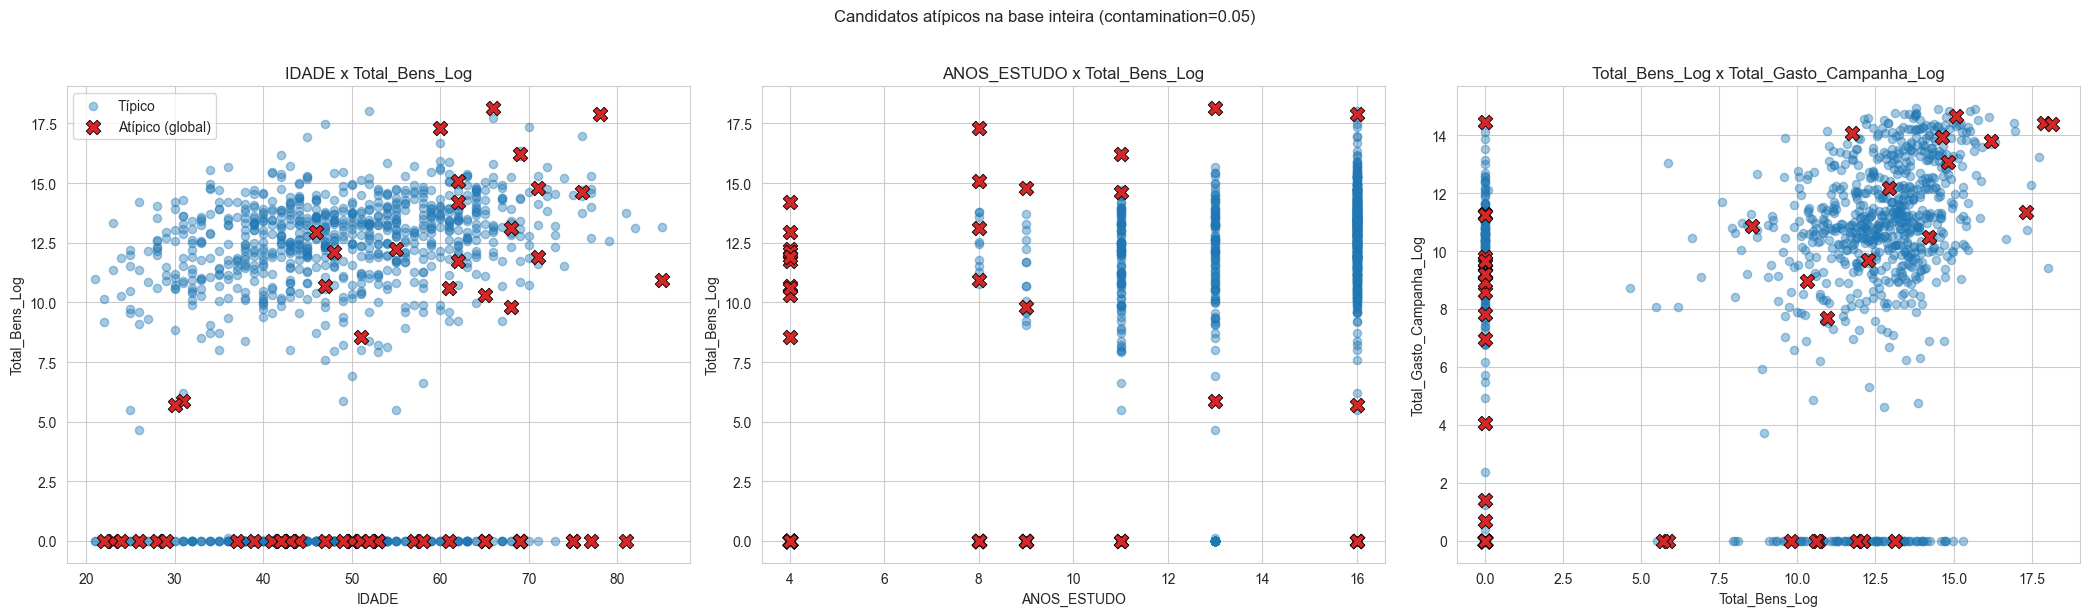

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

pares = [('IDADE', 'Total_Bens_Log'), ('ANOS_ESTUDO', 'Total_Bens_Log'), ('Total_Bens_Log', 'Total_Gasto_Campanha_Log')]
for ax, (x_col, y_col) in zip(axes, pares):
    tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
    atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']
    ax.scatter(tipicos[x_col], tipicos[y_col], c='tab:blue', alpha=0.4, s=35, label='Típico')
    ax.scatter(atipicos[x_col], atipicos[y_col], c='tab:red', marker='X', s=110,
               edgecolor='black', linewidth=0.6, label='Atípico (global)')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} x {y_col}')

axes[0].legend()
plt.suptitle(f'Candidatos atípicos na base inteira (contamination={contamination_global})', y=1.02)
plt.tight_layout()
plt.show()

### O mesmo recorte, em 3D

Duas variáveis de cada vez (painéis acima) escondem alguma coisa: dois candidatos podem parecer próximos num plano e estar bem longe um do outro numa terceira variável. O modelo usa **4 variáveis ao mesmo tempo**; o gráfico 3D interativo mostra as três que mais separam os candidatos — anos de estudo, patrimônio (log) e gasto de campanha (log) — e a idade aparece ao passar o mouse sobre cada ponto. Arrastem pra rotacionar.

In [13]:
cores_iso = {'Típico': '#1f77b4', 'Atípico': '#d62728'}

fig3d = go.Figure()
for status, cor in cores_iso.items():
    sub = df_cluster[df_cluster['anomalia_global'] == status]
    fig3d.add_trace(go.Scatter3d(
        x=sub['ANOS_ESTUDO'], y=sub['Total_Bens_Log'], z=sub['Total_Gasto_Campanha_Log'],
        mode='markers', name=status,
        marker=dict(
            size=6 if status == 'Típico' else 9,
            color=cor,
            symbol='circle' if status == 'Típico' else 'diamond',
            opacity=0.5 if status == 'Típico' else 0.95,
            line=dict(width=1, color='black'),
        ),
        text=sub['NM_URNA_CANDIDATO'] + ' — ' + sub['cluster'],
        customdata=sub['IDADE'],
        hovertemplate='<b>%{text}</b><br>IDADE=%{customdata}<br>ANOS_ESTUDO=%{x}<br>Total_Bens_Log=%{y:.2f}'
                      '<br>Total_Gasto_Campanha_Log=%{z:.2f}<extra></extra>',
    ))

fig3d.update_layout(
    scene=dict(xaxis_title='ANOS_ESTUDO', yaxis_title='Total_Bens_Log', zaxis_title='Total_Gasto_Campanha_Log'),
    title=f'Candidatos atípicos (visão global) — contamination={contamination_global}',
    height=650, margin=dict(l=0, r=0, b=0, t=40),
)
fig3d.show()

---
## Detecção dentro de cada cluster: quem foge do padrão do próprio grupo?

Aqui está o detalhe metodológico que faz essa pergunta ser **diferente** da anterior, não uma repetição: se reaproveitássemos a mesma escala global (`X`, padronizado na base inteira) pra rodar o Isolation Forest separadamente por cluster, a pergunta continuaria sendo "quem é extremo na base inteira". Pra perguntar "isso é estranho **para alguém deste grupo**?", precisamos **padronizar de novo, usando só a média e o desvio-padrão daquele cluster** (`StandardScaler` ajustado cluster a cluster).

Sobre `contamination` por cluster: os quatro clusters têm tamanhos bem diferentes (712 / 222 / 94 / 89 candidatos). Usamos `max(5%, 2 candidatos)` — um piso de pelo menos 2 candidatos sinalizados mesmo num cluster pequeno, sem passar de 50% do grupo. Com esses tamanhos, o piso não chega a ser acionado: são 5% em todos. Nos dois clusters menores isso significa só 4 ou 5 candidatos por grupo — pouca gente, o mesmo cuidado com amostra pequena que já apareceu nas Fases 2 e 3.

In [14]:
resultados_cluster = []

for nome in NOMES_CLUSTER_BISECTING.values():
    sub_idx = df_cluster.index[df_cluster['cluster'] == nome].to_numpy()
    n = len(sub_idx)

    X_cluster = df_cluster.loc[sub_idx, colunas_driver].values
    X_cluster_padronizado = StandardScaler().fit_transform(X_cluster)

    contaminacao_cluster = min(max(0.05, 2 / n), 0.5)
    iso_cluster = IsolationForest(contamination=contaminacao_cluster, random_state=SEMENTE, n_estimators=200)
    pred_cluster = iso_cluster.fit_predict(X_cluster_padronizado)
    score_cluster = iso_cluster.decision_function(X_cluster_padronizado)

    n_atipicos = int((pred_cluster == -1).sum())
    print(f"{nome} (n={n}, contamination={contaminacao_cluster:.3f}): {n_atipicos} atípicos dentro do grupo")

    resultados_cluster.append(pd.DataFrame({
        'indice_original': sub_idx,
        'anomalia_cluster': np.where(pred_cluster == -1, 'Atípico', 'Típico'),
        'score_cluster': score_cluster,
    }))

anomalia_cluster_df = pd.concat(resultados_cluster).set_index('indice_original').sort_index()
df_cluster['anomalia_cluster'] = anomalia_cluster_df['anomalia_cluster'].values
df_cluster['score_cluster'] = anomalia_cluster_df['score_cluster'].values

Estabelecidos com patrimônio e campanha (n=712, contamination=0.050): 36 atípicos dentro do grupo
Em campanha sem patrimônio declarado (n=222, contamination=0.050): 12 atípicos dentro do grupo
Jovens sem patrimônio e sem campanha (n=94, contamination=0.050): 5 atípicos dentro do grupo
Baixa escolaridade e sem campanha (n=89, contamination=0.050): 5 atípicos dentro do grupo


In [15]:
for nome in NOMES_CLUSTER_BISECTING.values():
    print(f"--- {nome}: mais atípicos dentro do grupo ---")
    sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == 'Atípico')]
    display(sub.sort_values('score_cluster')[colunas_ficha_anomalia + ['score_cluster']])

--- Estabelecidos com patrimônio e campanha: mais atípicos dentro do grupo ---


,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Gasto_Campanha,cluster,score_cluster
270,NEGUINHO GRASSI,PL,60,8,33086771.00,85998.74,Estabelecidos com patrimônio e campanha,-0.102733
265,SARGENTO FAHUR,PL,62,8,3546637.32,2284571.24,Estabelecidos com patrimônio e campanha,-0.099874
276,AMIN HANNOUCHE,PL,63,16,0.00,1059557.77,Estabelecidos com patrimônio e campanha,-0.071593
1073,RAIMUNDO COLOMBO,PSD,71,9,2707284.20,468406.50,Estabelecidos com patrimônio e campanha,-0.065903
845,ARI GAMBIN,SOLIDARIEDADE,73,13,549956.98,0.00,Estabelecidos com patrimônio e campanha,-0.062969
661,CLEO HICKMANN,PDT,67,9,43000.00,30281.55,Estabelecidos com patrimônio e campanha,-0.057314
68,TONINHO DA INSTALBOMBAS,PCDOB,61,8,3380000.00,26633.50,Estabelecidos com patrimônio e campanha,-0.054202
932,EGIDIO BECKHAUSER,REPUBLICANOS,49,13,348.51,456927.40,Estabelecidos com patrimônio e campanha,-0.052680
56,DILCEU SPERAFICO,PP,78,16,58445503.79,1793091.01,Estabelecidos com patrimônio e campanha,-0.046408
97,NEWTON BONIN,REPUBLICANOS,66,13,75659161.21,1788899.93,Estabelecidos com patrimônio e campanha,-0.046299


--- Em campanha sem patrimônio declarado: mais atípicos dentro do grupo ---


,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Gasto_Campanha,cluster,score_cluster
534,MARCON,PT,62,4,126648.78,1281151.49,Em campanha sem patrimônio declarado,-0.136033
20,SOLITÁRIO,PSB,46,4,412532.00,196838.50,Em campanha sem patrimônio declarado,-0.111524
778,EDUARDO MENEGOL,MISSÃO,23,16,0.00,57.96,Em campanha sem patrimônio declarado,-0.054967
766,ROGÉRIO GRADE - CHÉIO,MDB,51,4,5210.04,51494.38,Em campanha sem patrimônio declarado,-0.037707
458,BRUNO DO MLB,UP,31,16,485.00,3225.00,Em campanha sem patrimônio declarado,-0.033533
57,JOCELITO CANTO,PP,61,9,0.00,1864383.38,Em campanha sem patrimônio declarado,-0.023176
1011,AMANDA WENCESLAU,UP,24,13,28691.00,1000.00,Em campanha sem patrimônio declarado,-0.021670
890,ADILSON DA SAÚDE,PDT,55,8,128930.51,23436.00,Em campanha sem patrimônio declarado,-0.017074
758,PEDRINHO,MDB,22,13,9620.98,13500.00,Em campanha sem patrimônio declarado,-0.010883
1062,JORDAM BRITO,MISSÃO,25,11,198000.00,3986.57,Em campanha sem patrimônio declarado,-0.007470


--- Jovens sem patrimônio e sem campanha: mais atípicos dentro do grupo ---


,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Gasto_Campanha,cluster,score_cluster
299,MAYCON ROBERTO,REDE,30,11,7030.64,368.96,Jovens sem patrimônio e sem campanha,-0.157348
362,MANU SHTORACH,MISSÃO,26,8,0.00,3.16,Jovens sem patrimônio e sem campanha,-0.110392
344,MARI GUEDES PCD,MISSÃO,28,16,0.00,1.00,Jovens sem patrimônio e sem campanha,-0.026612
303,INEZ,PSOL,67,16,10000.00,0.00,Jovens sem patrimônio e sem campanha,-0.016338
853,LUCIANO ROSA,SOLIDARIEDADE,55,16,0.00,0.50,Jovens sem patrimônio e sem campanha,-0.010709


--- Baixa escolaridade e sem campanha: mais atípicos dentro do grupo ---


,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Gasto_Campanha,cluster,score_cluster
398,JOÃO BATISTA,SOLIDARIEDADE,62,4,1510000.00,35450.00,Baixa escolaridade e sem campanha,-0.051533
652,IVONEIDE DUARTE,PDT,85,8,57000.00,2179.55,Baixa escolaridade e sem campanha,-0.044519
678,UH FABIANO,PSD,51,9,0.00,304.00,Baixa escolaridade e sem campanha,-0.019243
627,FABIO NUNES,REPUBLICANOS,40,8,980104.25,2700.00,Baixa escolaridade e sem campanha,-0.016181
854,ARLINDO MENÇA BAIA,SOLIDARIEDADE,65,4,30000.00,7899.50,Baixa escolaridade e sem campanha,-0.003545


### O que é atípico dentro de cada grupo

A régua muda de cluster para cluster — e, com ela, quem se destaca:

- **Estabelecidos com patrimônio e campanha** (36 atípicos; mediana do grupo: 49 anos, 16 anos de estudo, R$ 506 mil em bens, R$ 66 mil de gasto):
  - **baixa escolaridade com patrimônio alto**: Neguinho Grassi (empresário, R$ 33 mi), Sargento Fahur (deputado, R$ 3,5 mi), Toninho da Instalbombas (mecânico, R$ 3,4 mi);
  - **gasto alto quase sem bens**: Amin Hannouche (nenhum bem, R$ 1,06 mi de gasto), Egidio Beckhauser (R$ 349 em bens, R$ 457 mil de gasto), Bia Borba (21 anos, R$ 486 mil de gasto);
  - **bens sem nenhum gasto**: Ari Gambin, Dr. Guilherme Machado e Dra. Lisiane Anzanello.
- **Em campanha sem patrimônio declarado** (12): quem **declarou bens** num grupo em que 87% não declaram (Solitário, R$ 413 mil; Marcon, R$ 127 mil) e quem gasta muito acima da mediana de R$ 24 mil (Jocelito Canto, R$ 1,86 mi; Marcon, R$ 1,28 mi).
- **Nível superior sem campanha** (5): candidatos com gasto **irrisório, mas diferente de zero** (R$ 0,50 a R$ 369). Em log, R$ 1 já se distingue de zero, e num grupo em que quase todos têm gasto zero isso chama atenção. Parecem mais lançamentos de teste ou de ajuste na prestação de contas do que gasto real: vale como alerta de **qualidade de dados**. Também aparecem Manu Shtorach (só fundamental, num grupo de nível superior) e Inez (67 anos).
- **Base popular sem campanha** (5): quem **tem patrimônio** num grupo de mediana R$ 16 mil (João Batista, eletricista, R$ 1,51 mi; Fabio Nunes, R$ 980 mil) e a candidata mais velha da base (Ivoneide Duarte, 85 anos).

### O mesmo recorte, em 3D — filtrando por cluster

Mesma ideia do gráfico 3D global, agora um por cluster: escolham no menu qual grupo olhar (cada cluster usa a sua **própria** padronização, então os pontos vermelhos aqui são atípicos *dentro daquele grupo*, não em relação à base inteira). Os eixos ficam fixos entre um cluster e outro, pra dar pra comparar a posição relativa.


In [16]:
nomes_bisecting_ordenados = list(NOMES_CLUSTER_BISECTING.values())
n_status = len(cores_iso)  # 'Típico' e 'Atípico', mesmas cores do gráfico 3D global

fig3d_cluster = go.Figure()
for idx_cluster, nome in enumerate(nomes_bisecting_ordenados):
    for status, cor in cores_iso.items():
        sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == status)]
        fig3d_cluster.add_trace(go.Scatter3d(
            x=sub['ANOS_ESTUDO'], y=sub['Total_Bens_Log'], z=sub['Total_Gasto_Campanha_Log'],
            mode='markers', name=status,
            marker=dict(
                size=6 if status == 'Típico' else 9,
                color=cor,
                symbol='circle' if status == 'Típico' else 'diamond',
                opacity=0.55 if status == 'Típico' else 0.95,
                line=dict(width=1, color='black'),
            ),
            text=sub['NM_URNA_CANDIDATO'],
            customdata=sub['IDADE'],
            hovertemplate='<b>%{text}</b><br>IDADE=%{customdata}<br>ANOS_ESTUDO=%{x}<br>Total_Bens_Log=%{y:.2f}'
                          '<br>Total_Gasto_Campanha_Log=%{z:.2f}<extra></extra>',
            visible=(idx_cluster == 0),       # só o primeiro cluster começa visível
            legendgroup=status,
            showlegend=(idx_cluster == 0),    # legenda não se repete a cada cluster
        ))

# um botão por cluster no menu suspenso — cada um liga só os 2 traços (Típico/Atípico) daquele cluster
botoes_cluster = []
for idx_cluster, nome in enumerate(nomes_bisecting_ordenados):
    visibilidade = [False] * (len(nomes_bisecting_ordenados) * n_status)
    for j in range(n_status):
        visibilidade[idx_cluster * n_status + j] = True
    botoes_cluster.append(dict(
        label=nome, method='update',
        args=[{'visible': visibilidade}, {'title': f'Atípicos dentro do cluster: {nome}'}],
    ))

fig3d_cluster.update_layout(
    scene=dict(
        xaxis_title='ANOS_ESTUDO', yaxis_title='Total_Bens_Log', zaxis_title='Total_Gasto_Campanha_Log',
        xaxis=dict(range=[df_cluster['ANOS_ESTUDO'].min() - 1, df_cluster['ANOS_ESTUDO'].max() + 1]),
        yaxis=dict(range=[df_cluster['Total_Bens_Log'].min() - 0.5, df_cluster['Total_Bens_Log'].max() + 0.5]),
        zaxis=dict(range=[df_cluster['Total_Gasto_Campanha_Log'].min() - 0.5, df_cluster['Total_Gasto_Campanha_Log'].max() + 0.5]),
    ),
    updatemenus=[dict(active=0, buttons=botoes_cluster, x=0.02, y=1.05, xanchor='left')],
    title=f'Atípicos dentro do cluster: {nomes_bisecting_ordenados[0]}',
    height=650, margin=dict(l=0, r=0, b=0, t=60),
)
fig3d_cluster.show()

### Comparando: global vs. dentro do cluster

Quatro combinações possíveis pra cada candidato: atípico nos dois recortes (destoa de tudo, robusto), só globalmente, só dentro do cluster, ou típico nos dois. O caso mais interessante pedagogicamente é o **"só dentro do cluster"**: candidatos que passam despercebidos quando olhamos a base inteira, mas que não se parecem com seus próprios colegas de grupo.


In [17]:
tabela_comparacao = pd.crosstab(df_cluster['anomalia_global'], df_cluster['anomalia_cluster'])
tabela_comparacao.index.name = 'anomalia_global \\ anomalia_cluster'
display(tabela_comparacao)

so_no_cluster = df_cluster[(df_cluster['anomalia_global'] == 'Típico') & (df_cluster['anomalia_cluster'] == 'Atípico')]
print(f"\n{len(so_no_cluster)} candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):")
so_no_cluster[colunas_ficha_anomalia + ['score_cluster']].sort_values('score_cluster')


anomalia_cluster,Atípico,Típico
anomalia_global \ anomalia_cluster,,
Atípico,17,39
Típico,41,1020



41 candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):


,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Gasto_Campanha,cluster,score_cluster
299,MAYCON ROBERTO,REDE,30,11,7030.64,368.96,Jovens sem patrimônio e sem campanha,-0.157348
276,AMIN HANNOUCHE,PL,63,16,0.00,1059557.77,Estabelecidos com patrimônio e campanha,-0.071593
845,ARI GAMBIN,SOLIDARIEDADE,73,13,549956.98,0.00,Estabelecidos com patrimônio e campanha,-0.062969
661,CLEO HICKMANN,PDT,67,9,43000.00,30281.55,Estabelecidos com patrimônio e campanha,-0.057314
68,TONINHO DA INSTALBOMBAS,PCDOB,61,8,3380000.00,26633.50,Estabelecidos com patrimônio e campanha,-0.054202
932,EGIDIO BECKHAUSER,REPUBLICANOS,49,13,348.51,456927.40,Estabelecidos com patrimônio e campanha,-0.052680
285,TONINHO FENELON DA FARMÁCIA,PL,64,8,954067.00,17325.73,Estabelecidos com patrimônio e campanha,-0.045843
1101,MAURI DAS LAJOTAS,AVANTE,59,8,800000.00,13014.00,Estabelecidos com patrimônio e campanha,-0.036150
980,FERNANDO CORDEIRO,PL,35,11,6000.00,310616.82,Estabelecidos com patrimônio e campanha,-0.033748
458,BRUNO DO MLB,UP,31,16,485.00,3225.00,Em campanha sem patrimônio declarado,-0.033533


---
## Conclusões

Resultado oficial usado em todo o projeto: **Bisecting K-Means com as 4 variáveis** (idade, anos de estudo, patrimônio em log e gasto de campanha em log), **k = 4** (`02_clusterizacao_com_despesa.ipynb`, Parte 3).

| Cluster | n | Idade média | Anos de estudo | Sem bens | Sem gasto | Nome |
|---|---|---|---|---|---|---|
| A | 712 (64%) | 50,0 | 15,1 | 0,1% | 6,3% | **Estabelecidos com patrimônio e campanha** |
| B | 222 (20%) | 44,6 | 12,8 | 86,9% | 0% | **Em campanha sem patrimônio declarado** |
| C | 94 (8%) | 42,5 | 13,7 | 76,6% | 94,7% | **Nível superior sem campanha** |
| D | 89 (8%) | 53,7 | 8,6 | 43,8% | 88,8% | **Base popular sem campanha** |

### 1. Quais perfis encontramos e o que mais os diferenciou

- **O primeiro corte separa quem tem patrimônio *e* campanha do resto** (712 × 405). O segundo separa, entre os demais, quem já tem gasto de campanha (222) de quem ainda não tem (183). O terceiro divide os sem gasto por escolaridade e idade (94 × 89). Idade é a variável que menos diferencia os grupos (médias de 42 a 54 anos).
- **Estabelecidos com patrimônio e campanha (64%)**: 78% com superior completo, 85% brancos, 67% homens, 57% casados. Empresários, advogados, vereadores e deputados, ou seja, os políticos de carreira.
- **Em campanha sem patrimônio declarado (20%)**: todos já gastam, mas 87% não declararam bens. É o grupo **mais feminino** (49%) e **menos branco** (35% pretos ou pardos), com PSOL como partido mais frequente.
- **Nível superior sem campanha (8%)**: sem gasto e quase sempre sem bens, com 72% de nível superior (completo ou incompleto). É o grupo mais jovem e o de mais solteiros.
- **Base popular sem campanha (8%)**: a menor escolaridade (ninguém com superior completo), o grupo mais velho e 56% do RS. Comerciantes, donas de casa e aposentados, em partidos pequenos (DC, Democrata, Agir).

### 2. O que as regras de associação confirmaram

- As faixas por quartil das 4 variáveis reconstroem os clusters com lift alto (até 8,3), o que confirma a **consistência** da clusterização.
- Sem as variáveis do modelo, a associação mais forte é **cor/raça preta → Em campanha sem patrimônio** (lift 2,0; com solteiro(a), 2,3) e **PSOL → Em campanha sem patrimônio** (lift 2,1). Esse é um recorte racial e partidário que o modelo não recebeu como entrada.
- **Partidos grandes (PP, PT, PODE, PDT, NOVO) → Estabelecidos**, com confiança de 0,89 a 0,97, de todo o espectro ideológico. Patrimônio e campanha estruturada se associam mais ao tamanho do partido do que à ideologia.
- As regras **confirmaram os nomes de A, B e D** e levaram a ajustar o nome do C: a primeira versão ("Escolarizados") só valia na comparação com o D.

### 3. Anomalias que mais chamaram atenção

- **Contamination = 5%** (56 candidatos). O modo `'auto'` marcaria 38,5% da base, e a lista é **estável**: os atípicos com 2% e 3% estão todos contidos na de 5%.
- **Na base inteira, o Isolation Forest encontrou principalmente baixa escolaridade:** 39 dos 56 atípicos têm só o ensino fundamental (5,5% da base). Somam-se a eles combinações raras (sem bens e R$ 1,86 mi de gasto; R$ 33 mi em bens com fundamental completo), idades extremas (22 a 24 e 81 a 85 anos) e as maiores fortunas.
- **Limite do método:** em log, valores muito altos ficam próximos. O 2º maior patrimônio (R$ 67,5 mi) e os 6 maiores gastos de campanha **não** são atípicos.
- **Dentro de cada cluster, o que é anômalo muda:** nos *Estabelecidos*, baixa escolaridade com patrimônio alto e gasto alto sem bens; em *Em campanha sem patrimônio*, quem declarou bens ou gasta mais de R$ 1 mi; em *Nível superior sem campanha*, gastos irrisórios de R$ 0,50 a R$ 369 (provável problema de qualidade de dados); na *Base popular*, quem tem patrimônio.
- **41 candidatos são atípicos apenas dentro do próprio cluster.** É o argumento a favor da análise local: na visão global, eles passariam despercebidos.

### 4. O que era esperado e o que foi novo

- **Confirmou o esperado:** os candidatos são majoritariamente homens, brancos, com nível superior e com patrimônio, e o grupo com patrimônio concentra empresários e políticos com mandato.
- **Foi inesperado:**
  - **27% dos candidatos declararam patrimônio zero** e **19% não tinham nenhuma despesa contratada** até 19/09/2026;
  - o gasto de campanha tem correlação apenas moderada com o patrimônio (r = 0,37 nos logs) e é o que separa os grupos sem bens: há 222 candidatos **em campanha ativa sem patrimônio declarado**;
  - o recorte racial aparece com força justamente nesse grupo, mesmo sem cor/raça ter entrado na clusterização;
  - parte das anomalias locais é, na verdade, **ruído de prestação de contas** (lançamentos de R$ 0,50 a R$ 369).

### 5. Principal contribuição

Mostramos que, entre os candidatos a Deputado Federal no Sul, a desigualdade mais visível não é de idade, e sim de **patrimônio declarado combinado com estrutura de campanha e escolaridade**, e que ela vem acompanhada de recortes de gênero, raça e partido que o modelo não recebeu como entrada. Além disso, os casos que merecem investigação dependem da régua usada: um candidato comum na base inteira pode ser atípico dentro do próprio grupo.

**Limitações:**
- o gasto de campanha é **parcial**: são as despesas contratadas até o extrato de 19/09/2026, com a campanha em andamento, então "sem gasto" significa "sem despesa registrada até essa data";
- "sem patrimônio" pode significar declaração incompleta, e não ausência real de bens;
- o log comprime os valores altos, e por isso as maiores fortunas e os maiores gastos nem sempre aparecem como anomalias;
- a eleição ainda não ocorreu, então não foi possível cruzar os perfis com o resultado (`DS_SIT_TOT_TURNO`).